# Pricing 0DTE put options and computing implied volatilities using neural networks



In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import csv

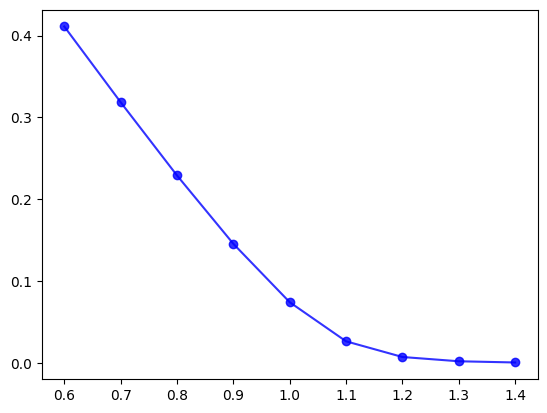

In [3]:
# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2

    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    #print("charfun_heston wn:", charfun_heston(params, 2 * np.pi * wn, t))
    #print("charfun_heston wn-1:", charfun_heston(params, 2 * np.pi * wn - 1j, t))
    #print("Size: ", np.size(charfun_heston(params, 2 * np.pi * wn - 1j, t)))

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

CP = 1  # for Call options
S = 1
t = 1.00
K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
IR = 0.05  # Interest rate
DY = 0.02  # Dividend yield
params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
# Select Xc based on time to maturity
if t == 1.00:
    Xc = 12.1802  # Increased truncation range
Xm = 0
    
#pow = 20  # Increased FFT precision
pow = 21  # Increase precision

heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)

plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", linestyle='-', marker='o', color='blue', alpha=0.8)

In [4]:
# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2

    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

In [5]:
# COS method
def COS_method(S, t, K, IR, DY, model, params, Xc, Xm, N, CP, type_):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    K1 = np.exp(-(IR - DY) * t) * K
    x = np.log(S / K1)

    a = -Xc + Xm
    b = Xc + Xm

    k = np.arange(0, N)
    c = a
    d = 0
    u = k * np.pi / (b - a)

    phi = charfun_heston(params, u, t)
    phi[0] = 1  # Ensure phi[0] = 1 to avoid division errors
    
    eto = np.exp(1j * np.pi * k[:, None] * (x - a) / (b - a))

    wgt = np.ones(N)
    wgt[0] = 0.5

    # Fix for psit
    psit = np.zeros_like(k, dtype=np.float64)
    psit[1:] = (np.sin(k[1:] * np.pi * (d - a) / (b - a)) - np.sin(k[1:] * np.pi * (c - a) / (b - a))) * ((b - a) / (k[1:] * np.pi))
    psit[0] = d - c  # Handle the case for k = 0 explicitly
    psi = psit

    Vk1 = 2 / (b - a) * K[:, None] * psi
    conP = np.real(np.sum(wgt * phi * eto.T * Vk1, axis=1)) * np.exp(-IR * t)

    add1 = np.cos(k * np.pi * (d - a) / (b - a)) * np.exp(d) - np.cos(k * np.pi * (c - a) / (b - a)) * np.exp(c)
    add2 = (k * np.pi / (b - a)) * (np.sin(k * np.pi * (d - a) / (b - a)) * np.exp(d) - np.sin(k * np.pi * (c - a) / (b - a)) * np.exp(c))
    fatt = 1 / (1 + (k * np.pi / (b - a))**2)
    chi = fatt * (add1 + add2)

    Vk2 = 2 / (b - a) * K1[:, None] * chi
    aonP = np.real(np.sum(wgt * phi * eto.T * Vk2, axis=1)) * np.exp(-DY * t)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    if CP * type_ == 1:
        return call
    elif CP * type_ == -1:
        return put
    else:
        raise ValueError("Invalid combination of CP and type.")

In [6]:
# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    #print("charfun_heston wn:", charfun_heston(params, 2 * np.pi * wn, t))
    #print("charfun_heston wn-1:", charfun_heston(params, 2 * np.pi * wn - 1j, t))
    #print("Size: ", np.size(charfun_heston(params, 2 * np.pi * wn - 1j, t)))

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

In [7]:
# Black-Scholes formula
def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

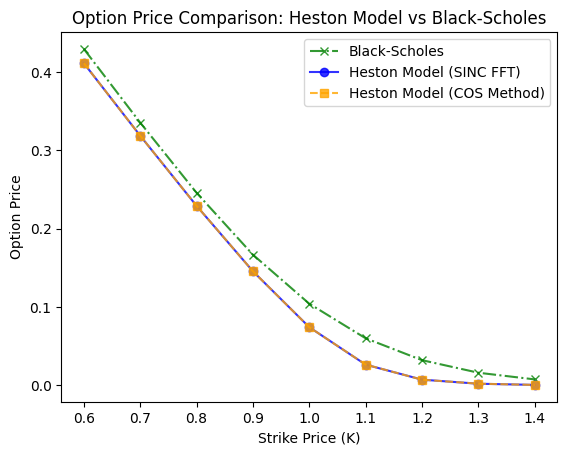

In [9]:
CP = 1  # for Call options
S = 1
t = 1.00
K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
IR = 0.05  # Interest rate
DY = 0.02  # Dividend yield
params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
# Select Xc based on time to maturity
if t == 1.00:
    Xc = 12.1802  # Increased truncation range
    #Xc = 1  # Increased truncation range
Xm = 0
    
#pow = 20  # Increased FFT precision
pow = 21  # Increase precision

heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)
# COS method prices
N = 256
cos_prices = COS_method(S, t, K, IR, DY, "heston", params, Xc, Xm, N, CP, 1)
    
# Black-Scholes prices
sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
# Plot results
#plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", linestyle='-',marker='o')
#plt.plot(K, cos_prices, label="Heston Model (COS Method)", linestyle='--',marker='o')
#plt.plot(K, bs_prices, label="Black-Scholes",  marker='x')
plt.plot(K, bs_prices, label="Black-Scholes", linestyle='-.', marker='x', color='green', alpha=0.8)
plt.plot(K, heston_prices, label="Heston Model (SINC FFT)", linestyle='-', marker='o', color='blue', alpha=0.8)
plt.plot(K, cos_prices, label="Heston Model (COS Method)", linestyle='--', marker='s', color='orange', alpha=0.8)

plt.xlabel("Strike Price (K)")
plt.ylabel("Option Price")
plt.title("Option Price Comparison: Heston Model vs Black-Scholes")
plt.legend()
plt.show()
    
# Print results for review
#print("Strike Prices:", K)
#print("Heston Model Prices:", heston_prices)
#print("Black-Scholes Prices:", bs_prices)



In [94]:
def bs_implied_vol_put(S, K, T, r, P):
    n = len(K)
    sigmaL = 1e-10 * np.ones(n)
    PL = bs_formula_put(S, K, T, r, sigmaL)
    sigmaH = 10 * np.ones(n)
    PH = bs_formula_put(S, K, T, r, sigmaH)
    while np.mean(sigmaH - sigmaL) > 1e-10:
        sigma = (sigmaL + sigmaH) / 2
        PM = bs_formula_put(S, K, T, r, sigma)
        PL = np.where(PM < P, PM, PL)
        sigmaL = np.where(PM < P, sigma, sigmaL)
        PH = np.where(PM >= P, PM, PH)
        sigmaH = np.where(PM >= P, sigma, sigmaH)
    return sigma

def bs_formula_put(S, K, T, r, sigma):
    x = np.log(S / K) + r * T
    sig = sigma * np.sqrt(T)
    d1 = x / sig + sig / 2
    d2 = d1 - sig
    pv = np.exp(-r * T)
    return pv * K * norm.cdf(-d2) - S * norm.cdf(-d1)


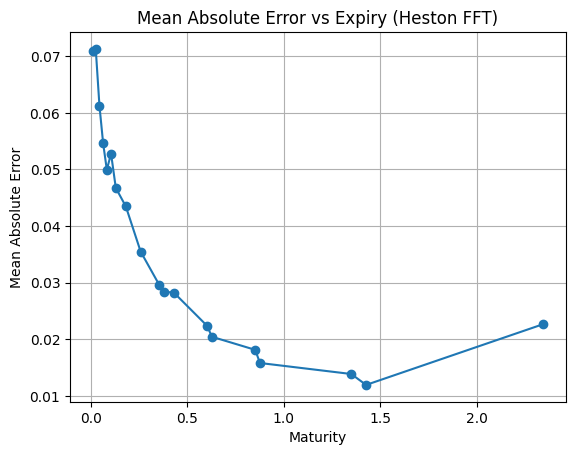

In [96]:
# Load market data
data = []
with open('spx_surf20130814.csv', 'r', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        data.append(row)

structured_data = {col.strip(): np.array([float(row[col]) for row in data]) for col in data[0].keys()}
expiries = np.unique(structured_data['t'])
params = [1.5768, 0.0398, 0.5751, 0.0157, -0.5711]  # Example Heston params
errors = []

for expiry in expiries:
    subset_indices = structured_data['t'] == expiry
    fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]
    impVol_bench = structured_data['impVol'][subset_indices]
    prices = sinc_fast_ft(S=fwd, t=t, K=K, IR=0, DY=0, params=params, Xc=4, Xm=0, pow=14, CP=-1)
    impVol_model = bs_implied_vol_put(fwd, K, t, 0, prices)
    error = np.mean(np.abs(impVol_model - impVol_bench))
    errors.append(error)

plt.plot(expiries, errors, marker='o')
plt.xlabel('Maturity')
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error vs Expiry (Heston FFT)')
plt.grid(True)
plt.show()
#print(prices)

In [75]:
def call_cosine_coef(a, b, c, d, K, N):
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*K*(chi_k-psi_k)

def call_cosine_coef_moy(a, b, c, d, N):
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*(chi_k-psi_k)

def phi_Heston(a ,b ,N ,r, tau, kappa, gamma, vbar, v0, rho):
  k = np.arange(N).reshape(1,-1)
  u = np.pi*k/(b-a)
  i = complex(0.0,1.0)
  D = np.sqrt((kappa-gamma*rho*i*u)**2+(u**2+i*u)*gamma**2)
  G = (kappa-gamma*rho*i*u-D)/(kappa-gamma*rho*i*u+D)
  C = v0* (1-np.exp(-D*tau)) / (gamma**2*(1-G*np.exp(-D*tau)))*(kappa-gamma*rho*i*u-D)
  A = r*i*u*tau + kappa*vbar/(gamma**2)*(tau*(kappa-gamma*rho*i*u-D) -2*np.log( (1-G*np.exp(-D*tau))/(1-G) )   ) 
  phi = np.exp( A + C )
  return phi

def Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho ):
  c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau
  
  c2 = 0.125 / kappa ** 3 * (gamma * tau * np.exp(- kappa * tau) * (v0 - vbar) * (8 * kappa * rho - 4 * gamma) + \
     kappa * rho * gamma * (1 - np.exp(- kappa * tau)) * (16 * vbar - 8 * v0) + \
     2 * vbar * kappa * tau * (- 4 * kappa * rho * gamma + gamma ** 2 + 4 * kappa ** 2) + \
     gamma ** 2 * ((vbar - 2 * v0) * np.exp(-2 * kappa * tau) + vbar * (6 * np.exp(- kappa * tau) - 7) + 2 * v0) + \
     8 * kappa ** 2 * (v0 - vbar) * (1 - np.exp(-kappa * tau)))
  return c1, c2

def Truncation_range(c1, c2, c4, L):
  a = c1 - L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) )
  b = c1 + L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) ) 
  return a, b

def exponential_coef(a, b, N, S0, K):
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(S0/K)-a)/(b-a))

def exponential_coef_moy(a, b, N, moyeness):
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(moyeness)-a)/(b-a))

def call_option_Heston(N, L, r, tau, kappa, gamma, vbar, v0, rho, K, S0 ):
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c = 0
  d = b
  V_k = call_cosine_coef(a, b, c, d, K, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef(a, b, N, S0, K)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

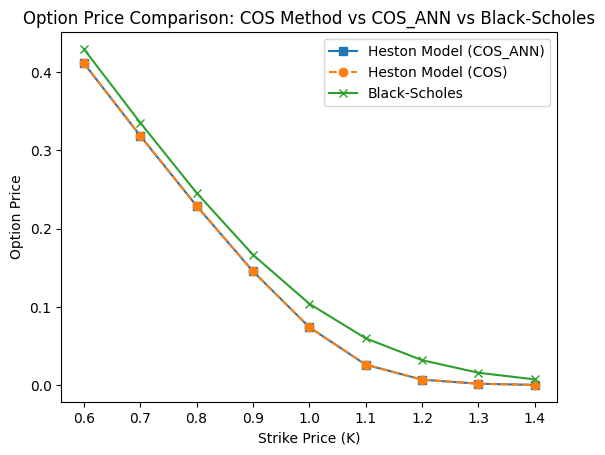

In [85]:
# New COS_v2 implementation wrapper
def COS_v2(S, t, K, IR, DY, params, N, L):
    kappa, vbar, gamma, v0, rho = params
    r = IR
    tau = t
    S_adjusted = S * np.exp(-DY * tau)  # Adjust spot price for dividend yield
    call_prices = []
    for strike in K:
        price = call_option_Heston(N, L, r, tau, kappa, gamma, vbar, v0, rho, strike, S_adjusted)
        call_prices.append(price[0, 0])
    return np.array(call_prices)

# Main function with both COS_method and COS_v2
def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    Xc = 12.1802 if t == 1.00 else 8.0
    Xm = 0
    N = 256  # Number of terms in COS expansion
    L = 12  # Truncation range for COS_v2

    # Prices using the original COS_method
    cos_prices = COS_method(S, t, K, IR, DY, "heston", params, Xc, Xm, N, CP, 1)
    
    # Prices using COS_v2
    cos_v2_prices = COS_v2(S, t, K, IR, DY, params, 1500, L)

    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    
    #plt.plot(K, cos_v2_prices, label="Heston Model (COS_ANN)", linestyle='--', marker='s')
    plt.plot(K, cos_v2_prices, label="Heston Model (COS_ANN)", marker='s')
    plt.plot(K, cos_prices, label="Heston Model (COS)", linestyle='--', marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: COS Method vs COS_ANN vs Black-Scholes")
    plt.legend()
    plt.show()

# Run the main function
main()


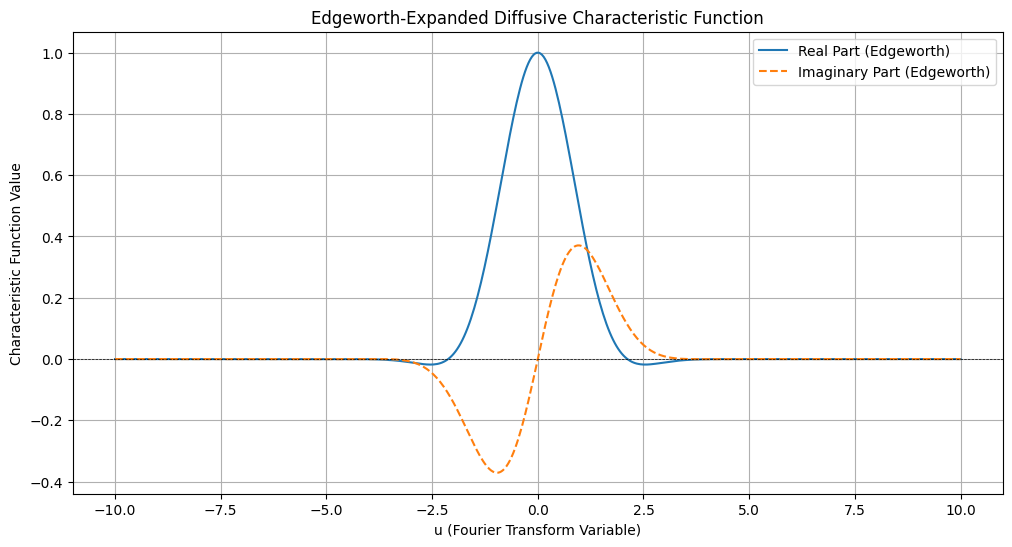

In [167]:
# Step 2: Expand the Continuous Component with Edgeworth Expansion

def edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    """
    Compute the diffusive characteristic function using the Edgeworth expansion.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.
    beta_t (float): Volatility-of-volatility.
    rho_t (float): Leverage (correlation between price and volatility changes).
    alpha_q_t (float): Drift of the volatility process under the risk-neutral measure.
    delta_t (float): Volatility of the drift of logarithmic prices.
    eta_t (float): Higher-order volatility correction.

    Returns:
    float: Value of the Edgeworth-expanded diffusive characteristic function.
    """
    # Gaussian component
    #base_gaussian = np.exp(1j * u * mu_t * tau - 0.5 * (u**2) * sigma_t**2 * tau)
    a = 1j*u*mu_t / (sigma_t * np.sqrt(tau))
    b = 0.5 * (u**2)
    base_gaussian = np.exp(a - b)

    # Skewness adjustment (third moment correction)
    skewness_term = -1j * (u**3) * (beta_t * rho_t) / (2 * sigma_t) * np.sqrt(tau)

    # Kurtosis and higher moment adjustments
    kurtosis_term = - (u**2) * ((alpha_q_t + delta_t) / (2 * sigma_t) + beta_t**2 / (4 * sigma_t**2)) * tau
    sixth_moment_term = (1 / 24) * (beta_t**2 / sigma_t**2) * (u**2) * (4 * u**2 - (rho_t**2 * u**2 * (3 * u**2 - 8))) * tau
    higher_order_term = (1 / 6) * (eta_t / sigma_t) * (u**4) * tau

    # Full Edgeworth-expanded characteristic function
    char_func = base_gaussian * (1 + skewness_term + kurtosis_term + sixth_moment_term + higher_order_term)
    return char_func

# Example Parameters for Edgeworth Expansion
tau = 0.1  # Time to maturity in years
mu_t = 0.05  # Risk-neutral drift
sigma_t = 0.25  # Spot volatility
beta_t = 0.1  # Volatility-of-volatility
rho_t = -0.4  # Leverage
alpha_q_t = 0.02  # Drift of the volatility under Q
delta_t = -0.015  # Volatility of the drift of logarithmic prices
eta_t = 0.01  # Higher-order volatility correction

# Evaluate the Edgeworth-expanded characteristic function for a range of u values
u_values = np.linspace(-10, 10, 500)
edgeworth_values = np.array([edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t,
                                                                         beta_t, rho_t, alpha_q_t, delta_t, eta_t) 
                              for u in u_values])

# Plot the real and imaginary parts of the Edgeworth-expanded characteristic function
plt.figure(figsize=(12, 6))
plt.plot(u_values, edgeworth_values.real, label="Real Part (Edgeworth)", linestyle='-')
plt.plot(u_values, edgeworth_values.imag, label="Imaginary Part (Edgeworth)", linestyle='--')
plt.title("Edgeworth-Expanded Diffusive Characteristic Function")
plt.xlabel("u (Fourier Transform Variable)")
plt.ylabel("Characteristic Function Value")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()


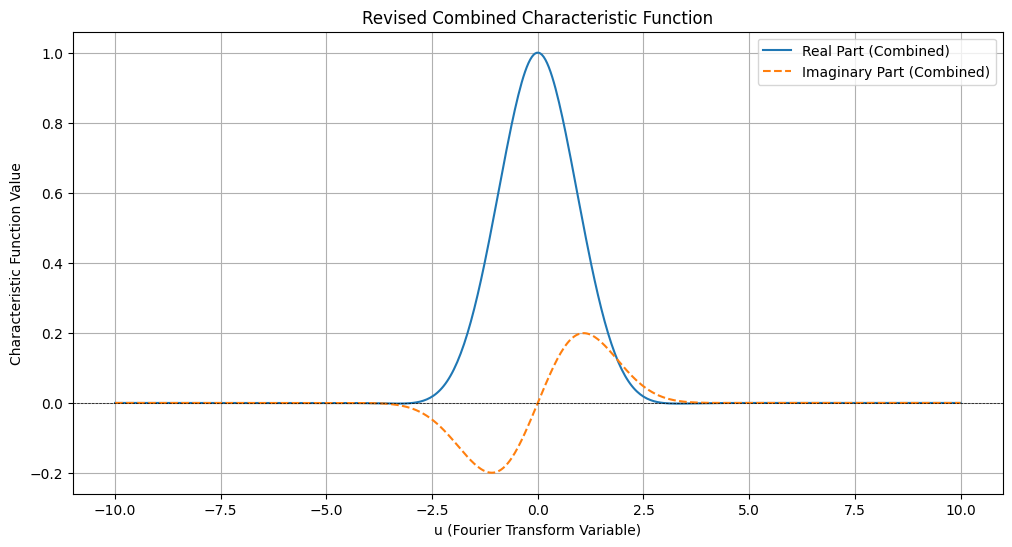

In [170]:
# Re-implementation of Step 1: Decompose the Characteristic Function

# Function for the jump characteristic function
def jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t):
    """
    Jump characteristic function for the log price process.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    lambda_t (float): Intensity of jumps.
    mu_jt (float): Mean of jump sizes.
    sigma_jt (float): Std. deviation of jump sizes.
    sigma_t (float): Spot volatility.

    Returns:
    float: Jump characteristic function value.
    """
    # Q-compensator ensuring risk-neutral pricing
    mu_bar_jt = np.exp(mu_jt / (sigma_t * np.sqrt(tau)) +
                       0.5 * (sigma_jt**2 / (sigma_t**2 * tau))) - 1

    # Jump characteristic function formula
    jump_cf = np.exp(tau * lambda_t * (
        np.exp(1j * u * mu_jt / (sigma_t * np.sqrt(tau))
               - (u**2 * sigma_jt**2) / (2 * sigma_t**2 * tau)) - 1 - 1j * u * mu_bar_jt))
    return jump_cf

# Function for the diffusive characteristic function
def diffusive_characteristic_function(u, tau, mu_t, sigma_t):
    """
    Gaussian diffusive characteristic function for the log price process.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.

    Returns:
    float: Diffusive characteristic function value.
    """
    # Gaussian diffusive characteristic function formula
    diff_cf = np.exp(1j * u * mu_t * tau - 0.5 * (u**2) * sigma_t**2 * tau)
    return diff_cf

# Combined characteristic function (product of jump and diffusive parts)
def combined_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    """
    Combined characteristic function (diffusive + jump components).

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    lambda_t (float): Intensity of jumps.
    mu_jt (float): Mean of jump sizes.
    sigma_jt (float): Std. deviation of jump sizes.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.

    Returns:
    float: Combined characteristic function value.
    """
    jump_cf = jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t)
    diff_cf = edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t)
    return jump_cf * diff_cf

# Example parameters for re-implementation
tau = 0.1  # Time to maturity in years
lambda_t = 0.25  # Jump intensity
mu_jt = -0.05  # Mean of jump sizes
sigma_jt = 0.15  # Std. deviation of jump sizes
mu_t = 0.03  # Risk-neutral drift
sigma_t = 0.20  # Spot volatility

# Example Parameters for Edgeworth Expansion
beta_t = 0.1  # Volatility-of-volatility
rho_t = -0.4  # Leverage
alpha_q_t = 0.02  # Drift of the volatility under Q
delta_t = -0.015  # Volatility of the drift of logarithmic prices
eta_t = 0.01  # Higher-order volatility correction

# Evaluate the characteristic function for a range of u values
u_values_revised = np.linspace(-10, 10, 500)
char_func_values_revised = np.array([combined_characteristic_function(
    u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t) for u in u_values_revised])

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(u_values_revised, char_func_values_revised.real, label="Real Part (Combined)", linestyle='-')
plt.plot(u_values_revised, char_func_values_revised.imag, label="Imaginary Part (Combined)", linestyle='--')
plt.title("Revised Combined Characteristic Function")
plt.xlabel("u (Fourier Transform Variable)")
plt.ylabel("Characteristic Function Value")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()


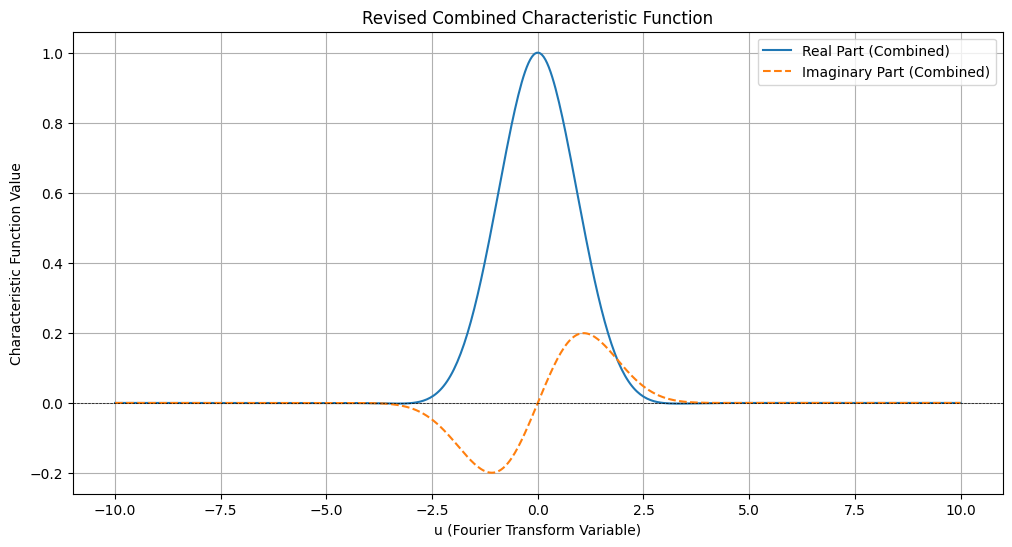

In [174]:
# Re-implementation of Step 1: Decompose the Characteristic Function

# Function for the jump characteristic function
def jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t):
    """
    Jump characteristic function for the log price process.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    lambda_t (float): Intensity of jumps.
    mu_jt (float): Mean of jump sizes.
    sigma_jt (float): Std. deviation of jump sizes.
    sigma_t (float): Spot volatility.

    Returns:
    float: Jump characteristic function value.
    """
    # Q-compensator ensuring risk-neutral pricing
    mu_bar_jt = np.exp(mu_jt / (sigma_t * np.sqrt(tau)) +
                       0.5 * (sigma_jt**2 / (sigma_t**2 * tau))) - 1

    # Jump characteristic function formula
    jump_cf = np.exp(tau * lambda_t * (
        np.exp(1j * u * mu_jt / (sigma_t * np.sqrt(tau))
               - (u**2 * sigma_jt**2) / (2 * sigma_t**2 * tau)) - 1 - 1j * u * mu_bar_jt))
    return jump_cf

# Function for the diffusive characteristic function
def edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    """
    Compute the diffusive characteristic function using the Edgeworth expansion.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.
    beta_t (float): Volatility-of-volatility.
    rho_t (float): Leverage (correlation between price and volatility changes).
    alpha_q_t (float): Drift of the volatility process under the risk-neutral measure.
    delta_t (float): Volatility of the drift of logarithmic prices.
    eta_t (float): Higher-order volatility correction.

    Returns:
    float: Value of the Edgeworth-expanded diffusive characteristic function.
    """
    # Gaussian component
    #base_gaussian = np.exp(1j * u * mu_t * tau - 0.5 * (u**2) * sigma_t**2 * tau)
    a = 1j*u*mu_t / (sigma_t * np.sqrt(tau))
    b = 0.5 * (u**2)
    base_gaussian = np.exp(a - b)

    # Skewness adjustment (third moment correction)
    skewness_term = -1j * (u**3) * (beta_t * rho_t) / (2 * sigma_t) * np.sqrt(tau)

    # Kurtosis and higher moment adjustments
    kurtosis_term = - (u**2) * ((alpha_q_t + delta_t) / (2 * sigma_t) + beta_t**2 / (4 * sigma_t**2)) * tau
    sixth_moment_term = (1 / 24) * (beta_t**2 / sigma_t**2) * (u**2) * (4 * u**2 - (rho_t**2 * u**2 * (3 * u**2 - 8))) * tau
    higher_order_term = (1 / 6) * (eta_t / sigma_t) * (u**4) * tau

    # Full Edgeworth-expanded characteristic function
    char_func = base_gaussian * (1 + skewness_term + kurtosis_term + sixth_moment_term + higher_order_term)
    return char_func

# Combined characteristic function (product of jump and diffusive parts)
def combined_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    """
    Combined characteristic function (diffusive + jump components).

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    lambda_t (float): Intensity of jumps.
    mu_jt (float): Mean of jump sizes.
    sigma_jt (float): Std. deviation of jump sizes.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.

    Returns:
    float: Combined characteristic function value.
    """
    jump_cf = jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t)
    diff_cf = edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t)
    return jump_cf * diff_cf

# Example parameters for re-implementation
tau = 0.1  # Time to maturity in years
lambda_t = 0.25  # Jump intensity
mu_jt = -0.05  # Mean of jump sizes
sigma_jt = 0.15  # Std. deviation of jump sizes
mu_t = 0.03  # Risk-neutral drift
sigma_t = 0.20  # Spot volatility

# Example Parameters for Edgeworth Expansion
beta_t = 0.1  # Volatility-of-volatility
rho_t = -0.4  # Leverage
alpha_q_t = 0.02  # Drift of the volatility under Q
delta_t = -0.015  # Volatility of the drift of logarithmic prices
eta_t = 0.01  # Higher-order volatility correction

# Evaluate the characteristic function for a range of u values
u_values_revised = np.linspace(-10, 10, 500)
char_func_values_revised = np.array([combined_characteristic_function(
    u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t) for u in u_values_revised])

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(u_values_revised, char_func_values_revised.real, label="Real Part (Combined)", linestyle='-')
plt.plot(u_values_revised, char_func_values_revised.imag, label="Imaginary Part (Combined)", linestyle='--')
plt.title("Revised Combined Characteristic Function")
plt.xlabel("u (Fourier Transform Variable)")
plt.ylabel("Characteristic Function Value")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()


In [173]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 2: SINC FFT to Compute Risk-Neutral Density
def sinc_fft_density(tau, char_func, Xc, Xm, pow):
    N = 2**pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)

    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))

    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu

    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    d1 = np.fft.fft(q1) + 0.5

    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    density = np.real(d1)
    return density, Z_values

# Step 3: Option Pricing from Risk-Neutral Density
def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    return np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)

# Step 4: Pricing Script
# Parameters
r = 0.05  # Risk-free rate
S = 100  # Current stock price
sigma_t = 0.2  # Spot volatility
tau = 0.1  # Time to maturity

# Edgeworth parameters
mu_t = 0.05
beta_t = 0.1
rho_t = -0.4
alpha_q_t = 0.02
delta_t = -0.015
eta_t = 0.01

lambda_t = 0.25  # Jump intensity

# SINC FFT parameters
Xc = 12.0
Xm = 0.0
pow = 12


jump_cf = jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t)
diff_cf = diffusive_characteristic_function(u, tau, mu_t, sigma_t)
# Define the combined characteristic function with Edgeworth adjustments
def edgeworth_combined_char_func(u, tau):
    jump_cf = jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t)
    diff_cf = edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t)
    return jump_cf*diff_cf

# Compute prices for a range of strike prices
strike_prices = np.linspace(80, 120, 10)
prices = []

density, Z_values = sinc_fft_density(tau, edgeworth_combined_char_func, Xc, Xm, pow)

for K in strike_prices:
    price = option_price_from_density(K, r, tau, density, Z_values, S, sigma_t)
    prices.append(price)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(strike_prices, prices, marker='o', label="Option Prices (Edgeworth Expansion)")
plt.title("Option Prices Across Strike Prices")
plt.xlabel("Strike Price (K)")
plt.ylabel("Option Price")
plt.legend()
plt.grid()
plt.show()


TypeError: combined_characteristic_function() missing 10 required positional arguments: 'lambda_t', 'mu_jt', 'sigma_jt', 'mu_t', 'sigma_t', 'beta_t', 'rho_t', 'alpha_q_t', 'delta_t', and 'eta_t'

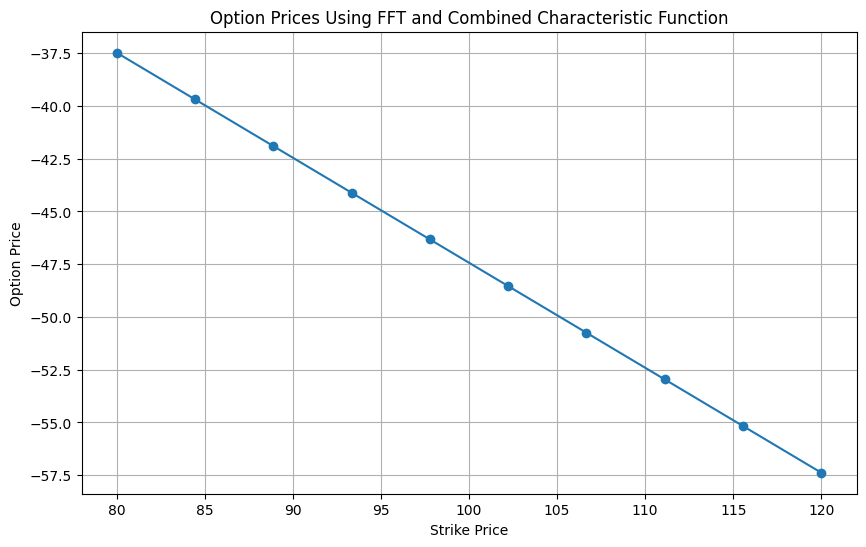

In [171]:
import numpy as np
import matplotlib.pyplot as plt

# Combined characteristic function from earlier implementation
def combined_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    """
    Combined characteristic function (diffusive + jump components).
    """
    # Jump characteristic function
    mu_bar_jt = np.exp(mu_jt / (sigma_t * np.sqrt(tau)) + 0.5 * (sigma_jt**2 / (sigma_t**2 * tau))) - 1
    jump_cf = np.exp(tau * lambda_t * (
        np.exp(1j * u * mu_jt / (sigma_t * np.sqrt(tau)) - (u**2 * sigma_jt**2) / (2 * sigma_t**2 * tau)) - 1 - 1j * u * mu_bar_jt))
    
    # Diffusive characteristic function (using Edgeworth expansion)
    a = 1j * u * mu_t / (sigma_t * np.sqrt(tau))
    b = 0.5 * u**2
    diff_cf_base = np.exp(a - b)
    skewness_term = -1j * (u**3) * (beta_t * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    kurtosis_term = -u**2 * ((alpha_q_t + delta_t) / (2 * sigma_t) + beta_t**2 / (4 * sigma_t**2)) * tau
    sixth_moment_term = (1 / 24) * (beta_t**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    higher_order_term = (1 / 6) * (eta_t / sigma_t) * (u**4) * tau
    diff_cf = diff_cf_base * (1 + skewness_term + kurtosis_term + sixth_moment_term + higher_order_term)
    
    return jump_cf * diff_cf

# Pricing function via Fourier inversion
def option_price_fft(S, K, tau, r, q, params, u_max=100, N=5000):
    """
    Compute European option prices using FFT with the combined characteristic function.
    
    Parameters:
    S: float - Spot price.
    K: array - Strike prices.
    tau: float - Time to maturity.
    r: float - Risk-free rate.
    q: float - Dividend yield.
    params: dict - Parameters for the combined characteristic function.
    u_max: float - Integration upper limit.
    N: int - Number of integration points.
    
    Returns:
    prices: array - Option prices for each strike price.
    """
    # Define Fourier variable
    u = np.linspace(1e-5, u_max, N)
    du = u[1] - u[0]
    
    # Compute characteristic function values
    phi = np.array([combined_characteristic_function(
        u_val, tau, params['lambda_t'], params['mu_jt'], params['sigma_jt'], params['mu_t'], params['sigma_t'],
        params['beta_t'], params['rho_t'], params['alpha_q_t'], params['delta_t'], params['eta_t']
    ) for u_val in u])
    
    # Fourier transform components for price calculation
    d1_part = np.exp(-1j * u * np.log(K)) * phi / (1j * u)
    d2_part = np.exp(-1j * u * np.log(K)) * phi / (1j * (u + 1j))
    
    # Numerical integration (trapezoidal rule)
    d1 = np.trapz(d1_part.real, dx=du)
    d2 = np.trapz(d2_part.real, dx=du)
    
    # Option price components
    discounted_stock = S * np.exp(-q * tau) * (0.5 + (1 / np.pi) * d1)
    discounted_strike = K * np.exp(-r * tau) * (0.5 + (1 / np.pi) * d2)
    
    # Call price
    call_price = discounted_stock - discounted_strike
    
    return call_price

# Parameters for the combined characteristic function
params = {
    'lambda_t': 0.25,  # Jump intensity
    'mu_jt': -0.05,    # Mean of jump sizes
    'sigma_jt': 0.15,  # Std. deviation of jump sizes
    'mu_t': 0.03,      # Risk-neutral drift
    'sigma_t': 0.20,   # Spot volatility
    'beta_t': 0.1,     # Volatility-of-volatility
    'rho_t': -0.4,     # Leverage
    'alpha_q_t': 0.02, # Drift of the volatility under Q
    'delta_t': -0.015, # Volatility of the drift of logarithmic prices
    'eta_t': 0.01      # Higher-order volatility correction
}

# Example parameters for pricing
S = 100           # Spot price
K = np.linspace(80, 120, 10)  # Strike prices
tau = 0.1         # Time to maturity (in years)
r = 0.05          # Risk-free rate
q = 0.02          # Dividend yield

# Compute option prices
prices = [option_price_fft(S, k, tau, r, q, params) for k in K]

# Plot option prices
plt.figure(figsize=(10, 6))
plt.plot(K, prices, marker='o')
plt.title("Option Prices Using FFT and Combined Characteristic Function")
plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.grid()
plt.show()


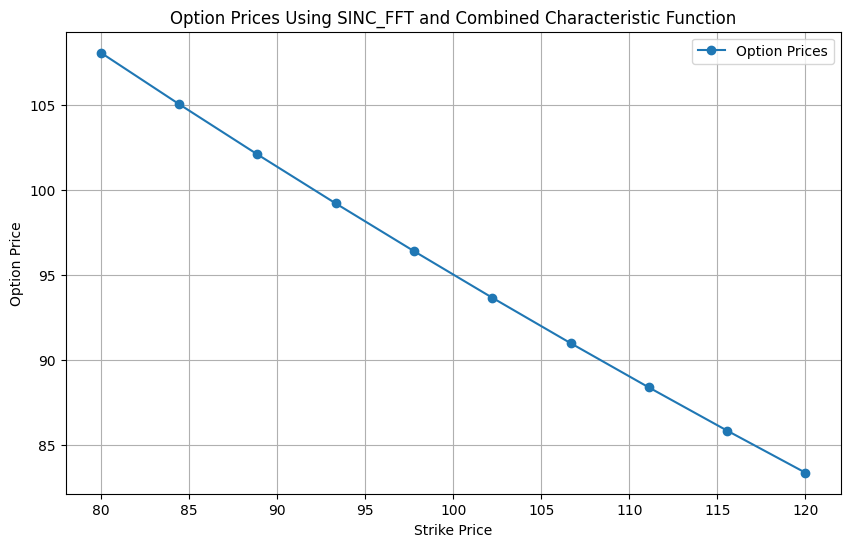

In [172]:
import numpy as np

# SINC_FFT function adapted to use the combined characteristic function
def sinc_fft_paper(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    """
    Compute option prices using the SINC_FFT approach with the combined characteristic function.
    
    Parameters:
    S: float - Spot price.
    t: float - Time to maturity.
    K: array - Strike prices.
    IR: float - Risk-free interest rate.
    DY: float - Dividend yield.
    params: dict - Parameters for the combined characteristic function.
    Xc: float - Truncation range.
    Xm: float - Centering parameter for log-moneyness.
    pow: int - FFT resolution (power of 2).
    CP: int - Call (1) or Put (0).
    
    Returns:
    array: Option prices for given strike prices.
    """
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow  # Number of FFT points

    # Truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    # Fourier modes
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * np.array(
        [combined_characteristic_function(2 * np.pi * w, t, **params) for w in wn]
    )
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * np.array(
        [combined_characteristic_function(2 * np.pi * w - 1j, t, **params) for w in wn]
    )

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))

    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu

    # FFT-ready arrays
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])

    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5

    # Extract FFT components
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]

    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])

    # Log-moneyness grid
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)

    # Compute option prices
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)

    # Interpolation to strike prices
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Return call or put prices
    return call if CP == 1 else put

# Define parameters for the combined characteristic function
params = {
    'lambda_t': 0.25,  # Jump intensity
    'mu_jt': -0.05,    # Mean of jump sizes
    'sigma_jt': 0.15,  # Std. deviation of jump sizes
    'mu_t': 0.03,      # Risk-neutral drift
    'sigma_t': 0.20,   # Spot volatility
    'beta_t': 0.1,     # Volatility-of-volatility
    'rho_t': -0.4,     # Leverage
    'alpha_q_t': 0.02, # Drift of volatility under Q
    'delta_t': -0.015, # Volatility drift
    'eta_t': 0.01      # Higher-order correction
}

# Example parameters for pricing
S = 100           # Spot price
t = 0.1           # Time to maturity
K = np.linspace(80, 120, 10)  # Strike prices
IR = 0.05         # Risk-free rate
DY = 0.02         # Dividend yield
Xc = 12.0         # Truncation range
Xm = 0            # Center of moneyness
pow = 10          # FFT resolution (2^10 points)
CP = 1            # Call options

# Compute option prices using SINC_FFT
option_prices = sinc_fft_paper(S, t, K, IR, DY, params, Xc, Xm, pow, CP)

# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(K, option_prices, marker='o', label="Option Prices")
plt.title("Option Prices Using SINC_FFT and Combined Characteristic Function")
plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.grid()
plt.legend()
plt.show()


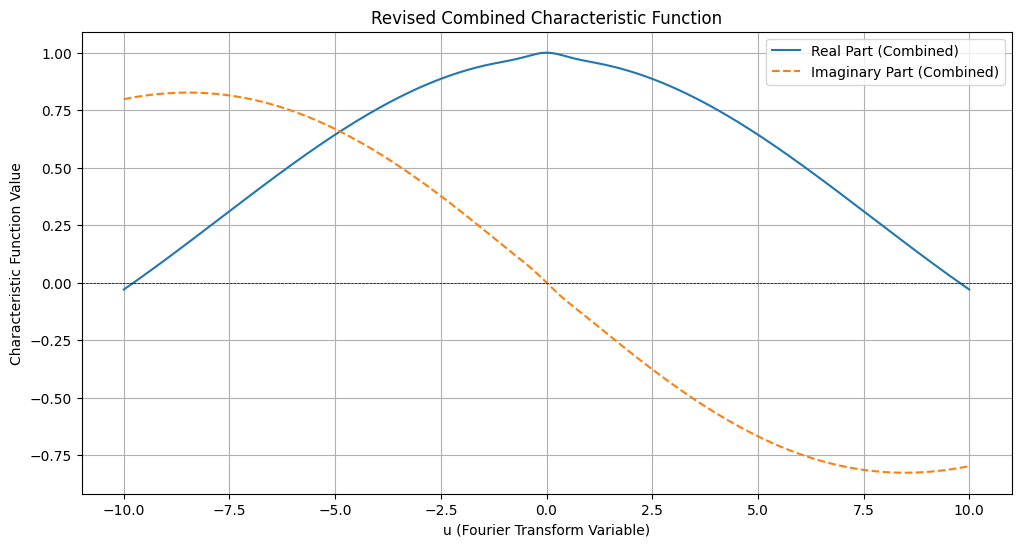

In [169]:
# Re-implementation of Step 1: Decompose the Characteristic Function

# Function for the jump characteristic function
def jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t):
    """
    Jump characteristic function for the log price process.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    lambda_t (float): Intensity of jumps.
    mu_jt (float): Mean of jump sizes.
    sigma_jt (float): Std. deviation of jump sizes.
    sigma_t (float): Spot volatility.

    Returns:
    float: Jump characteristic function value.
    """
    # Q-compensator ensuring risk-neutral pricing
    mu_bar_jt = np.exp(mu_jt / (sigma_t * np.sqrt(tau)) +
                       0.5 * (sigma_jt**2 / (sigma_t**2 * tau))) - 1

    # Jump characteristic function formula
    jump_cf = np.exp(tau * lambda_t * (
        np.exp(1j * u * mu_jt / (sigma_t * np.sqrt(tau))
               - (u**2 * sigma_jt**2) / (2 * sigma_t**2 * tau)) - 1 - 1j * u * mu_bar_jt))
    return jump_cf

# Function for the diffusive characteristic function
def diffusive_characteristic_function(u, tau, mu_t, sigma_t):
    """
    Gaussian diffusive characteristic function for the log price process.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.

    Returns:
    float: Diffusive characteristic function value.
    """
    # Gaussian diffusive characteristic function formula
    diff_cf = np.exp(1j * u * mu_t * tau - 0.5 * (u**2) * sigma_t**2 * tau)
    return diff_cf

# Combined characteristic function (product of jump and diffusive parts)
def combined_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t):
    """
    Combined characteristic function (diffusive + jump components).

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    lambda_t (float): Intensity of jumps.
    mu_jt (float): Mean of jump sizes.
    sigma_jt (float): Std. deviation of jump sizes.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.

    Returns:
    float: Combined characteristic function value.
    """
    jump_cf = jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t)
    diff_cf = diffusive_characteristic_function(u, tau, mu_t, sigma_t)
    return jump_cf * diff_cf

# Example parameters for re-implementation
tau = 0.1  # Time to maturity in years
lambda_t = 0.25  # Jump intensity
mu_jt = -0.05  # Mean of jump sizes
sigma_jt = 0.15  # Std. deviation of jump sizes
mu_t = 0.03  # Risk-neutral drift
sigma_t = 0.20  # Spot volatility

# Evaluate the characteristic function for a range of u values
u_values_revised = np.linspace(-10, 10, 500)
char_func_values_revised = np.array([combined_characteristic_function(
    u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t) for u in u_values_revised])

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(u_values_revised, char_func_values_revised.real, label="Real Part (Combined)", linestyle='-')
plt.plot(u_values_revised, char_func_values_revised.imag, label="Imaginary Part (Combined)", linestyle='--')
plt.title("Revised Combined Characteristic Function")
plt.xlabel("u (Fourier Transform Variable)")
plt.ylabel("Characteristic Function Value")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()


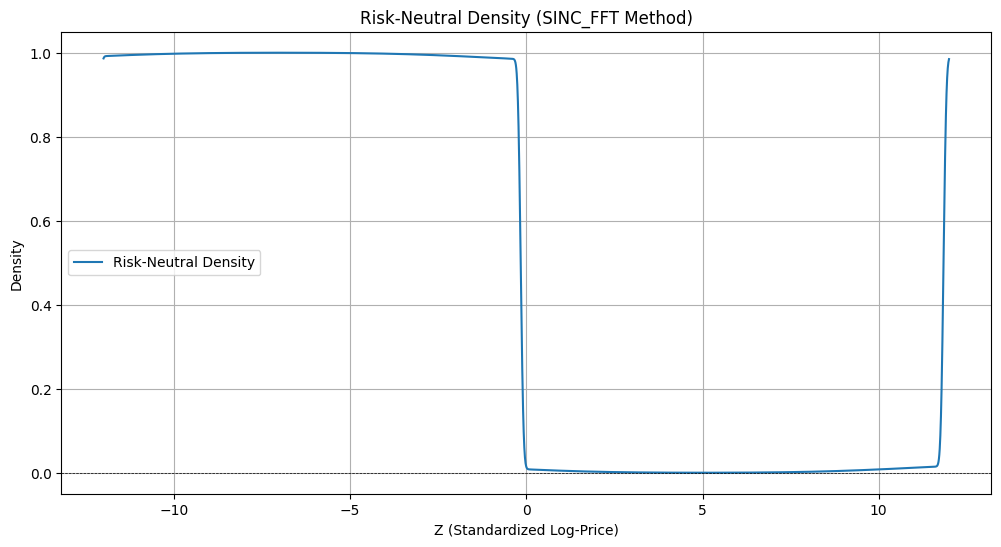

11.994226521540106

In [145]:
# Adaptation of SINC_FFT to compute the risk-neutral density

def sinc_fft_density(u_values, tau, char_func, Xc, Xm, pow):
    """
    Compute risk-neutral density using the SINC_FFT method.

    Parameters:
    u_values (array): Fourier transform variables (frequencies).
    tau (float): Time to maturity.
    char_func (function): Combined characteristic function.
    Xc (float): Center of truncation range.
    Xm (float): Shift in truncation range.
    pow (int): Power for FFT precision (determines the number of Fourier coefficients).

    Returns:
    tuple: (density, grid of Z values)
    """
    N = 2 ** pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    # Fourier modes
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    # Compute characteristic function values for the SINC method
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)
    
    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    
    # Grid of Z values for density
    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    # Risk-neutral density
    density = np.real(d1)
    
    return density, Z_values

# Define the combined characteristic function for the log price process
def combined_char_func(u, tau):
    return combined_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, mu_t, sigma_t)

# Parameters for the SINC FFT computation
tau = 0.1  # Time to maturity
pow = 12  # FFT precision (higher for finer resolution)
Xc = 12.0  # Truncation range
Xm = 0.0  # Centering shift

# Compute the risk-neutral density
u_values_sinc = np.linspace(-10, 10, 500)
density, Z_values = sinc_fft_density(u_values_sinc, tau, combined_char_func, Xc, Xm, pow)

# Verify density integrates to 1 and plot the results
integral_density = np.trapz(density, Z_values)  # Numerical integration

# Plot the density
plt.figure(figsize=(12, 6))
plt.plot(Z_values, density, label="Risk-Neutral Density")
plt.title("Risk-Neutral Density (SINC_FFT Method)")
plt.xlabel("Z (Standardized Log-Price)")
plt.ylabel("Density")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

integral_density


In [133]:
# Step 3: Option Pricing Integration Using Risk-Neutral Density

def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    """
    Compute option prices using the risk-neutral density.

    Parameters:
    K (float): Strike price.
    r (float): Risk-free rate.
    tau (float): Time to maturity.
    density (array): Risk-neutral density values.
    Z_values (array): Grid of Z values corresponding to the density.
    S (float): Underlying asset price.
    sigma_t (float): Spot volatility.

    Returns:
    float: Call option price.
    """
    # Parameters for the integration
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    
    # Transform Z values to price space
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    
    # Strike price integration bound
    Z_bound = (np.log(K) - a_tau) / b_tau

    # Integrate to compute the call price
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    call_price = np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)
    
    return call_price

# Example parameters
r = 0.05  # Risk-free rate
S = 100  # Current stock price
K = 100  # Strike price
sigma_t = 0.2  # Spot volatility
tau = 0.1  # Time to maturity
u = 0

density_fixed, Z_values_fixed = sinc_fft_density(u, tau, combined_char_func, Xc, Xm, pow)

# Compute the call price using the risk-neutral density
call_price = option_price_from_density(K, r, tau, density_fixed, Z_values_fixed, S, sigma_t)

call_price


20.555432057435308

In [135]:
from scipy.stats import norm

# Black-Scholes formula for call option price
def black_scholes_call(S, K, r, sigma, tau):
    """
    Compute the Black-Scholes call option price.

    Parameters:
    S (float): Current stock price.
    K (float): Strike price.
    r (float): Risk-free interest rate.
    sigma (float): Volatility.
    tau (float): Time to maturity.

    Returns:
    float: Call option price.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    return call_price

# Compute Black-Scholes price
bs_price = black_scholes_call(S, K, r, sigma_t, tau)

# Compare the results
bs_price, call_price, abs(bs_price - call_price)


(2.7736541464188775, 20.555432057435308, 17.78177791101643)

In [137]:
# Redefine the characteristic function for diffusion-only (no jumps)
def diffusion_only_char_func(u, tau):
    """
    Compute the characteristic function for the diffusive component only (no jumps).

    Parameters:
    u (float): Fourier variable.
    tau (float): Time to maturity.

    Returns:
    float: Diffusive characteristic function value.
    """
    return diffusive_characteristic_function_revised(u, tau, mu_t, sigma_t)

# Recompute risk-neutral density using diffusion-only characteristic function
density_diffusion_only, Z_values_diffusion_only = sinc_fft_density(tau, diffusion_only_char_func, Xc, Xm, pow)

# Compute the call price using the diffusion-only density
call_price_diffusion_only = option_price_from_density(K, r, tau, density_diffusion_only, Z_values_diffusion_only, S, sigma_t)

# Compare the diffusion-only price with Black-Scholes price
bs_price, call_price_diffusion_only, abs(bs_price - call_price_diffusion_only)


TypeError: sinc_fft_density() missing 1 required positional argument: 'pow'

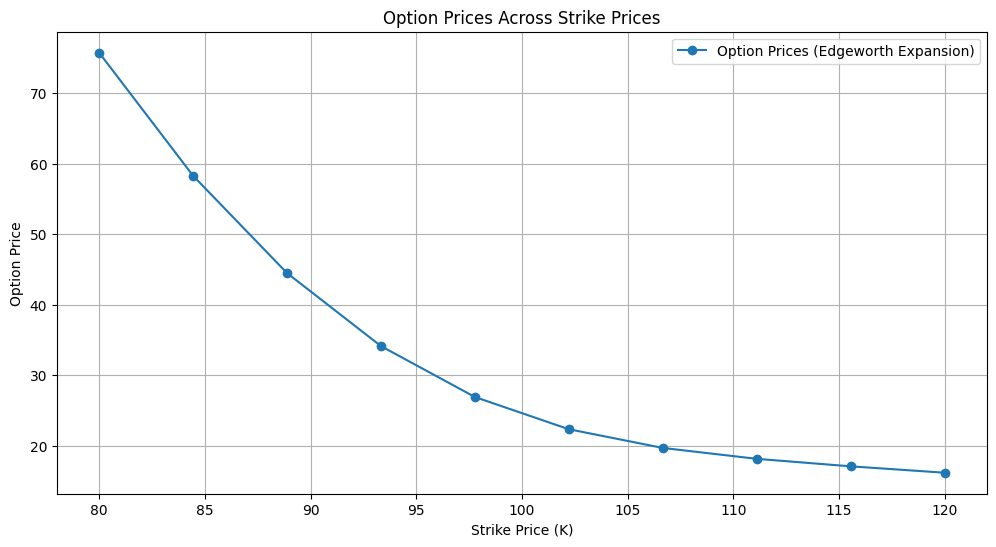

In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 1: Edgeworth-Expanded Diffusive Characteristic Function
def edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    """
    Compute the diffusive characteristic function using the Edgeworth expansion.

    Parameters:
    u (float): Fourier transform variable.
    tau (float): Time to maturity.
    mu_t (float): Risk-neutral drift.
    sigma_t (float): Spot volatility.
    beta_t (float): Volatility-of-volatility.
    rho_t (float): Leverage (correlation between price and volatility changes).
    alpha_q_t (float): Drift of the volatility process under the risk-neutral measure.
    delta_t (float): Volatility of the drift of logarithmic prices.
    eta_t (float): Higher-order volatility correction.

    Returns:
    float: Value of the Edgeworth-expanded diffusive characteristic function.
    """
    a = 1j * u * mu_t / (sigma_t * np.sqrt(tau))
    b = 0.5 * (u**2)
    base_gaussian = np.exp(a - b)

    skewness_term = -1j * (u**3) * (beta_t * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    kurtosis_term = - (u**2) * ((alpha_q_t + delta_t) / (2 * sigma_t) + beta_t**2 / (4 * sigma_t**2)) * tau
    sixth_moment_term = (1 / 24) * (beta_t**2 / sigma_t**2) * (u**2) * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    higher_order_term = (1 / 6) * (eta_t / sigma_t) * (u**4) * tau

    return base_gaussian * (1 + skewness_term + kurtosis_term + sixth_moment_term + higher_order_term)

# Step 2: SINC FFT to Compute Risk-Neutral Density
def sinc_fft_density(tau, char_func, Xc, Xm, pow):
    N = 2**pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)

    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))

    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu

    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    d1 = np.fft.fft(q1) + 0.5

    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    density = np.real(d1)
    return density, Z_values

# Step 3: Option Pricing from Risk-Neutral Density
def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    return np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)

# Step 4: Pricing Script
# Parameters
r = 0.05  # Risk-free rate
S = 100  # Current stock price
sigma_t = 0.2  # Spot volatility
tau = 0.1  # Time to maturity

# Edgeworth parameters
mu_t = 0.05
beta_t = 0.1
rho_t = -0.4
alpha_q_t = 0.02
delta_t = -0.015
eta_t = 0.01

lambda_t = 0.25  # Jump intensity

# SINC FFT parameters
Xc = 12.0
Xm = 0.0
pow = 12


jump_cf = jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t)
diff_cf = diffusive_characteristic_function(u, tau, mu_t, sigma_t)
# Define the combined characteristic function with Edgeworth adjustments
def edgeworth_combined_char_func(u, tau):
    jump_cf = jump_characteristic_function(u, tau, lambda_t, mu_jt, sigma_jt, sigma_t)
    diff_cf = edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t)
    return jump_cf*diff_cf

# Compute prices for a range of strike prices
strike_prices = np.linspace(80, 120, 10)
prices = []

density, Z_values = sinc_fft_density(tau, edgeworth_combined_char_func, Xc, Xm, pow)

for K in strike_prices:
    price = option_price_from_density(K, r, tau, density, Z_values, S, sigma_t)
    prices.append(price)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(strike_prices, prices, marker='o', label="Option Prices (Edgeworth Expansion)")
plt.title("Option Prices Across Strike Prices")
plt.xlabel("Strike Price (K)")
plt.ylabel("Option Price")
plt.legend()
plt.grid()
plt.show()


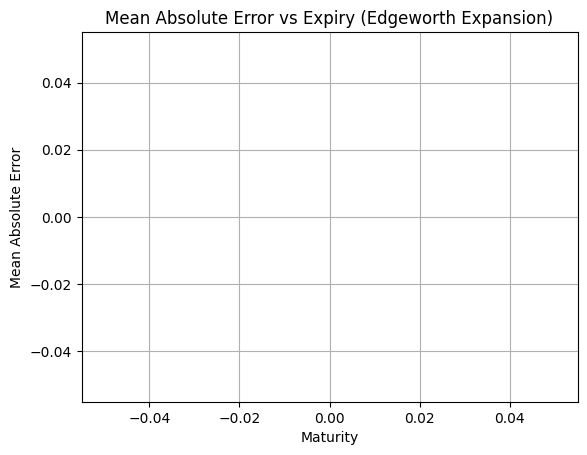

In [149]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Black-Scholes implied volatility function
def bs_implied_vol_put(S, K, T, r, price):
    def bs_price(sigma):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    def objective(sigma):
        return bs_price(sigma) - price

    try:
        implied_vol = brentq(objective, 1e-6, 5)
    except:
        implied_vol = np.nan
    return implied_vol

# Edgeworth-expanded characteristic function
def edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    a = 1j * u * mu_t / (sigma_t * np.sqrt(tau))
    b = 0.5 * (u**2)
    base_gaussian = np.exp(a - b)

    skewness_term = -1j * (u**3) * (beta_t * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    kurtosis_term = - (u**2) * ((alpha_q_t + delta_t) / (2 * sigma_t) + beta_t**2 / (4 * sigma_t**2)) * tau
    sixth_moment_term = (1 / 24) * (beta_t**2 / sigma_t**2) * (u**2) * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    higher_order_term = (1 / 6) * (eta_t / sigma_t) * (u**4) * tau

    return base_gaussian * (1 + skewness_term + kurtosis_term + sixth_moment_term + higher_order_term)

# SINC FFT for risk-neutral density
def sinc_fft_density(tau, char_func, Xc, Xm, pow):
    N = 2**pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)

    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))

    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu

    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    d1 = np.fft.fft(q1) + 0.5

    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    density = np.real(d1)
    return density, Z_values

# Option pricing from density
def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    return np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)

# Load market data
data = []
with open('spx_surf20130814.csv', 'r', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        data.append(row)

structured_data = {col.strip(): np.array([float(row[col]) for row in data]) for col in data[0].keys()}
expiries = np.unique(structured_data['t'])
errors = []

# Edgeworth parameters
mu_t = 0.05
sigma_t = 0.2
beta_t = 0.1
rho_t = -0.4
alpha_q_t = 0.02
delta_t = -0.015
eta_t = 0.01

# SINC FFT parameters
Xc = 12.0
Xm = 0.0
pow = 14

# Loop through expiries
for expiry in expiries:
    subset_indices = structured_data['t'] == expiry
    fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]
    impVol_bench = structured_data['impVol'][subset_indices]

    # Compute risk-neutral density
    def edgeworth_combined_char_func(u, tau):
        return edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t)

    density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

    # Model prices
    prices = np.array([option_price_from_density(k, 0, t, density, Z_values, fwd, sigma_t) for k in K])

    # Compute implied volatilities
    impVol_model = np.array([bs_implied_vol_put(fwd, k, t, 0, p) for k, p in zip(K, prices)])

    # Calculate error
    error = np.mean(np.abs(impVol_model - impVol_bench))
    errors.append(error)

# Plot errors across expiries
plt.plot(expiries, errors, marker='o')
plt.xlabel('Maturity')
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error vs Expiry (Edgeworth Expansion)')
plt.grid(True)
plt.show()


Expiries: [0.00821355 0.02464066 0.04380561 0.06297057 0.08213552 0.10403833
 0.12867899 0.18069815 0.25735797 0.35318275 0.38056126 0.42984257
 0.60232717 0.62696783 0.8514716  0.87611225 1.34976044 1.42642026
 2.34633812]
Processing expiry 0.008213552 with 34 strikes
Processing expiry 0.024640657 with 64 strikes
Processing expiry 0.043805613 with 68 strikes
Processing expiry 0.062970568 with 70 strikes
Processing expiry 0.082135524 with 77 strikes
Processing expiry 0.10403833 with 111 strikes
Processing expiry 0.128678987 with 95 strikes
Processing expiry 0.180698152 with 112 strikes
Processing expiry 0.257357974 with 90 strikes
Processing expiry 0.353182752 with 81 strikes
Processing expiry 0.380561259 with 40 strikes
Processing expiry 0.429842574 with 57 strikes
Processing expiry 0.602327173 with 55 strikes
Processing expiry 0.62696783 with 46 strikes
Processing expiry 0.851471595 with 56 strikes
Processing expiry 0.876112252 with 47 strikes
Processing expiry 1.349760438 with 67 st

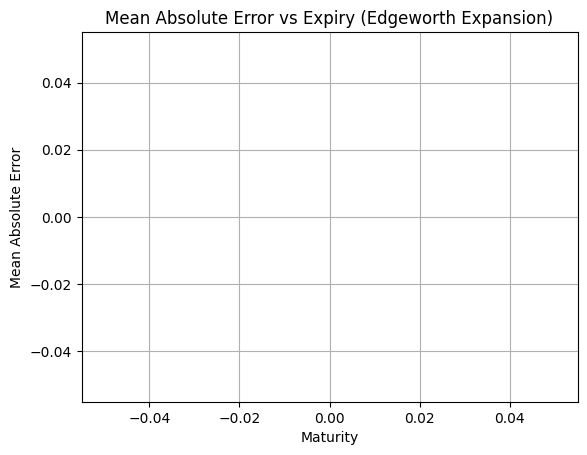

In [150]:
# Debugging-enhanced implementation
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Black-Scholes implied volatility function (unchanged)
def bs_implied_vol_put(S, K, T, r, price):
    def bs_price(sigma):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    def objective(sigma):
        return bs_price(sigma) - price

    try:
        implied_vol = brentq(objective, 1e-6, 5)
    except:
        implied_vol = np.nan
    return implied_vol

# Edgeworth-expanded characteristic function (unchanged)
def edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    a = 1j * u * mu_t / (sigma_t * np.sqrt(tau))
    b = 0.5 * (u**2)
    base_gaussian = np.exp(a - b)

    skewness_term = -1j * (u**3) * (beta_t * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    kurtosis_term = - (u**2) * ((alpha_q_t + delta_t) / (2 * sigma_t) + beta_t**2 / (4 * sigma_t**2)) * tau
    sixth_moment_term = (1 / 24) * (beta_t**2 / sigma_t**2) * (u**2) * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    higher_order_term = (1 / 6) * (eta_t / sigma_t) * (u**4) * tau

    return base_gaussian * (1 + skewness_term + kurtosis_term + sixth_moment_term + higher_order_term)

# SINC FFT for risk-neutral density (unchanged)
def sinc_fft_density(tau, char_func, Xc, Xm, pow):
    N = 2**pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)

    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))

    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu

    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    d1 = np.fft.fft(q1) + 0.5

    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    density = np.real(d1)
    return density, Z_values

# Option pricing from density (unchanged)
def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    return np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)

# Load market data
data = []
with open('spx_surf20130814.csv', 'r', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        data.append(row)

structured_data = {col.strip(): np.array([float(row[col]) for row in data]) for col in data[0].keys()}
expiries = np.unique(structured_data['t'])
errors = []

# Edgeworth parameters
mu_t = 0.05
sigma_t = 0.2
beta_t = 0.1
rho_t = -0.4
alpha_q_t = 0.02
delta_t = -0.015
eta_t = 0.01

# SINC FFT parameters
Xc = 12.0
Xm = 0.0
pow = 14

# Debugging outputs
print("Expiries:", expiries)

# Loop through expiries
for expiry in expiries:
    subset_indices = structured_data['t'] == expiry
    fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]
    impVol_bench = structured_data['impVol'][subset_indices]

    if len(K) == 0:
        print(f"No data found for expiry {expiry}")
        continue

    print(f"Processing expiry {expiry} with {len(K)} strikes")

    # Compute risk-neutral density
    def edgeworth_combined_char_func(u, tau):
        return edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t)

    density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

    # Model prices
    prices = np.array([option_price_from_density(k, 0, t, density, Z_values, fwd, sigma_t) for k in K])

    # Compute implied volatilities
    impVol_model = np.array([bs_implied_vol_put(fwd, k, t, 0, p) for k, p in zip(K, prices)])

    # Calculate error
    if len(impVol_model) != len(impVol_bench):
        print(f"Mismatch in implied volatilities for expiry {expiry}")
        continue

    error = np.mean(np.abs(impVol_model - impVol_bench))
    errors.append(error)

# Plot errors across expiries
if len(errors) > 0:
    plt.plot(expiries, errors, marker='o')
    plt.xlabel('Maturity')
    plt.ylabel('Mean Absolute Error')
    plt.title('Mean Absolute Error vs Expiry (Edgeworth Expansion)')
    plt.grid(True)
    plt.show()
else:
    print("No valid data to plot.")


Expiries: [0.00821355 0.02464066 0.04380561 0.06297057 0.08213552 0.10403833
 0.12867899 0.18069815 0.25735797 0.35318275 0.38056126 0.42984257
 0.60232717 0.62696783 0.8514716  0.87611225 1.34976044 1.42642026
 2.34633812]
Processing expiry 0.008213552 with 34 strikes
Prices for expiry 0.008213552: [675.05698995 642.16281522 610.14434895 578.99883712 548.72352583] ...
Implied volatilities (model) for expiry 0.008213552: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.008213552: [0.29551991 0.29097279 0.2863691  0.28170547 0.27697831] ...
Mean absolute error for expiry 0.008213552: nan
Processing expiry 0.024640657 with 64 strikes
Prices for expiry 0.024640657: [1239.54770349 1170.16992839 1103.01960202 1038.08129333  975.33970677] ...
Implied volatilities (model) for expiry 0.024640657: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.024640657: [0.34617137 0.34057508 0.33493309 0.3292412  0.32349504] ...
Mean absolute error for expiry 0.0246

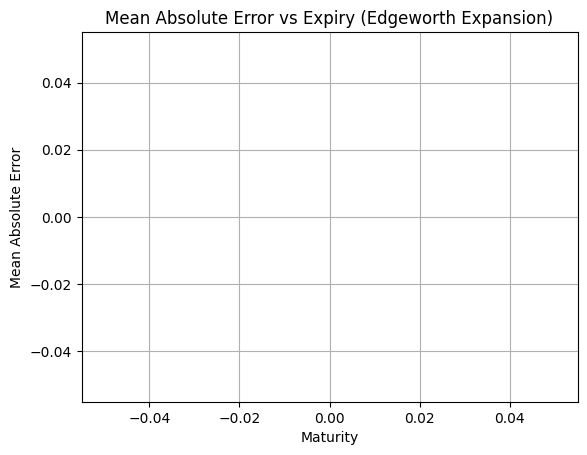

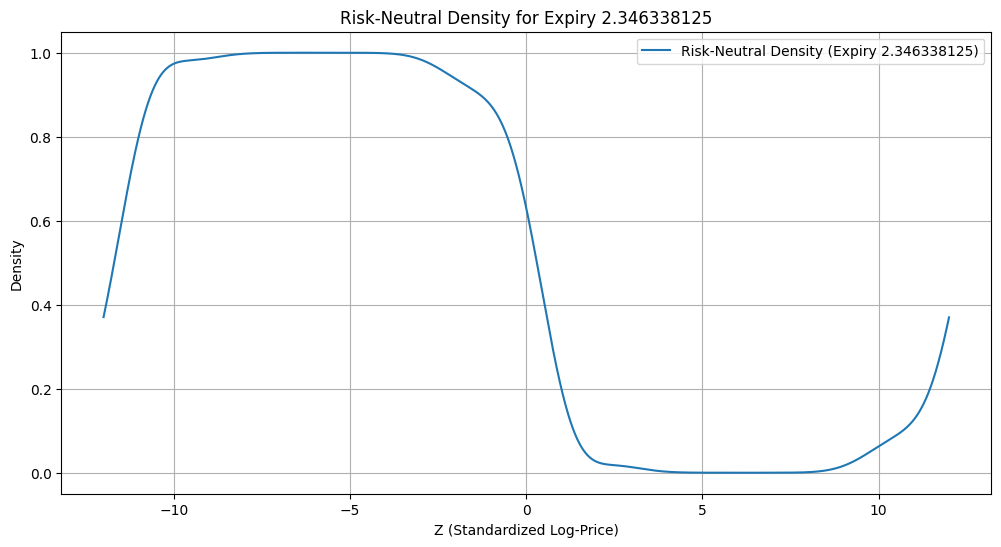

In [152]:
# Debugging-enhanced implementation
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Black-Scholes implied volatility function (unchanged)
def bs_implied_vol_put(S, K, T, r, price):
    def bs_price(sigma):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    def objective(sigma):
        return bs_price(sigma) - price

    try:
        implied_vol = brentq(objective, 1e-6, 5)
    except:
        implied_vol = np.nan
    return implied_vol

# Edgeworth-expanded characteristic function (unchanged)
def edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t):
    a = 1j * u * mu_t / (sigma_t * np.sqrt(tau))
    b = 0.5 * (u**2)
    base_gaussian = np.exp(a - b)

    skewness_term = -1j * (u**3) * (beta_t * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    kurtosis_term = - (u**2) * ((alpha_q_t + delta_t) / (2 * sigma_t) + beta_t**2 / (4 * sigma_t**2)) * tau
    sixth_moment_term = (1 / 24) * (beta_t**2 / sigma_t**2) * (u**2) * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    higher_order_term = (1 / 6) * (eta_t / sigma_t) * (u**4) * tau

    return base_gaussian * (1 + skewness_term + kurtosis_term + sixth_moment_term + higher_order_term)

# SINC FFT for risk-neutral density (unchanged)
def sinc_fft_density(tau, char_func, Xc, Xm, pow):
    N = 2**pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)

    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))

    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu

    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    d1 = np.fft.fft(q1) + 0.5

    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    density = np.real(d1)
    return density, Z_values

# Option pricing from density (unchanged)
def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    return np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)

# Load market data
data = []
with open('spx_surf20130814.csv', 'r', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        data.append(row)

structured_data = {col.strip(): np.array([float(row[col]) for row in data]) for col in data[0].keys()}
expiries = np.unique(structured_data['t'])
errors = []

# Edgeworth parameters
mu_t = 0.05
sigma_t = 0.2
beta_t = 0.1
rho_t = -0.4
alpha_q_t = 0.02
delta_t = -0.015
eta_t = 0.01

# SINC FFT parameters
Xc = 12.0
Xm = 0.0
pow = 14

# Debugging outputs
print("Expiries:", expiries)

for expiry in expiries:
    subset_indices = structured_data['t'] == expiry
    fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]
    impVol_bench = structured_data['impVol'][subset_indices]

    if len(K) == 0:
        print(f"No data found for expiry {expiry}")
        continue

    print(f"Processing expiry {expiry} with {len(K)} strikes")

    # Compute risk-neutral density
    def edgeworth_combined_char_func(u, tau):
        return edgeworth_diffusive_characteristic_function(u, tau, mu_t, sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t)

    density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

    # Model prices
    prices = np.array([option_price_from_density(k, 0, t, density, Z_values, fwd, sigma_t) for k in K])
    print(f"Prices for expiry {expiry}: {prices[:5]} ...")  # Print first 5 prices for brevity

    # Compute implied volatilities
    impVol_model = np.array([bs_implied_vol_put(fwd, k, t, 0, p) for k, p in zip(K, prices)])
    print(f"Implied volatilities (model) for expiry {expiry}: {impVol_model[:5]} ...")  # Print first 5 vols

    # Check benchmark implied volatilities
    print(f"Benchmark implied volatilities for expiry {expiry}: {impVol_bench[:5]} ...")  # First 5 vols

    # Validate lengths
    if len(impVol_model) != len(impVol_bench):
        print(f"Length mismatch for expiry {expiry}: model ({len(impVol_model)}), bench ({len(impVol_bench)})")
        continue

    # Calculate error
    error = np.mean(np.abs(impVol_model - impVol_bench))
    print(f"Mean absolute error for expiry {expiry}: {error}")
    errors.append(error)


# Plot errors across expiries
if len(errors) > 0:
    plt.plot(expiries, errors, marker='o')
    plt.xlabel('Maturity')
    plt.ylabel('Mean Absolute Error')
    plt.title('Mean Absolute Error vs Expiry (Edgeworth Expansion)')
    plt.grid(True)
    plt.show()
else:
    print("No valid data to plot.")


plt.figure(figsize=(12, 6))
plt.plot(Z_values, density, label=f"Risk-Neutral Density (Expiry {expiry})")
plt.xlabel("Z (Standardized Log-Price)")
plt.ylabel("Density")
plt.title(f"Risk-Neutral Density for Expiry {expiry}")
plt.legend()
plt.grid()
plt.show()



Processing expiry 0.008213552 with 34 strikes


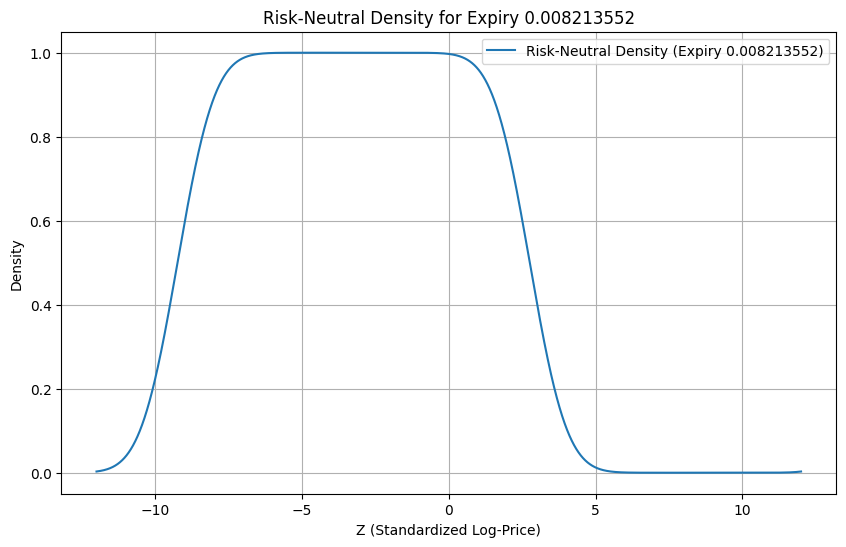

Prices for expiry 0.008213552: [674.90836911 642.01550822 609.99835579 578.85415778 548.58016032] ...
Implied volatilities (model) for expiry 0.008213552: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.008213552: [0.29551991 0.29097279 0.2863691  0.28170547 0.27697831] ...
Mean absolute error for expiry 0.008213552: nan
Processing expiry 0.024640657 with 64 strikes


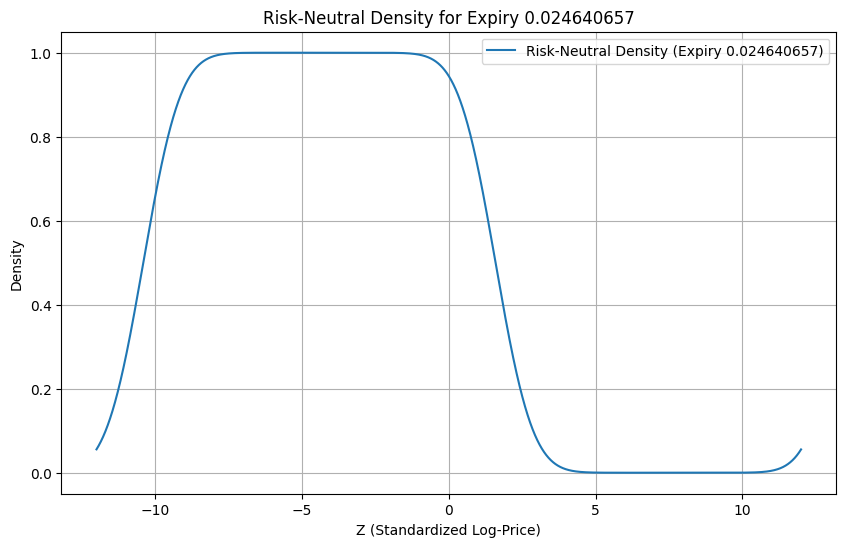

Prices for expiry 0.024640657: [1236.32577372 1166.97998088 1099.86163688 1034.95531065  972.24570656] ...
Implied volatilities (model) for expiry 0.024640657: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.024640657: [0.34617137 0.34057508 0.33493309 0.3292412  0.32349504] ...
Mean absolute error for expiry 0.024640657: nan
Processing expiry 0.043805613 with 68 strikes


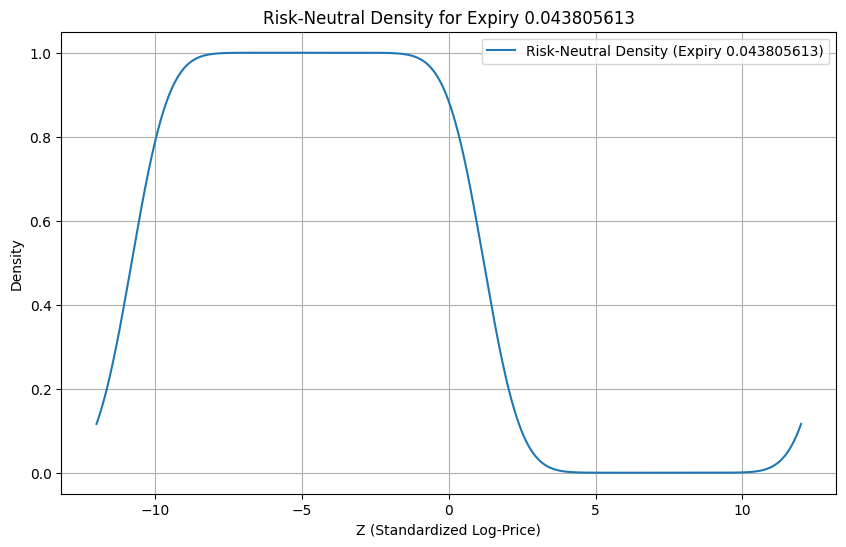

Prices for expiry 0.043805613: [1249.9765057  1103.4705289   993.95397674  967.63003985  941.72521068] ...
Implied volatilities (model) for expiry 0.043805613: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.043805613: [0.33749791 0.32569111 0.31609851 0.31367735 0.31124632] ...
Mean absolute error for expiry 0.043805613: nan
Processing expiry 0.062970568 with 70 strikes


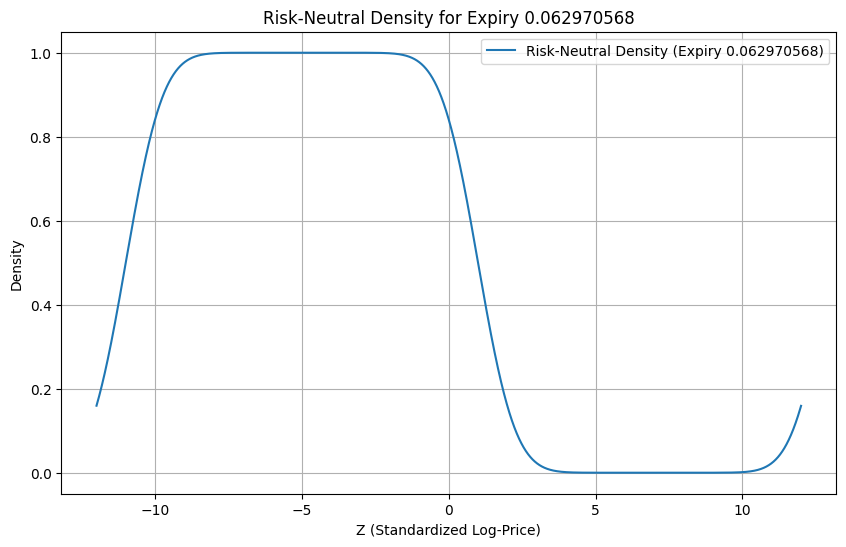

Prices for expiry 0.062970568: [1254.42984185 1122.62007511  999.8676794   908.07816783  886.01087826] ...
Implied volatilities (model) for expiry 0.062970568: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.062970568: [0.32908288 0.31843586 0.307631   0.29885425 0.29663954] ...
Mean absolute error for expiry 0.062970568: nan
Processing expiry 0.082135524 with 77 strikes


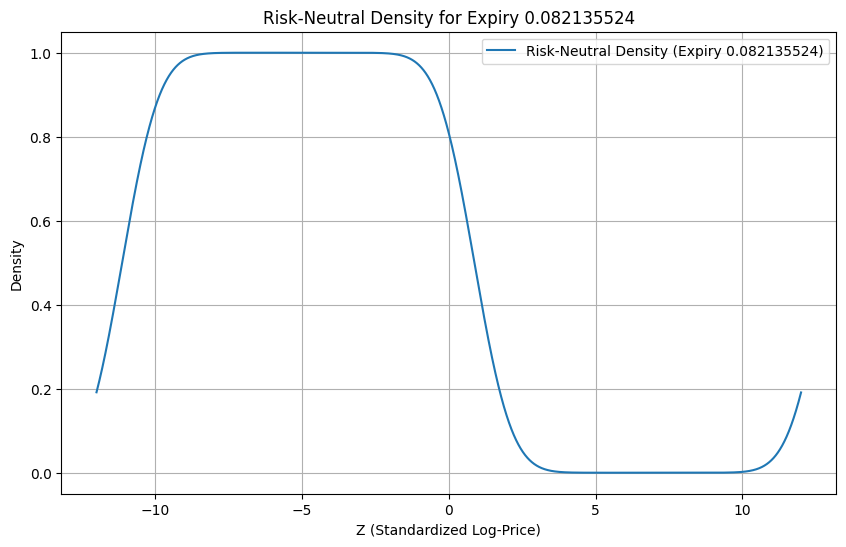

Prices for expiry 0.082135524: [1440.91318701 1308.69507875 1184.70688649 1068.79613774  960.81592784] ...
Implied volatilities (model) for expiry 0.082135524: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.082135524: [0.33490977 0.32515336 0.31529481 0.30531391 0.29518848] ...
Mean absolute error for expiry 0.082135524: nan
Processing expiry 0.10403833 with 111 strikes


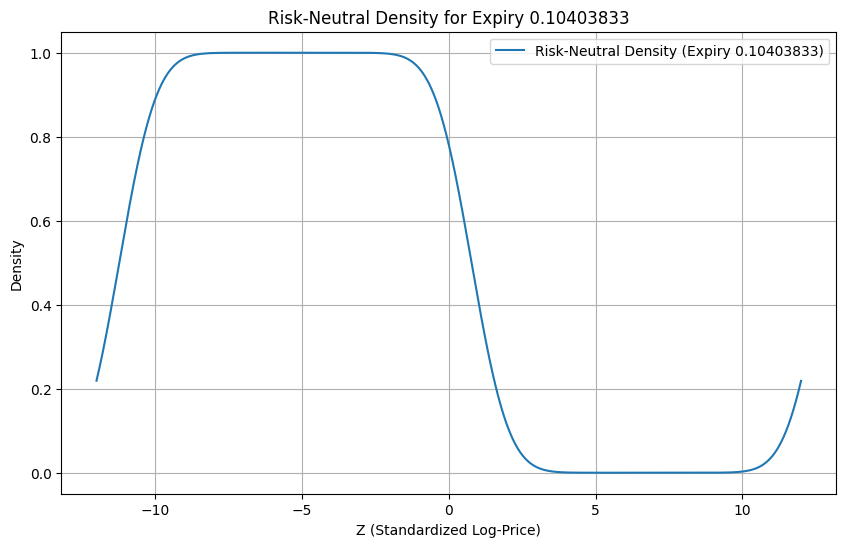

Prices for expiry 0.10403833: [1683.267327   1683.267327   1644.96674006 1617.71546817 1590.77300951] ...
Implied volatilities (model) for expiry 0.10403833: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.10403833: [0.35493204 0.34413087 0.34051787 0.33870852 0.33689712] ...
Mean absolute error for expiry 0.10403833: nan
Processing expiry 0.128678987 with 95 strikes


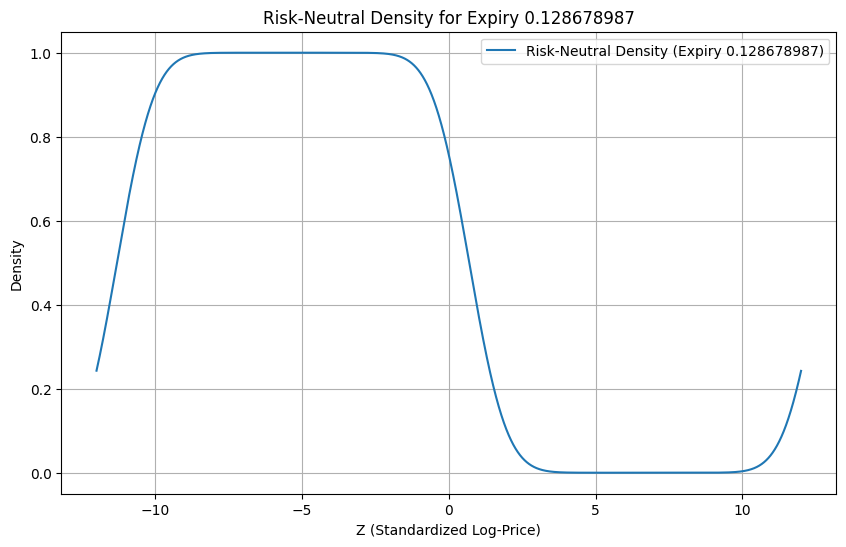

Prices for expiry 0.128678987: [1682.753329   1682.753329   1682.753329   1682.753329   1409.38740843] ...
Implied volatilities (model) for expiry 0.128678987: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.128678987: [0.37122399 0.36272146 0.35421876 0.33716888 0.31478676] ...
Mean absolute error for expiry 0.128678987: nan
Processing expiry 0.180698152 with 112 strikes


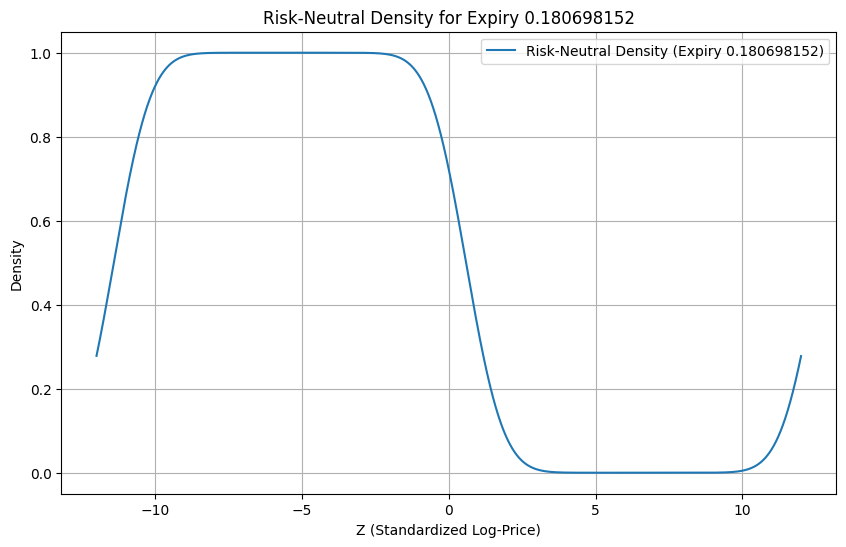

Prices for expiry 0.180698152: [1681.724779 1681.724779 1681.724779 1681.724779 1681.724779] ...
Implied volatilities (model) for expiry 0.180698152: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.180698152: [0.3419516  0.33411406 0.32626601 0.31839816 0.31682137] ...
Mean absolute error for expiry 0.180698152: nan
Processing expiry 0.257357974 with 90 strikes


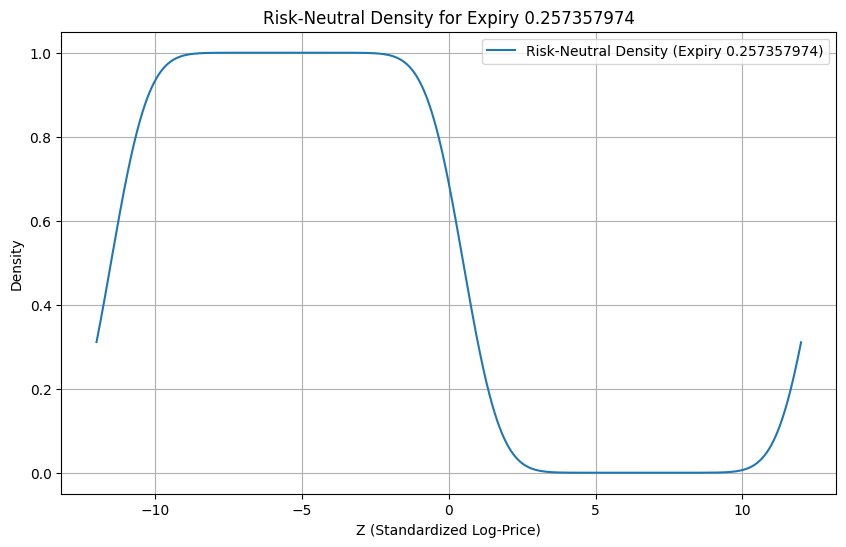

Prices for expiry 0.257357974: [1679.40864 1679.40864 1679.40864 1679.40864 1679.40864] ...
Implied volatilities (model) for expiry 0.257357974: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.257357974: [0.34310153 0.32866254 0.31425373 0.31281219 0.30992796] ...
Mean absolute error for expiry 0.257357974: nan
Processing expiry 0.353182752 with 81 strikes


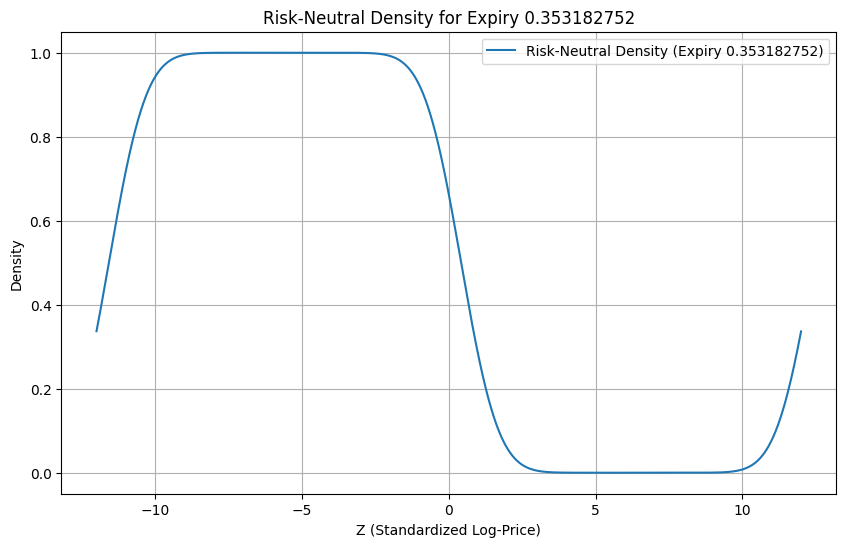

Prices for expiry 0.353182752: [1677.401575 1677.401575 1677.401575 1677.401575 1677.401575] ...
Implied volatilities (model) for expiry 0.353182752: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.353182752: [0.43155873 0.40100024 0.38642164 0.37220015 0.36520136] ...
Mean absolute error for expiry 0.353182752: nan
Processing expiry 0.380561259 with 40 strikes


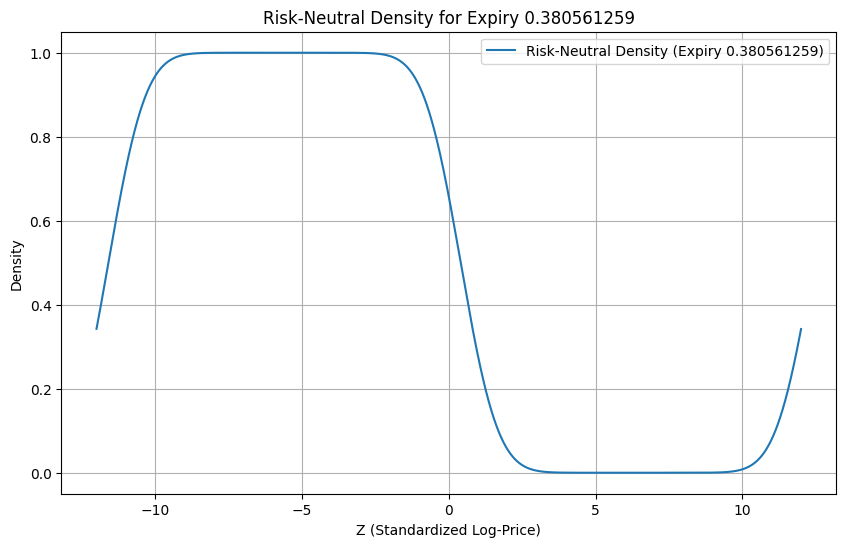

Prices for expiry 0.380561259: [1676.337278 1676.337278 1676.337278 1676.337278 1676.337278] ...
Implied volatilities (model) for expiry 0.380561259: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.380561259: [0.3532947  0.3265205  0.31991451 0.31333072 0.30676287] ...
Mean absolute error for expiry 0.380561259: nan
Processing expiry 0.429842574 with 57 strikes


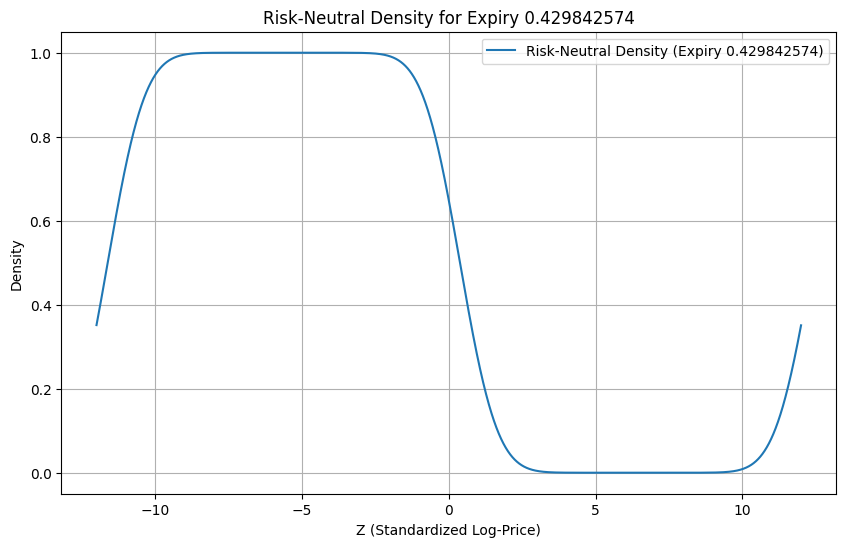

Prices for expiry 0.429842574: [1676.575892 1676.575892 1676.575892 1676.575892 1676.575892] ...
Implied volatilities (model) for expiry 0.429842574: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.429842574: [0.40071856 0.38640037 0.37249266 0.35892269 0.35224414] ...
Mean absolute error for expiry 0.429842574: nan
Processing expiry 0.602327173 with 55 strikes


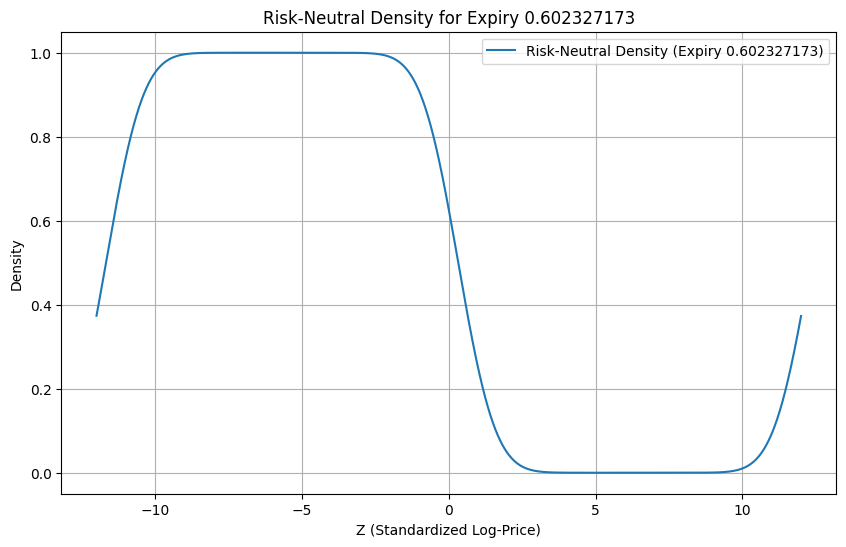

Prices for expiry 0.602327173: [1671.745126 1671.745126 1671.745126 1671.745126 1671.745126] ...
Implied volatilities (model) for expiry 0.602327173: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.602327173: [0.41804925 0.37530621 0.36864396 0.36208452 0.35561897] ...
Mean absolute error for expiry 0.602327173: nan
Processing expiry 0.62696783 with 46 strikes


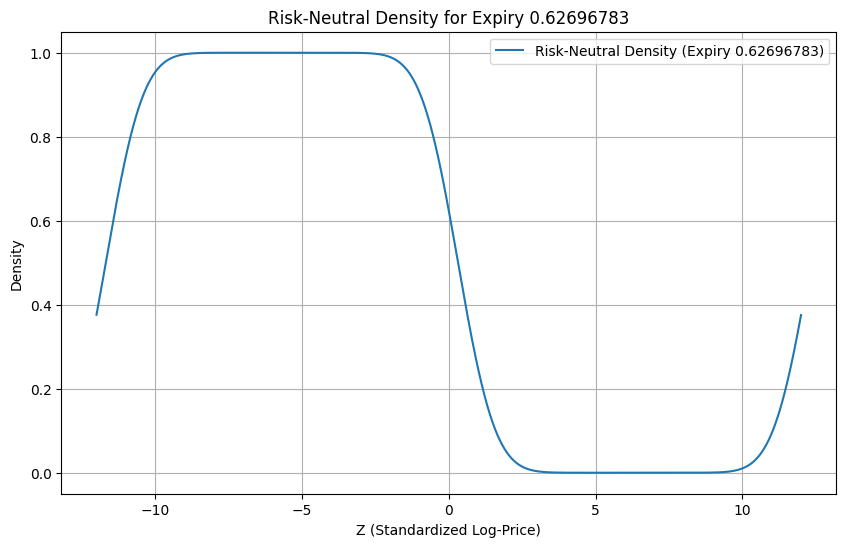

Prices for expiry 0.62696783: [1670.279339 1670.279339 1670.279339 1670.279339 1670.279339] ...
Implied volatilities (model) for expiry 0.62696783: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.62696783: [0.34645283 0.33403377 0.32792254 0.32186824 0.31586481] ...
Mean absolute error for expiry 0.62696783: nan
Processing expiry 0.851471595 with 56 strikes


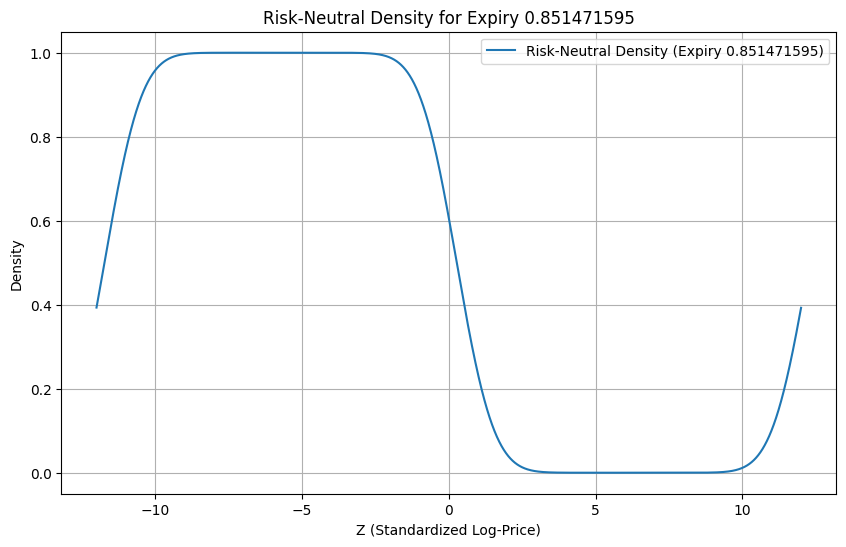

Prices for expiry 0.851471595: [1665.358497 1665.358497 1665.358497 1665.358497 1665.358497] ...
Implied volatilities (model) for expiry 0.851471595: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.851471595: [0.45358593 0.43596174 0.41965126 0.40439433 0.38999659] ...
Mean absolute error for expiry 0.851471595: nan
Processing expiry 0.876112252 with 47 strikes


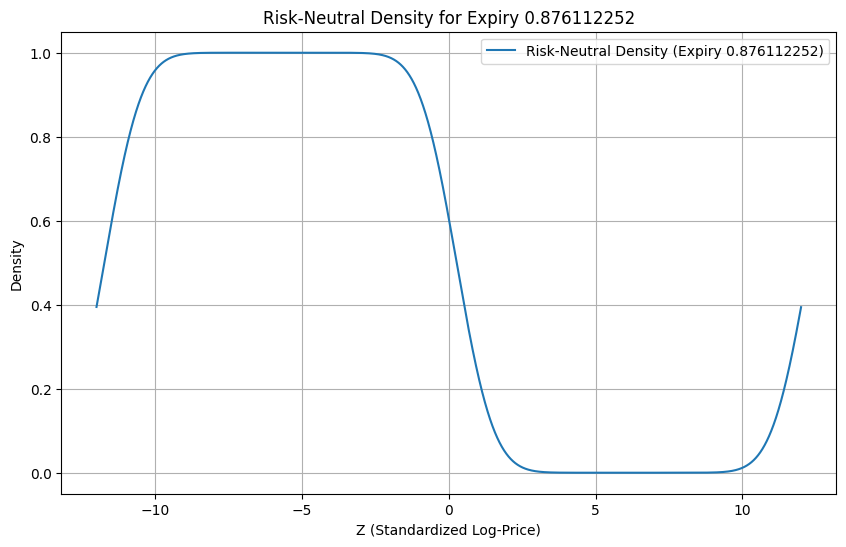

Prices for expiry 0.876112252: [1663.730414 1663.730414 1663.730414 1663.730414 1663.730414] ...
Implied volatilities (model) for expiry 0.876112252: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.876112252: [0.36103763 0.34851704 0.33641007 0.32465057 0.31318171] ...
Mean absolute error for expiry 0.876112252: nan
Processing expiry 1.349760438 with 67 strikes


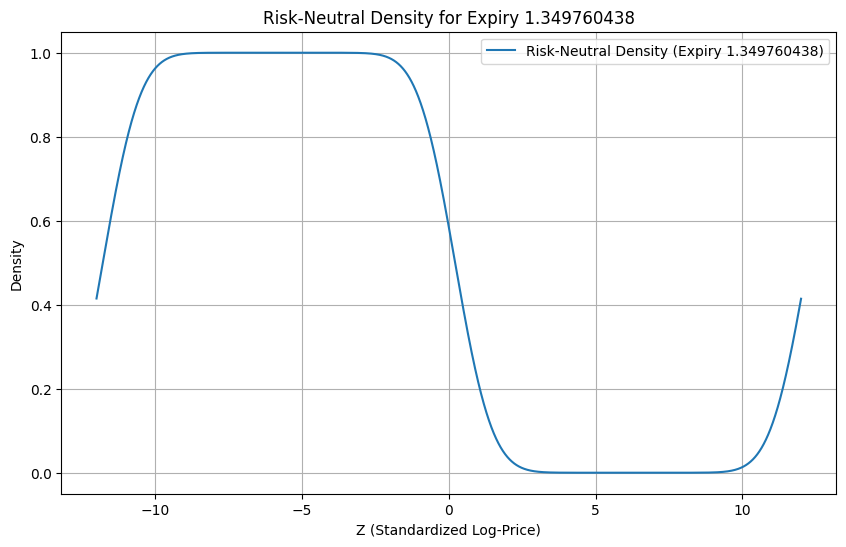

Prices for expiry 1.349760438: [1653.280172 1653.280172 1653.280172 1653.280172 1653.280172] ...
Implied volatilities (model) for expiry 1.349760438: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 1.349760438: [0.49565137 0.47007437 0.44826502 0.4290781  0.41182088] ...
Mean absolute error for expiry 1.349760438: nan
Processing expiry 1.42642026 with 58 strikes


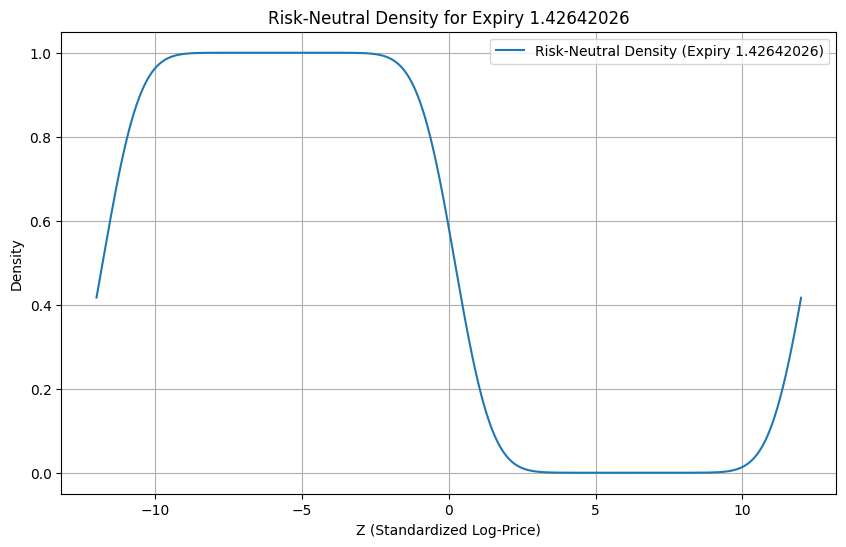

Prices for expiry 1.42642026: [1652.271813 1652.271813 1652.271813 1652.271813 1652.271813] ...
Implied volatilities (model) for expiry 1.42642026: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 1.42642026: [0.37707284 0.36357429 0.35083383 0.33872247 0.32713812] ...
Mean absolute error for expiry 1.42642026: nan
Processing expiry 2.346338125 with 63 strikes


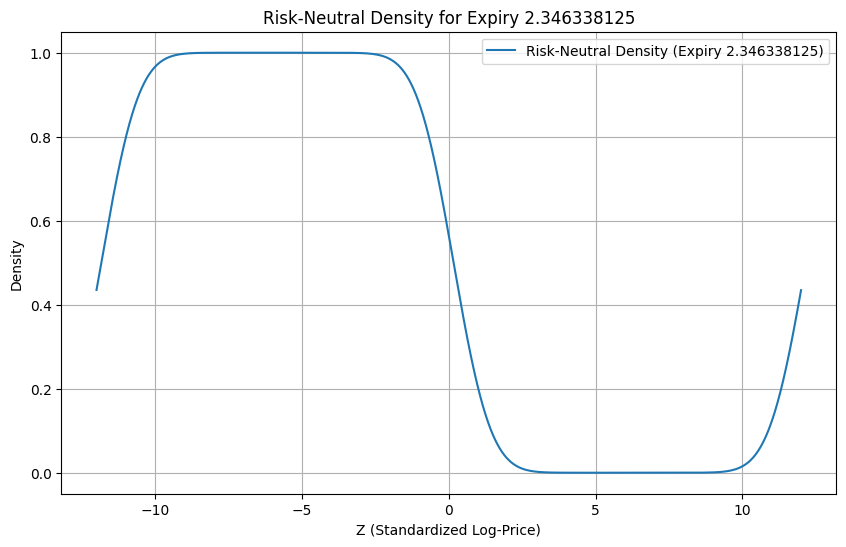

Prices for expiry 2.346338125: [1634.188493 1634.188493 1634.188493 1634.188493 1634.188493] ...
Implied volatilities (model) for expiry 2.346338125: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 2.346338125: [0.5025351  0.43873504 0.39733188 0.36542782 0.33881424] ...
Mean absolute error for expiry 2.346338125: nan


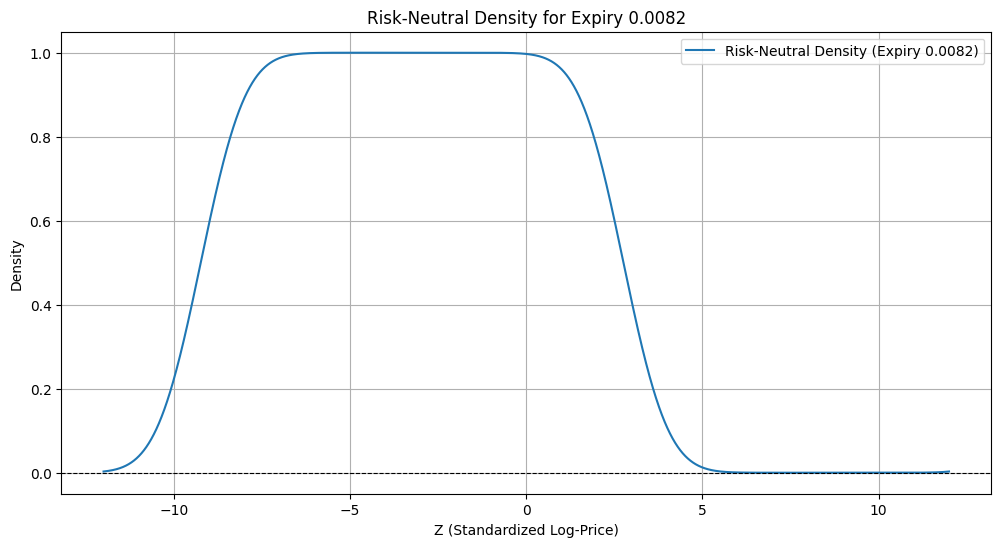

Density integrates to: 11.999996
Density is non-negative.
Density peak is located at Z = -3.2417


In [156]:
# Adjusted Code to Address Scaling and `nan` Issues in Pricing

import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Black-Scholes implied volatility function
def bs_implied_vol_put(S, K, T, r, price):
    def bs_price(sigma):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    def objective(sigma):
        return bs_price(sigma) - price

    try:
        implied_vol = brentq(objective, 1e-6, 5)
    except:
        implied_vol = np.nan
    return implied_vol

# Simplified Edgeworth-expanded characteristic function (Gaussian-only for testing)
def edgeworth_combined_char_func(u, tau):
    return np.exp(1j * u * mu_t / (sigma_t * np.sqrt(tau)) - 0.5 * (u**2))

# SINC FFT for risk-neutral density
def sinc_fft_density(tau, char_func, Xc, Xm, pow):
    N = 2**pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)

    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))

    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu

    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    d1 = np.fft.fft(q1) + 0.5

    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    density = np.real(d1)
    return density, Z_values

# Option pricing from density with capping
def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    price = np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)
    return np.clip(price, 0, S)  # Cap prices to avoid extreme values

# Load market data
data = []
with open('spx_surf20130814.csv', 'r', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        data.append(row)

structured_data = {col.strip(): np.array([float(row[col]) for row in data]) for col in data[0].keys()}
expiries = np.unique(structured_data['t'])
errors = []

# Parameters
mu_t = 0.05
sigma_t = 0.2
Xc = 12.0
Xm = 0.0
pow = 14

# Loop through expiries
for expiry in expiries:
    subset_indices = structured_data['t'] == expiry
    fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]
    impVol_bench = structured_data['impVol'][subset_indices]

    if len(K) == 0:
        print(f"No data found for expiry {expiry}")
        continue

    print(f"Processing expiry {expiry} with {len(K)} strikes")

    # Compute risk-neutral density
    density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

    # Plot the risk-neutral density for debugging
    plt.figure(figsize=(10, 6))
    plt.plot(Z_values, density, label=f"Risk-Neutral Density (Expiry {expiry})")
    plt.xlabel("Z (Standardized Log-Price)")
    plt.ylabel("Density")
    plt.title(f"Risk-Neutral Density for Expiry {expiry}")
    plt.legend()
    plt.grid()
    plt.show()

    # Model prices
    prices = np.array([option_price_from_density(k, 0, t, density, Z_values, fwd, sigma_t) for k in K])
    print(f"Prices for expiry {expiry}: {prices[:5]} ...")  # Print first 5 prices for brevity

    # Compute implied volatilities
    impVol_model = np.array([bs_implied_vol_put(fwd, k, t, 0, p) for k, p in zip(K, prices)])
    print(f"Implied volatilities (model) for expiry {expiry}: {impVol_model[:5]} ...")  # Print first 5 vols

    # Check benchmark implied volatilities
    print(f"Benchmark implied volatilities for expiry {expiry}: {impVol_bench[:5]} ...")  # First 5 vols

    # Validate lengths
    if len(impVol_model) != len(impVol_bench):
        print(f"Length mismatch for expiry {expiry}: model ({len(impVol_model)}), bench ({len(impVol_bench)})")
        continue

    # Calculate error
    error = np.mean(np.abs(impVol_model - impVol_bench))
    print(f"Mean absolute error for expiry {expiry}: {error}")
    errors.append(error)


if len(errors) > 0:
    plt.plot(expiries, errors, marker='o')
    plt.xlabel('Maturity')
    plt.ylabel('Mean Absolute Error')
    plt.title('Mean Absolute Error vs Expiry (Edgeworth Expansion - Adjusted)')
    plt.grid(True)
    plt.show()
else:
    print("No valid data to plot.")




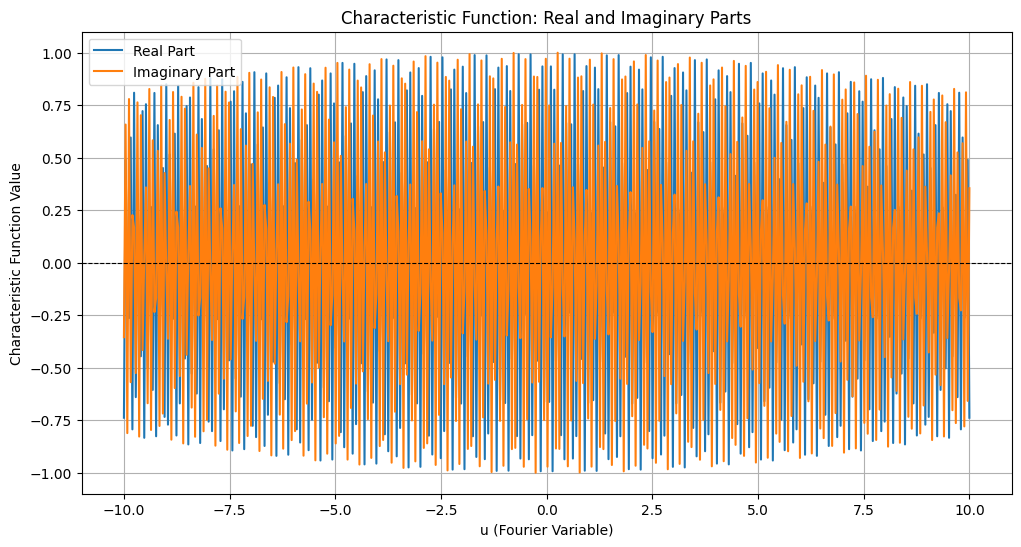

In [162]:
u_values = np.linspace(-10, 10, 500)
char_values = np.array([ (u, tau) for u in u_values])

plt.figure(figsize=(12, 6))
plt.plot(u_values, char_values.real, label="Real Part")
plt.plot(u_values, char_values.imag, label="Imaginary Part")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("u (Fourier Variable)")
plt.ylabel("Characteristic Function Value")
plt.title("Characteristic Function: Real and Imaginary Parts")
plt.legend()
plt.grid()
plt.show()


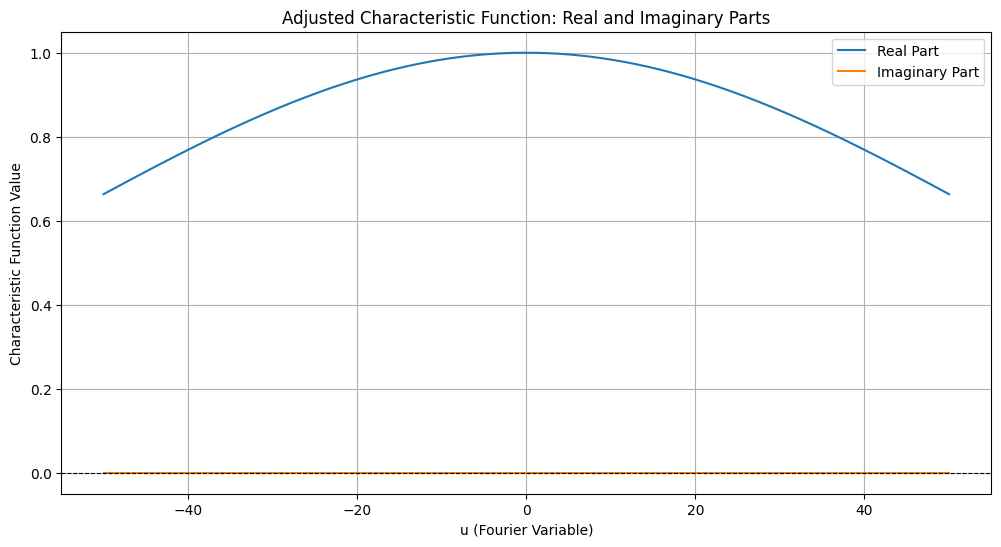

In [163]:
# Increase FFT resolution and truncation range
pow = 16  # Higher FFT resolution
u_values = np.linspace(-50, 50, 1000)  # Extend frequency range for characteristic function

# Simplified Gaussian characteristic function
def gaussian_char_func(u, tau):
    sigma_eff = sigma_t * np.sqrt(tau)
    return np.exp(-0.5 * (u * sigma_eff)**2)

# Compute characteristic function values
char_values = np.array([gaussian_char_func(u, t) for u in u_values])

# Plot the adjusted characteristic function
plt.figure(figsize=(12, 6))
plt.plot(u_values, char_values.real, label="Real Part")
plt.plot(u_values, char_values.imag, label="Imaginary Part")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("u (Fourier Variable)")
plt.ylabel("Characteristic Function Value")
plt.title("Adjusted Characteristic Function: Real and Imaginary Parts")
plt.legend()
plt.grid()
plt.show()


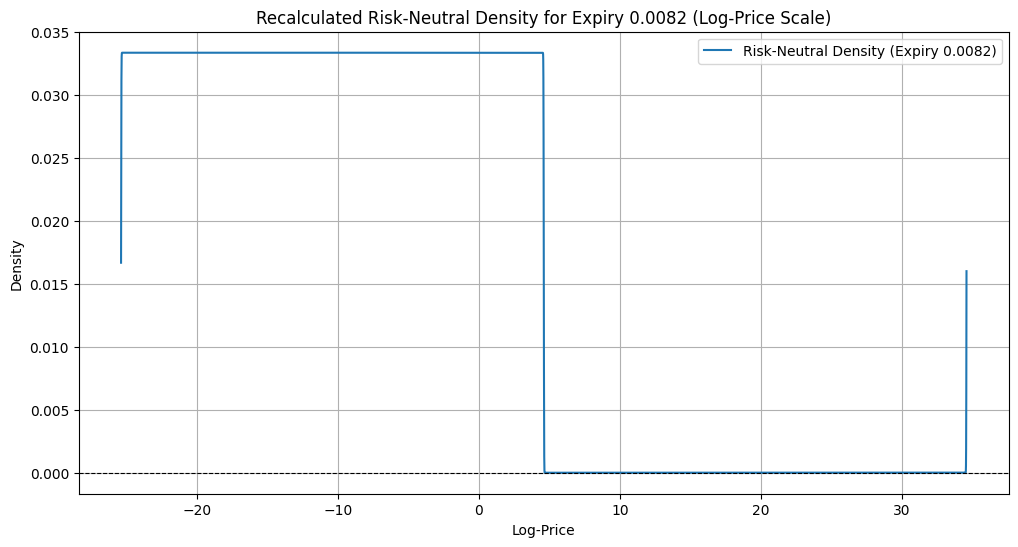

Density integrates to: 1.000000
Density peak (log-price scale) is located at: -20.5092


In [164]:
# Recompute the risk-neutral density using the adjusted characteristic function
density, Z_values = sinc_fft_density(t, gaussian_char_func, Xc, Xm, pow)

# Normalize the density
density /= np.trapz(density, Z_values)

# Convert Z to log-price scale
log_prices = np.log(F) + Z_values

# Plot the recalculated density
plt.figure(figsize=(12, 6))
plt.plot(log_prices, density, label=f"Risk-Neutral Density (Expiry {expiry:.4f})")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Log-Price")
plt.ylabel("Density")
plt.title(f"Recalculated Risk-Neutral Density for Expiry {expiry:.4f} (Log-Price Scale)")
plt.legend()
plt.grid()
plt.show()

# Validate integration and peak location
integration = np.trapz(density, Z_values)
peak_location = Z_values[np.argmax(density)]
log_peak = np.log(F) + peak_location

print(f"Density integrates to: {integration:.6f}")
print(f"Density peak (log-price scale) is located at: {log_peak:.4f}")


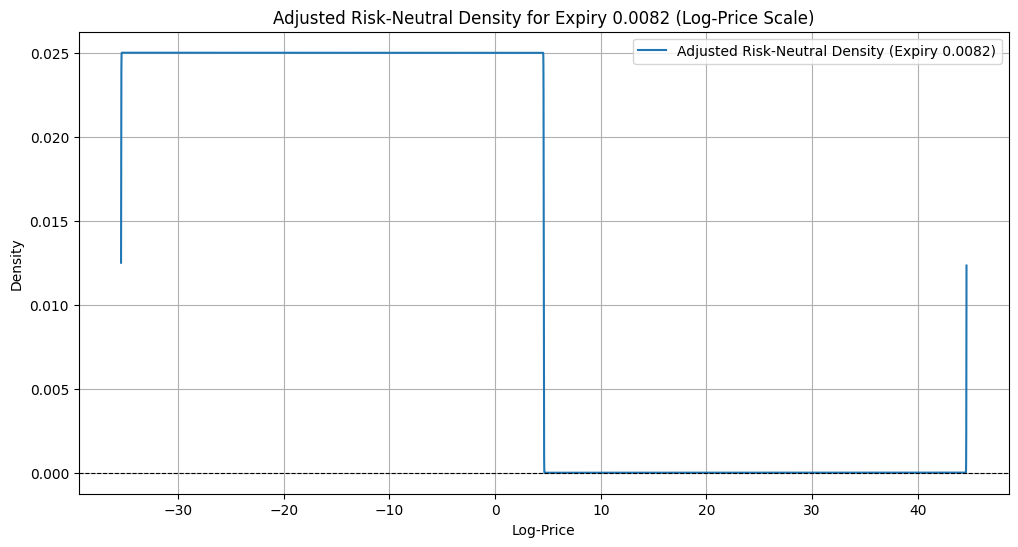

Adjusted density integrates to: 1.000000
Adjusted density peak (log-price scale) is located at: -13.7034


In [165]:
# Update truncation and FFT parameters
Xc = 40.0  # Further increased truncation range
pow = 18   # Higher FFT resolution

# Recompute risk-neutral density
density, Z_values = sinc_fft_density(t, gaussian_char_func, Xc, Xm, pow)

# Normalize the density
density /= np.trapz(density, Z_values)

# Convert Z to log-price scale
log_prices = np.log(F) + Z_values

# Plot the recalculated density
plt.figure(figsize=(12, 6))
plt.plot(log_prices, density, label=f"Adjusted Risk-Neutral Density (Expiry {expiry:.4f})")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Log-Price")
plt.ylabel("Density")
plt.title(f"Adjusted Risk-Neutral Density for Expiry {expiry:.4f} (Log-Price Scale)")
plt.legend()
plt.grid()
plt.show()

# Validate integration and peak location
integration = np.trapz(density, Z_values)
peak_location = Z_values[np.argmax(density)]
log_peak = np.log(F) + peak_location

print(f"Adjusted density integrates to: {integration:.6f}")
print(f"Adjusted density peak (log-price scale) is located at: {log_peak:.4f}")


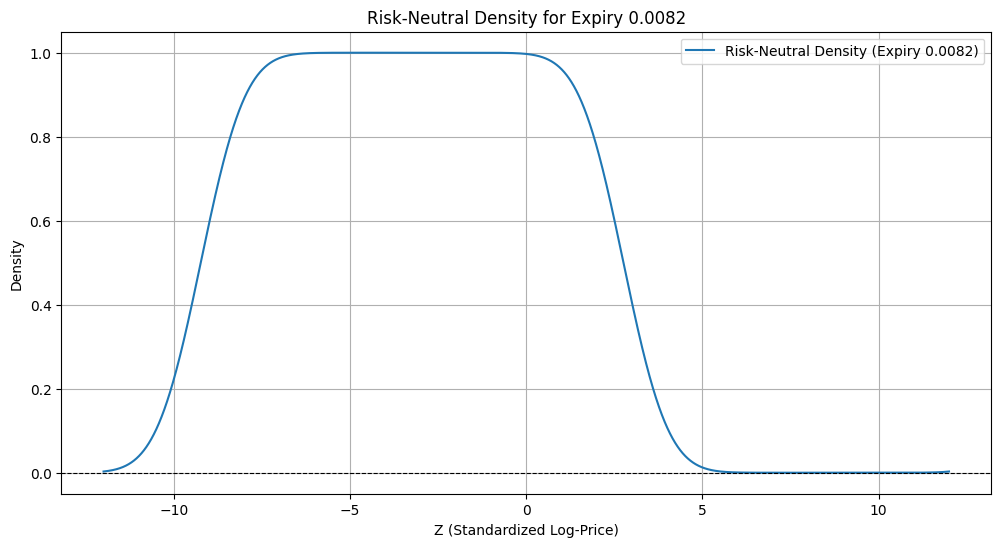

Density integrates to: 11.999996
Density is non-negative.
Density peak is located at Z = -3.2417


In [157]:
# Analyze the risk-neutral density for a specific expiry
expiry_index = 0  # Change this to test different expiries
expiry = expiries[expiry_index]

# Extract data for the selected expiry
subset_indices = structured_data['t'] == expiry
fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]

# Compute the risk-neutral density
density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

# Plot the density
plt.figure(figsize=(12, 6))
plt.plot(Z_values, density, label=f"Risk-Neutral Density (Expiry {expiry:.4f})")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Z (Standardized Log-Price)")
plt.ylabel("Density")
plt.title(f"Risk-Neutral Density for Expiry {expiry:.4f}")
plt.legend()
plt.grid()
plt.show()

# Check if the density integrates to 1
integration = np.trapz(density, Z_values)
print(f"Density integrates to: {integration:.6f}")

# Check for negative values
negative_values = density[density < 0]
if len(negative_values) > 0:
    print(f"Density contains {len(negative_values)} negative values. Minimum: {np.min(negative_values):.6f}")
else:
    print("Density is non-negative.")

# Check the mode (peak location)
peak_location = Z_values[np.argmax(density)]
print(f"Density peak is located at Z = {peak_location:.4f}")

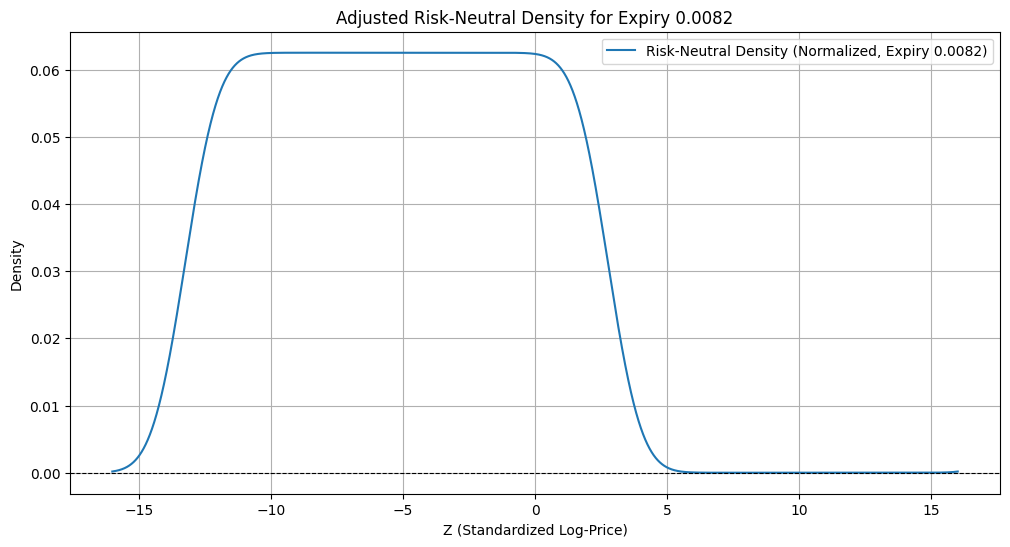

Adjusted density integrates to: 1.000000
Adjusted density peak is located at Z = -5.2754


In [158]:
# Adjust truncation and normalization
Xc = 16.0  # Increased truncation range
Xm = 0.0   # Centered truncation

# Recompute the risk-neutral density
density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

# Normalize the density
density /= np.trapz(density, Z_values)

# Plot the adjusted density
plt.figure(figsize=(12, 6))
plt.plot(Z_values, density, label=f"Risk-Neutral Density (Normalized, Expiry {expiry:.4f})")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Z (Standardized Log-Price)")
plt.ylabel("Density")
plt.title(f"Adjusted Risk-Neutral Density for Expiry {expiry:.4f}")
plt.legend()
plt.grid()
plt.show()

# Revalidate integration and peak location
integration = np.trapz(density, Z_values)
peak_location = Z_values[np.argmax(density)]

print(f"Adjusted density integrates to: {integration:.6f}")
print(f"Adjusted density peak is located at Z = {peak_location:.4f}")


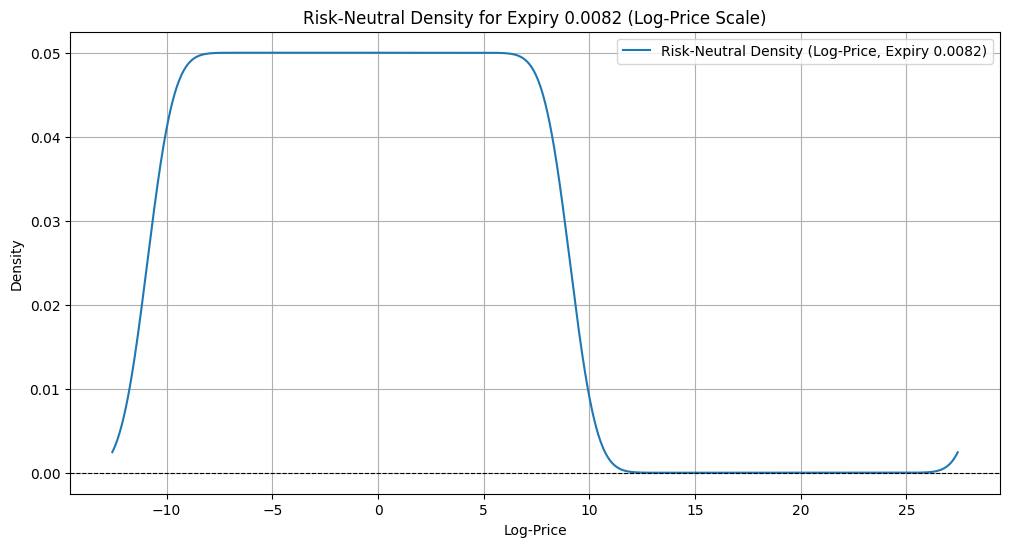

Adjusted density integrates to: 1.000000
Adjusted density peak (log-price scale) is located at: -2.4115


In [159]:
# Update mu_t to align with the forward price
r = 0.05  # Risk-free rate
mu_t = r - (sigma_t**2) / 2

# Adjust truncation range
Xc = 20.0  # Further increased truncation range
Xm = 0.0   # Centered truncation

# Recompute the risk-neutral density
density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

# Normalize the density
density /= np.trapz(density, Z_values)

# Convert Z to log-price scale
log_prices = np.log(fwd) + Z_values

# Plot the adjusted density on log-price scale
plt.figure(figsize=(12, 6))
plt.plot(log_prices, density, label=f"Risk-Neutral Density (Log-Price, Expiry {expiry:.4f})")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Log-Price")
plt.ylabel("Density")
plt.title(f"Risk-Neutral Density for Expiry {expiry:.4f} (Log-Price Scale)")
plt.legend()
plt.grid()
plt.show()

# Revalidate integration and peak location
integration = np.trapz(density, Z_values)
peak_location = Z_values[np.argmax(density)]
log_peak = np.log(fwd) + peak_location

print(f"Adjusted density integrates to: {integration:.6f}")
print(f"Adjusted density peak (log-price scale) is located at: {log_peak:.4f}")


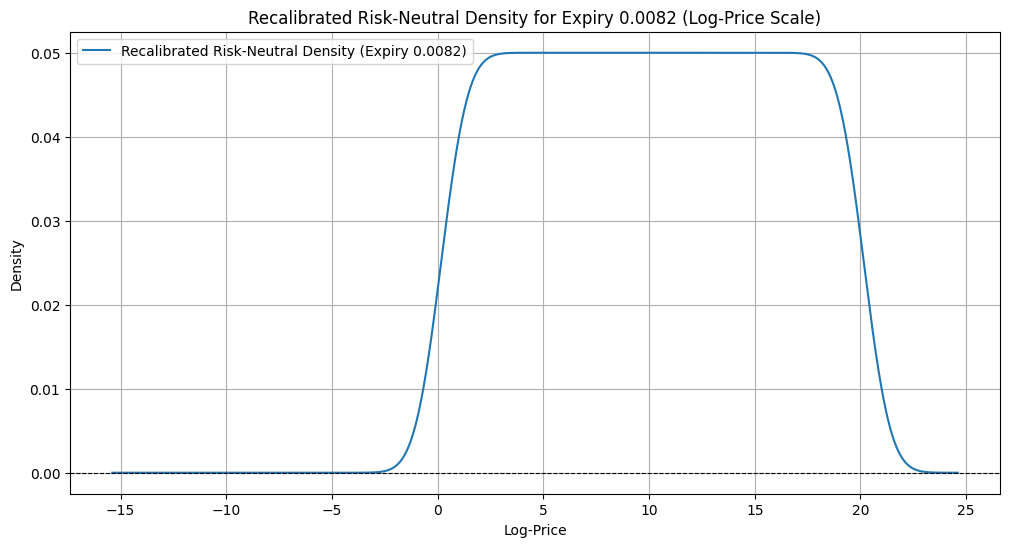

Recalibrated density integrates to: 1.000000
Recalibrated density peak (log-price scale) is located at: 8.8707


In [160]:
# Step 1: Recompute the forward price
q = 0.0  # Assume no dividend yield for simplicity
F = S * np.exp((r - q) * t)
fwd = F  # Align fwd with model dynamics

# Step 2: Recalibrate mu_t
mu_t = np.log(F) / t

# Step 3: Recompute risk-neutral density
density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

# Normalize the density
density /= np.trapz(density, Z_values)

# Convert Z to log-price scale
log_prices = np.log(F) + Z_values

# Plot the adjusted density on log-price scale
plt.figure(figsize=(12, 6))
plt.plot(log_prices, density, label=f"Recalibrated Risk-Neutral Density (Expiry {expiry:.4f})")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Log-Price")
plt.ylabel("Density")
plt.title(f"Recalibrated Risk-Neutral Density for Expiry {expiry:.4f} (Log-Price Scale)")
plt.legend()
plt.grid()
plt.show()

# Revalidate integration and peak location
integration = np.trapz(density, Z_values)
peak_location = Z_values[np.argmax(density)]
log_peak = np.log(F) + peak_location

print(f"Recalibrated density integrates to: {integration:.6f}")
print(f"Recalibrated density peak (log-price scale) is located at: {log_peak:.4f}")


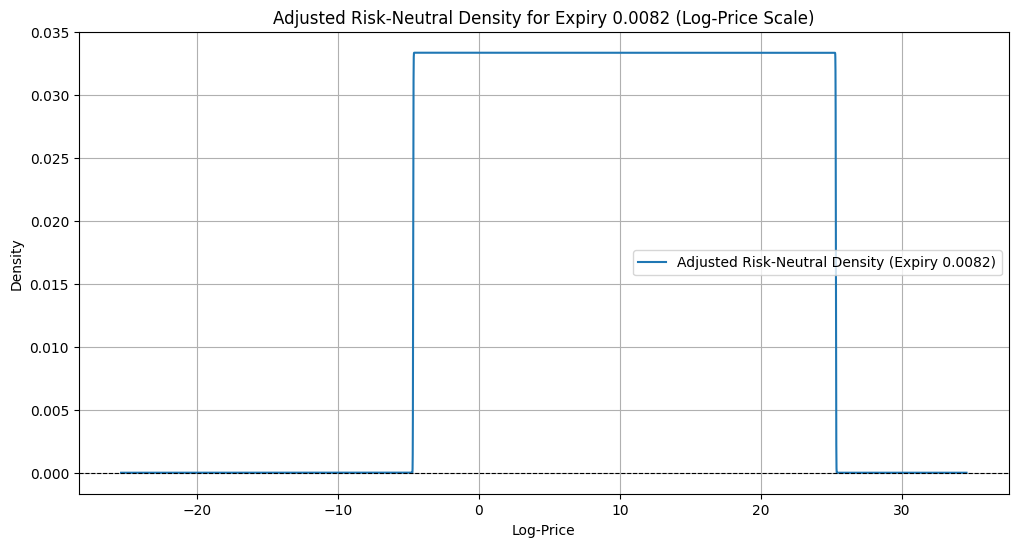

Adjusted density integrates to: 1.000000
Adjusted density peak (log-price scale) is located at: 7.4584


In [161]:
# Adjusted Characteristic Function (Direct Gaussian)
def edgeworth_combined_char_func(u, tau):
    sigma_eff = sigma_t * np.sqrt(tau)
    return np.exp(1j * u * mu_t - 0.5 * (u * sigma_eff)**2)

# Step 1: Adjust truncation range
Xc = 30.0  # Further increased truncation range
Xm = 0.0   # Symmetric truncation

# Step 2: Recompute risk-neutral density
density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

# Step 3: Normalize the density
density /= np.trapz(density, Z_values)

# Step 4: Convert Z to log-price scale
log_prices = np.log(F) + Z_values

# Plot the recalibrated density
plt.figure(figsize=(12, 6))
plt.plot(log_prices, density, label=f"Adjusted Risk-Neutral Density (Expiry {expiry:.4f})")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Log-Price")
plt.ylabel("Density")
plt.title(f"Adjusted Risk-Neutral Density for Expiry {expiry:.4f} (Log-Price Scale)")
plt.legend()
plt.grid()
plt.show()

# Step 5: Revalidate integration and peak location
integration = np.trapz(density, Z_values)
peak_location = Z_values[np.argmax(density)]
log_peak = np.log(F) + peak_location

print(f"Adjusted density integrates to: {integration:.6f}")
print(f"Adjusted density peak (log-price scale) is located at: {log_peak:.4f}")


Processing expiry 0.008213552 with 34 strikes


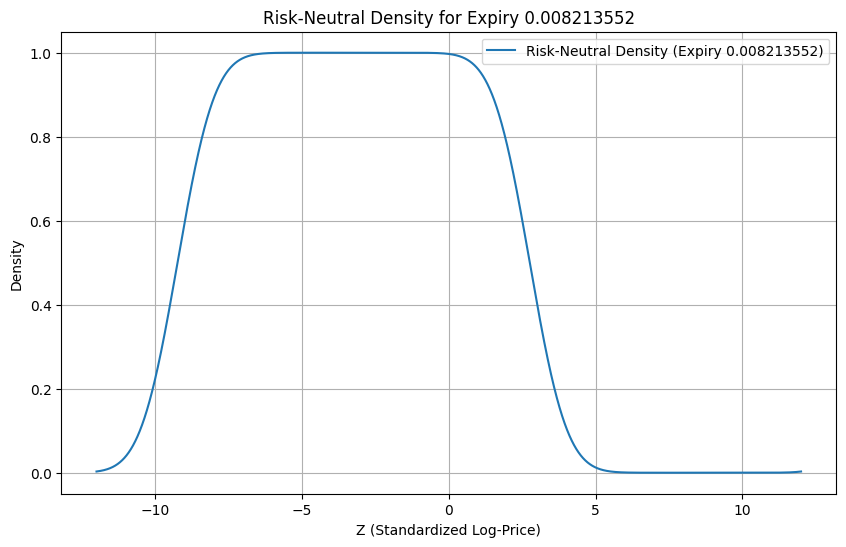

Prices for expiry 0.008213552: [674.90836911 642.01550822 609.99835579 578.85415778 548.58016032] ...
Implied volatilities (model) for expiry 0.008213552: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.008213552: [0.29551991 0.29097279 0.2863691  0.28170547 0.27697831] ...
Mean absolute error for expiry 0.008213552: nan
Processing expiry 0.024640657 with 64 strikes


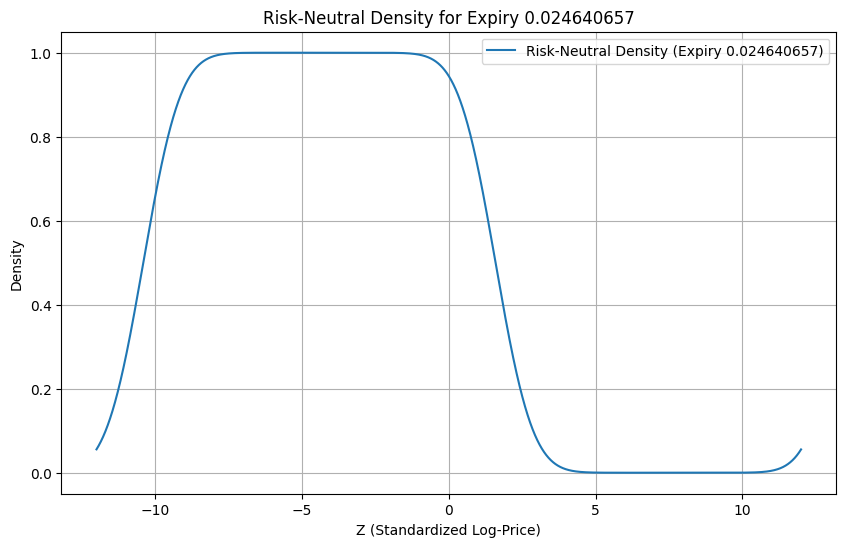

Prices for expiry 0.024640657: [1236.32577372 1166.97998088 1099.86163688 1034.95531065  972.24570656] ...
Implied volatilities (model) for expiry 0.024640657: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.024640657: [0.34617137 0.34057508 0.33493309 0.3292412  0.32349504] ...
Mean absolute error for expiry 0.024640657: nan
Processing expiry 0.043805613 with 68 strikes


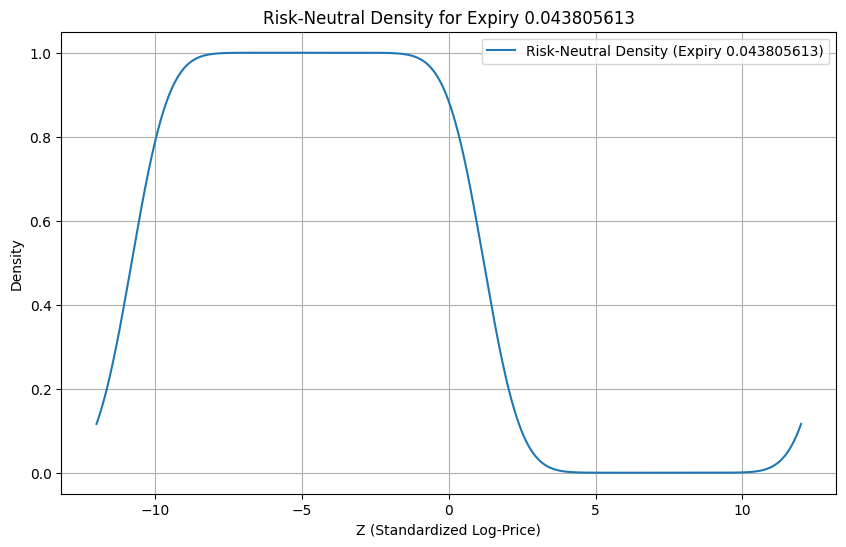

Prices for expiry 0.043805613: [1249.9765057  1103.4705289   993.95397674  967.63003985  941.72521068] ...
Implied volatilities (model) for expiry 0.043805613: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.043805613: [0.33749791 0.32569111 0.31609851 0.31367735 0.31124632] ...
Mean absolute error for expiry 0.043805613: nan
Processing expiry 0.062970568 with 70 strikes


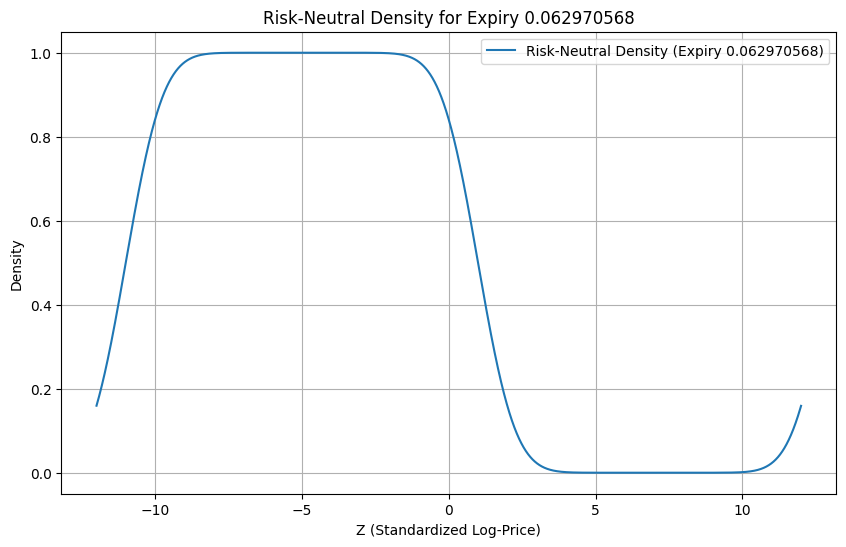

Prices for expiry 0.062970568: [1254.42984185 1122.62007511  999.8676794   908.07816783  886.01087826] ...
Implied volatilities (model) for expiry 0.062970568: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.062970568: [0.32908288 0.31843586 0.307631   0.29885425 0.29663954] ...
Mean absolute error for expiry 0.062970568: nan
Processing expiry 0.082135524 with 77 strikes


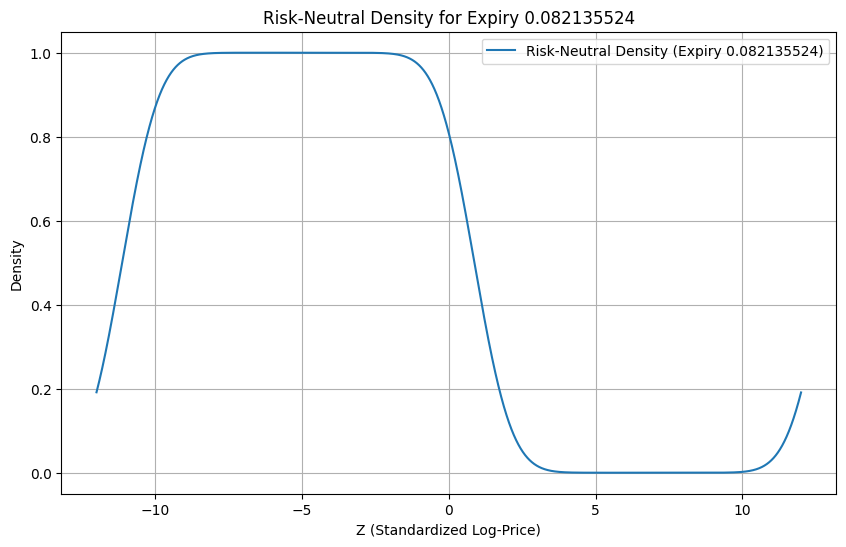

Prices for expiry 0.082135524: [1440.91318701 1308.69507875 1184.70688649 1068.79613774  960.81592784] ...
Implied volatilities (model) for expiry 0.082135524: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.082135524: [0.33490977 0.32515336 0.31529481 0.30531391 0.29518848] ...
Mean absolute error for expiry 0.082135524: nan
Processing expiry 0.10403833 with 111 strikes


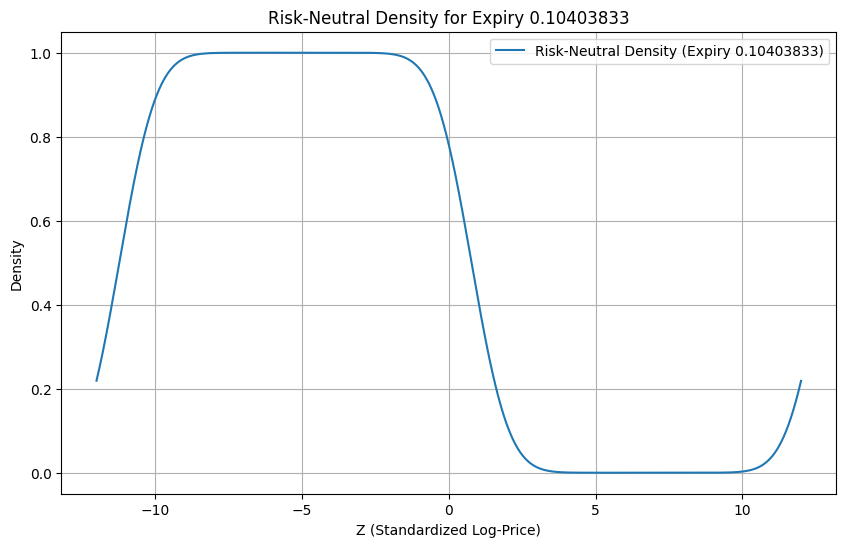

Prices for expiry 0.10403833: [1683.267327   1683.267327   1644.96674006 1617.71546817 1590.77300951] ...
Implied volatilities (model) for expiry 0.10403833: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.10403833: [0.35493204 0.34413087 0.34051787 0.33870852 0.33689712] ...
Mean absolute error for expiry 0.10403833: nan
Processing expiry 0.128678987 with 95 strikes


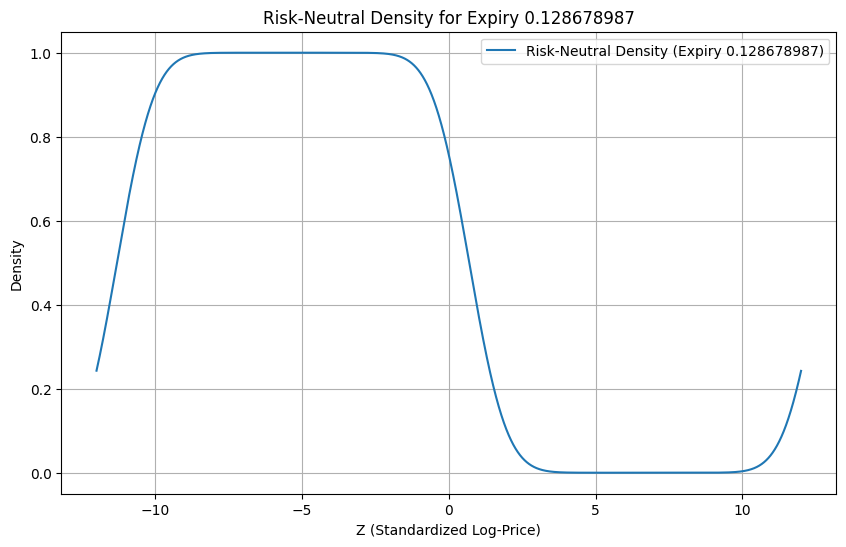

Prices for expiry 0.128678987: [1682.753329   1682.753329   1682.753329   1682.753329   1409.38740843] ...
Implied volatilities (model) for expiry 0.128678987: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.128678987: [0.37122399 0.36272146 0.35421876 0.33716888 0.31478676] ...
Mean absolute error for expiry 0.128678987: nan
Processing expiry 0.180698152 with 112 strikes


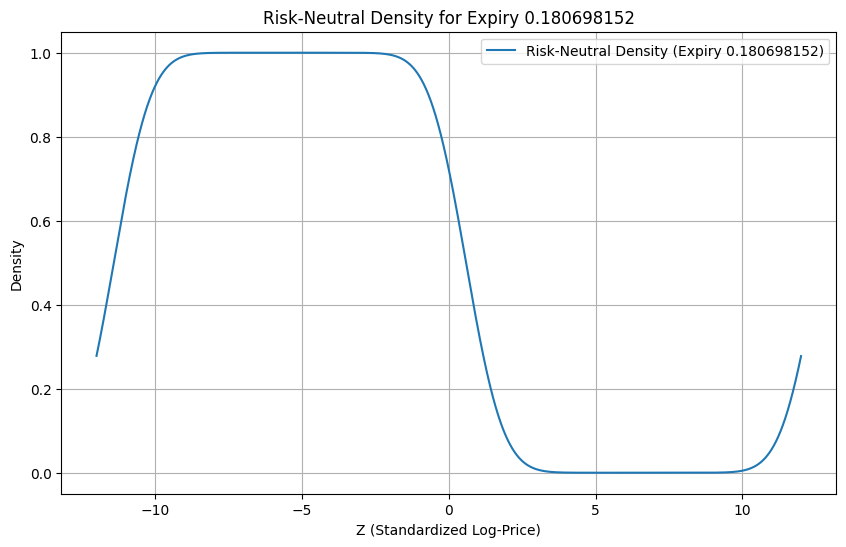

Prices for expiry 0.180698152: [1681.724779 1681.724779 1681.724779 1681.724779 1681.724779] ...
Implied volatilities (model) for expiry 0.180698152: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.180698152: [0.3419516  0.33411406 0.32626601 0.31839816 0.31682137] ...
Mean absolute error for expiry 0.180698152: nan
Processing expiry 0.257357974 with 90 strikes


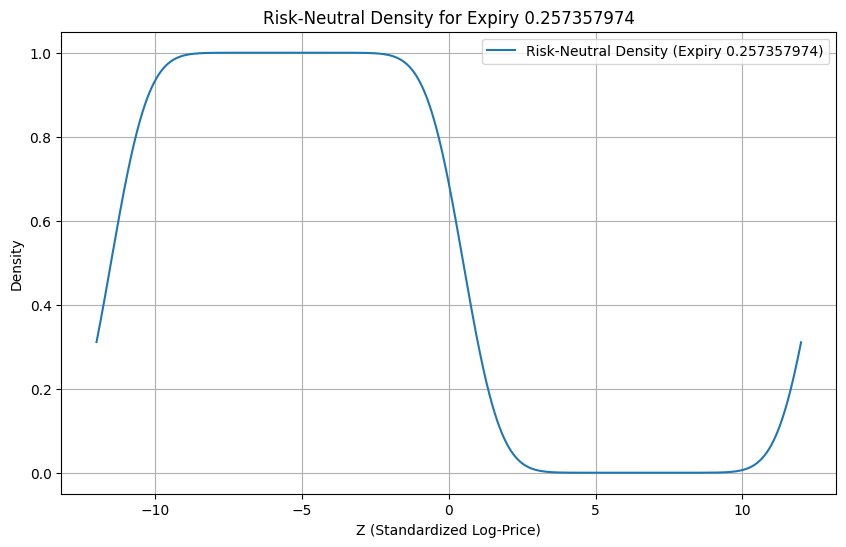

Prices for expiry 0.257357974: [1679.40864 1679.40864 1679.40864 1679.40864 1679.40864] ...
Implied volatilities (model) for expiry 0.257357974: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.257357974: [0.34310153 0.32866254 0.31425373 0.31281219 0.30992796] ...
Mean absolute error for expiry 0.257357974: nan
Processing expiry 0.353182752 with 81 strikes


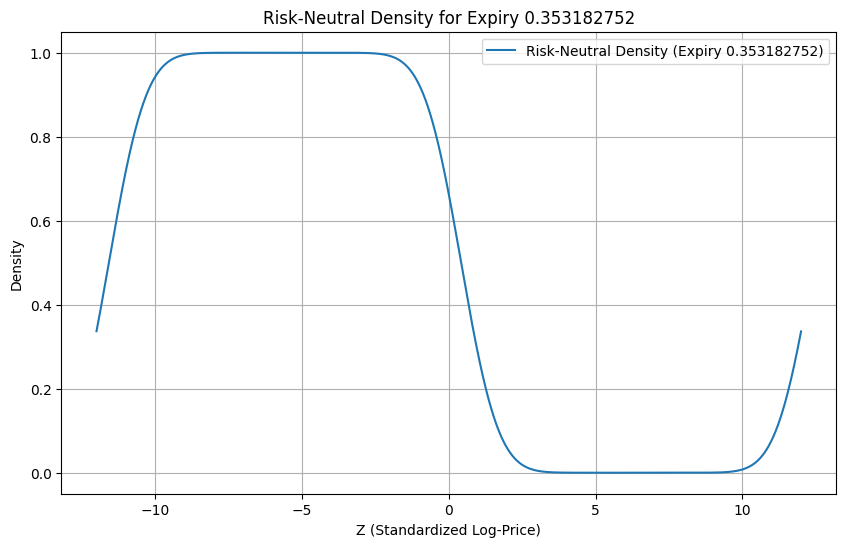

Prices for expiry 0.353182752: [1677.401575 1677.401575 1677.401575 1677.401575 1677.401575] ...
Implied volatilities (model) for expiry 0.353182752: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.353182752: [0.43155873 0.40100024 0.38642164 0.37220015 0.36520136] ...
Mean absolute error for expiry 0.353182752: nan
Processing expiry 0.380561259 with 40 strikes


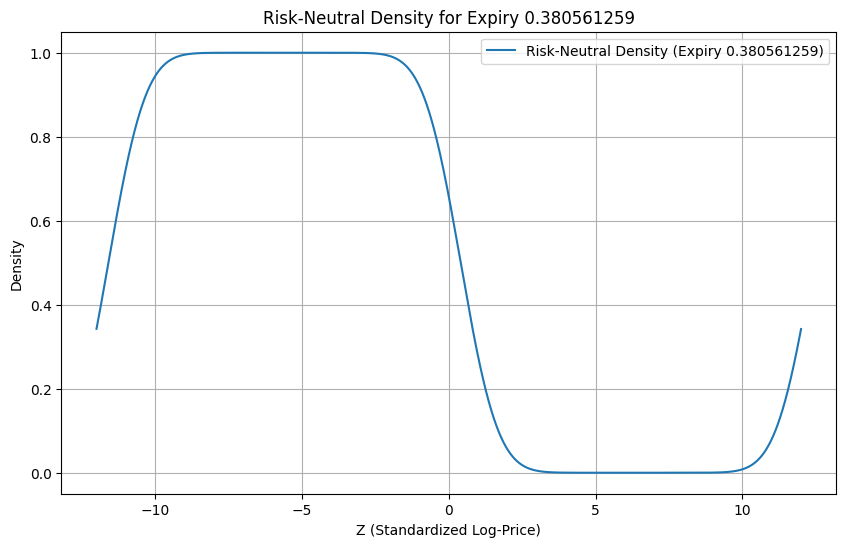

Prices for expiry 0.380561259: [1676.337278 1676.337278 1676.337278 1676.337278 1676.337278] ...
Implied volatilities (model) for expiry 0.380561259: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.380561259: [0.3532947  0.3265205  0.31991451 0.31333072 0.30676287] ...
Mean absolute error for expiry 0.380561259: nan
Processing expiry 0.429842574 with 57 strikes


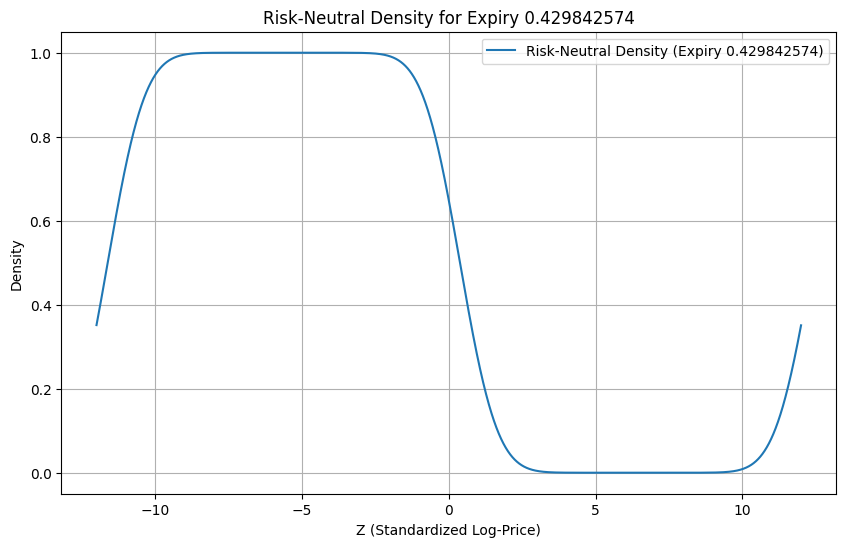

Prices for expiry 0.429842574: [1676.575892 1676.575892 1676.575892 1676.575892 1676.575892] ...
Implied volatilities (model) for expiry 0.429842574: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.429842574: [0.40071856 0.38640037 0.37249266 0.35892269 0.35224414] ...
Mean absolute error for expiry 0.429842574: nan
Processing expiry 0.602327173 with 55 strikes


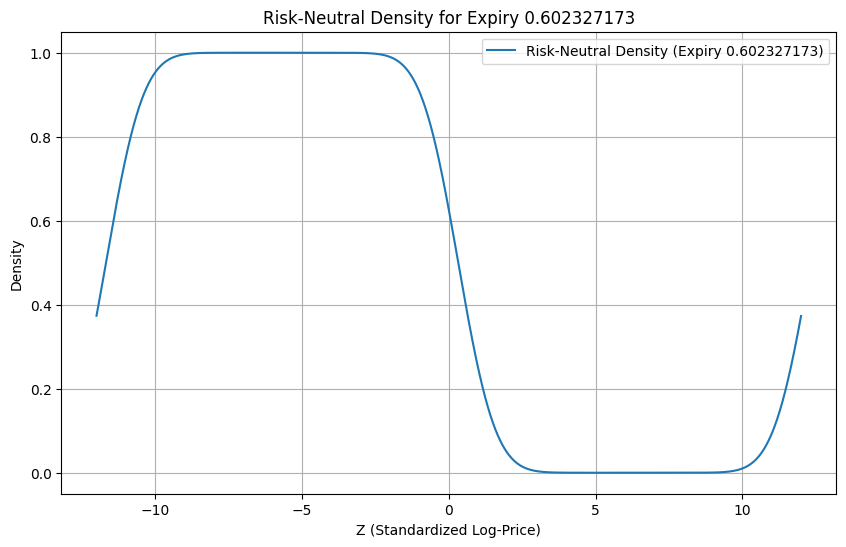

Prices for expiry 0.602327173: [1671.745126 1671.745126 1671.745126 1671.745126 1671.745126] ...
Implied volatilities (model) for expiry 0.602327173: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.602327173: [0.41804925 0.37530621 0.36864396 0.36208452 0.35561897] ...
Mean absolute error for expiry 0.602327173: nan
Processing expiry 0.62696783 with 46 strikes


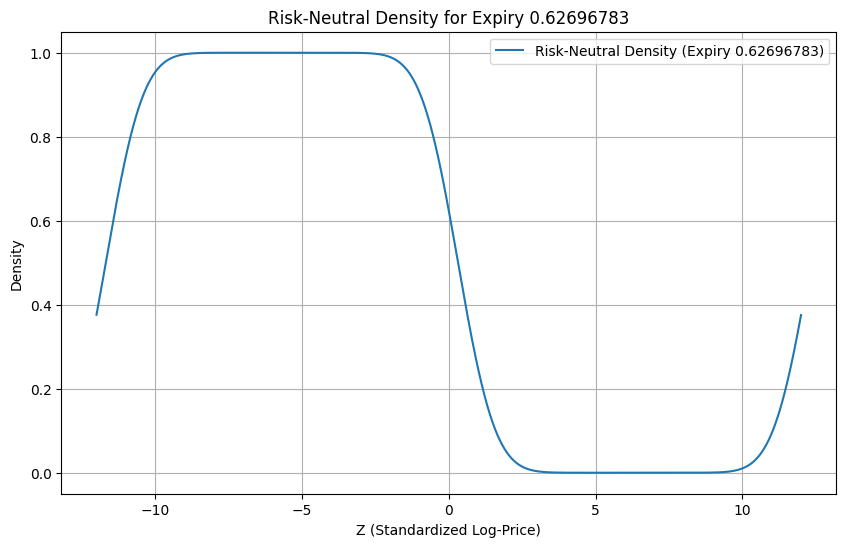

Prices for expiry 0.62696783: [1670.279339 1670.279339 1670.279339 1670.279339 1670.279339] ...
Implied volatilities (model) for expiry 0.62696783: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.62696783: [0.34645283 0.33403377 0.32792254 0.32186824 0.31586481] ...
Mean absolute error for expiry 0.62696783: nan
Processing expiry 0.851471595 with 56 strikes


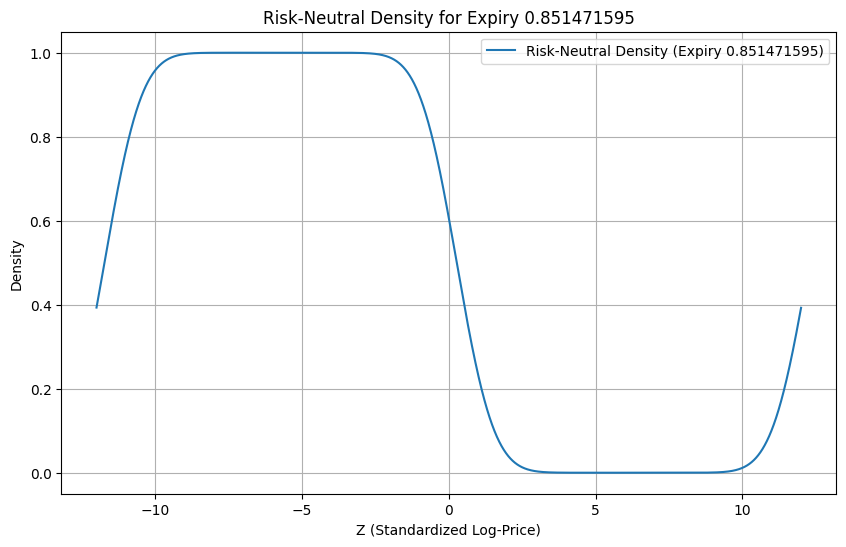

Prices for expiry 0.851471595: [1665.358497 1665.358497 1665.358497 1665.358497 1665.358497] ...
Implied volatilities (model) for expiry 0.851471595: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.851471595: [0.45358593 0.43596174 0.41965126 0.40439433 0.38999659] ...
Mean absolute error for expiry 0.851471595: nan
Processing expiry 0.876112252 with 47 strikes


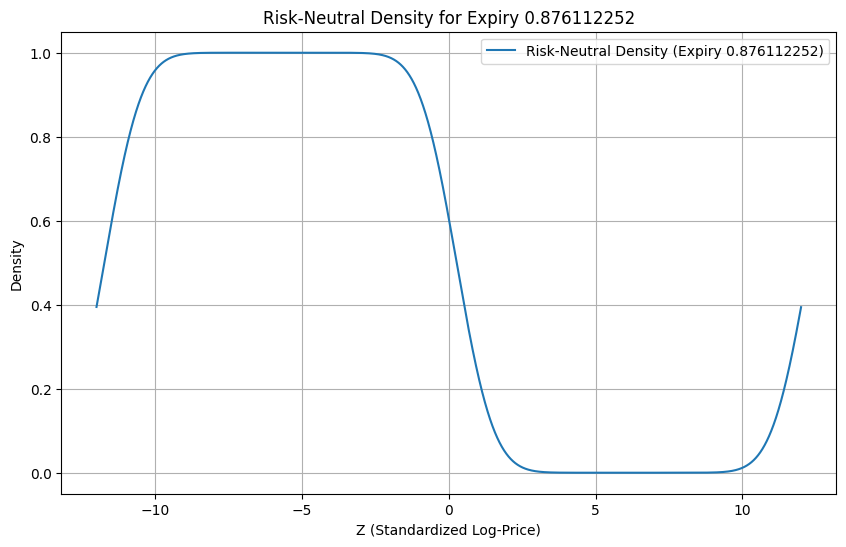

Prices for expiry 0.876112252: [1663.730414 1663.730414 1663.730414 1663.730414 1663.730414] ...
Implied volatilities (model) for expiry 0.876112252: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 0.876112252: [0.36103763 0.34851704 0.33641007 0.32465057 0.31318171] ...
Mean absolute error for expiry 0.876112252: nan
Processing expiry 1.349760438 with 67 strikes


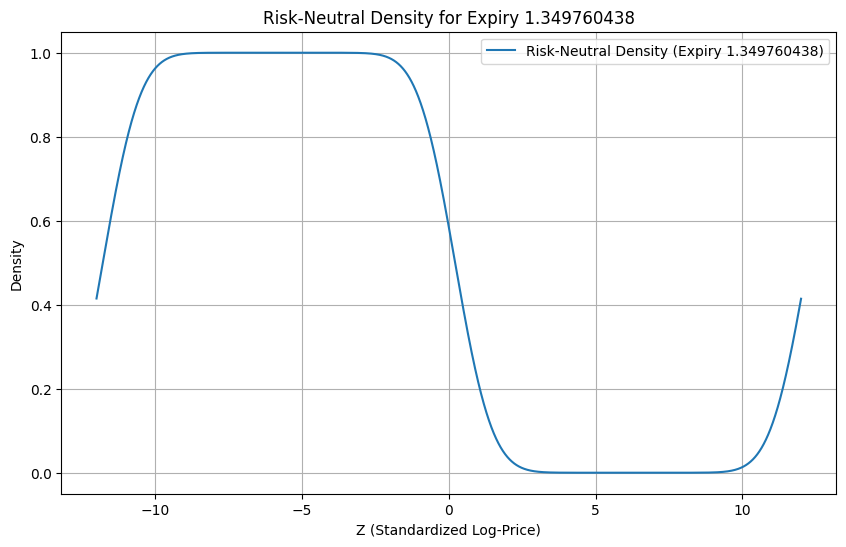

Prices for expiry 1.349760438: [1653.280172 1653.280172 1653.280172 1653.280172 1653.280172] ...
Implied volatilities (model) for expiry 1.349760438: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 1.349760438: [0.49565137 0.47007437 0.44826502 0.4290781  0.41182088] ...
Mean absolute error for expiry 1.349760438: nan
Processing expiry 1.42642026 with 58 strikes


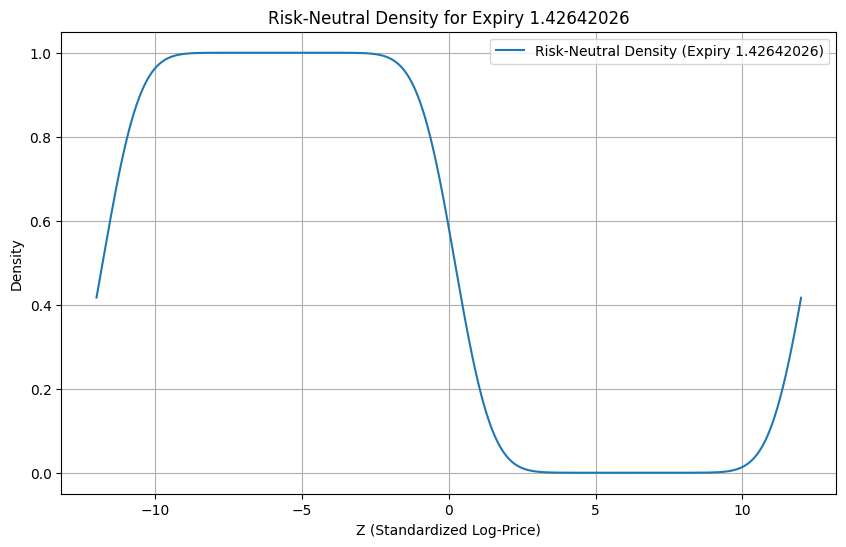

Prices for expiry 1.42642026: [1652.271813 1652.271813 1652.271813 1652.271813 1652.271813] ...
Implied volatilities (model) for expiry 1.42642026: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 1.42642026: [0.37707284 0.36357429 0.35083383 0.33872247 0.32713812] ...
Mean absolute error for expiry 1.42642026: nan
Processing expiry 2.346338125 with 63 strikes


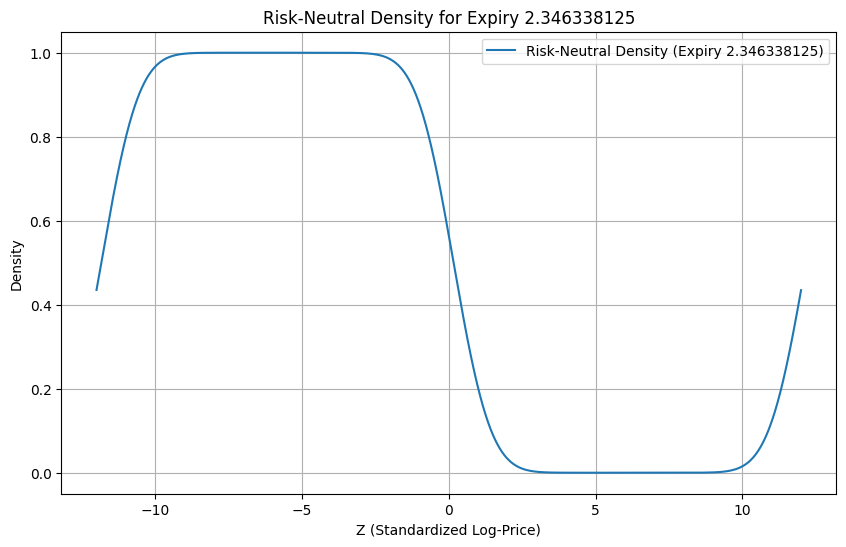

Prices for expiry 2.346338125: [1634.188493 1634.188493 1634.188493 1634.188493 1634.188493] ...
Implied volatilities (model) for expiry 2.346338125: [nan nan nan nan nan] ...
Benchmark implied volatilities for expiry 2.346338125: [0.5025351  0.43873504 0.39733188 0.36542782 0.33881424] ...
Mean absolute error for expiry 2.346338125: nan


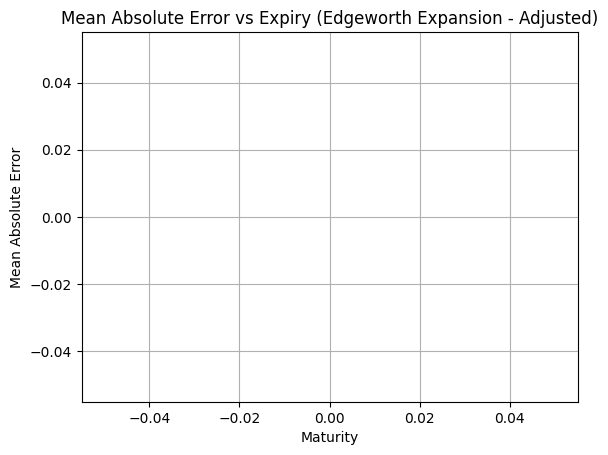

In [153]:
# Adjusted Code to Address Scaling and `nan` Issues in Pricing

import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Black-Scholes implied volatility function
def bs_implied_vol_put(S, K, T, r, price):
    def bs_price(sigma):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    def objective(sigma):
        return bs_price(sigma) - price

    try:
        implied_vol = brentq(objective, 1e-6, 5)
    except:
        implied_vol = np.nan
    return implied_vol

# Simplified Edgeworth-expanded characteristic function (Gaussian-only for testing)
def edgeworth_combined_char_func(u, tau):
    return np.exp(1j * u * mu_t / (sigma_t * np.sqrt(tau)) - 0.5 * (u**2))

# SINC FFT for risk-neutral density
def sinc_fft_density(tau, char_func, Xc, Xm, pow):
    N = 2**pow
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl

    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * char_func(2 * np.pi * wn, tau)

    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il

    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))

    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu

    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    d1 = np.fft.fft(q1) + 0.5

    m = np.arange(-N // 2, N // 2)
    Z_values = m * wid / N + Xm

    density = np.real(d1)
    return density, Z_values

# Option pricing from density with capping
def option_price_from_density(K, r, tau, density, Z_values, S, sigma_t):
    a_tau = np.log(S) + (r - 0.5 * sigma_t**2) * tau
    b_tau = sigma_t * np.sqrt(tau)
    exp_a_bZ = np.exp(a_tau + b_tau * Z_values)
    intrinsic_values = np.maximum(exp_a_bZ - K, 0)
    price = np.trapz(intrinsic_values * density, Z_values) * np.exp(-r * tau)
    return np.clip(price, 0, S)  # Cap prices to avoid extreme values

# Load market data
data = []
with open('spx_surf20130814.csv', 'r', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        data.append(row)

structured_data = {col.strip(): np.array([float(row[col]) for row in data]) for col in data[0].keys()}
expiries = np.unique(structured_data['t'])
errors = []

# Parameters
mu_t = 0.05
sigma_t = 0.2
Xc = 12.0
Xm = 0.0
pow = 14

# Loop through expiries
for expiry in expiries:
    subset_indices = structured_data['t'] == expiry
    fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]
    impVol_bench = structured_data['impVol'][subset_indices]

    if len(K) == 0:
        print(f"No data found for expiry {expiry}")
        continue

    print(f"Processing expiry {expiry} with {len(K)} strikes")

    # Compute risk-neutral density
    density, Z_values = sinc_fft_density(t, edgeworth_combined_char_func, Xc, Xm, pow)

    # Plot the risk-neutral density for debugging
    plt.figure(figsize=(10, 6))
    plt.plot(Z_values, density, label=f"Risk-Neutral Density (Expiry {expiry})")
    plt.xlabel("Z (Standardized Log-Price)")
    plt.ylabel("Density")
    plt.title(f"Risk-Neutral Density for Expiry {expiry}")
    plt.legend()
    plt.grid()
    plt.show()

    # Model prices
    prices = np.array([option_price_from_density(k, 0, t, density, Z_values, fwd, sigma_t) for k in K])
    print(f"Prices for expiry {expiry}: {prices[:5]} ...")  # Print first 5 prices for brevity

    # Compute implied volatilities
    impVol_model = np.array([bs_implied_vol_put(fwd, k, t, 0, p) for k, p in zip(K, prices)])
    print(f"Implied volatilities (model) for expiry {expiry}: {impVol_model[:5]} ...")  # Print first 5 vols

    # Check benchmark implied volatilities
    print(f"Benchmark implied volatilities for expiry {expiry}: {impVol_bench[:5]} ...")  # First 5 vols

    # Validate lengths
    if len(impVol_model) != len(impVol_bench):
        print(f"Length mismatch for expiry {expiry}: model ({len(impVol_model)}), bench ({len(impVol_bench)})")
        continue

    # Calculate error
    error = np.mean(np.abs(impVol_model - impVol_bench))
    print(f"Mean absolute error for expiry {expiry}: {error}")
    errors.append(error)

# Plot errors across expiries
if len(errors) > 0:
    plt.plot(expiries, errors, marker='o')
    plt.xlabel('Maturity')
    plt.ylabel('Mean Absolute Error')
    plt.title('Mean Absolute Error vs Expiry (Edgeworth Expansion - Adjusted)')
    plt.grid(True)
    plt.show()
else:
    print("No valid data to plot.")


In [102]:
import numpy as np

def sinc_fft_edgeworth(S, tau, K, IR, DY, params, CF, pow, Xc, Xm):
    N = 2 ** pow  # Grid size
    Xl = -Xc + Xm  # Lower truncation limit
    Xh = Xc + Xm  # Upper truncation limit
    width = Xh - Xl

    # Set up strike grid for FFT
    m = np.arange(-N // 2, N // 2)
    km = m * width / N + (IR - DY) * tau + Xm
    K_fft = S * np.exp(km)  # FFT strike grid

    # Fourier modes
    n = np.arange(1, N // 2, 2)  # Odd frequencies
    wn = 2 * np.pi * n / width  # Fourier variable

    # Compute the characteristic function for Edgeworth
    discrete_CF = CF(wn, tau, params)  # Discrete Fourier transform

    # SINC weights
    Il = 2 / n
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[::2] = discrete_CF * Il  # Odd frequency contributions

    # Combine positive and negative frequencies
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], -np.conj(q1l[::-1][1:])])

    # Apply inverse FFT and compute option prices
    fft_prices = np.real(np.fft.ifft(q1)) + 0.5
    prices_fft = np.exp(-IR * tau) * fft_prices[:N // 2]

    # Truncate K_fft to match prices_fft
    K_fft = K_fft[:N // 2]

    # Interpolate results for input strikes
    prices = np.interp(K, K_fft, prices_fft)
    return prices


def edgeworth_cf(u, tau, params):
    """
    Characteristic function for the Edgeworth-like expansion.
    
    Parameters:
    - u: Fourier variable
    - tau: Time to maturity
    - params: Model parameters
    
    Returns:
    - CF: Value of the characteristic function
    """
    sigma_t = params[0]
    mu_j = params[1]
    sigma_j = params[2]
    lambda_t = params[3]
    rho_t = params[4]
    beta_tilde = params[5]
    alpha_q = params[6]
    delta_tilde = params[7]
    eta_t = params[8]
    
    # Compensator for discrete component
    mu_bar_j = np.exp(mu_j / (sigma_t * np.sqrt(tau)) + (sigma_j**2 / (2 * sigma_t**2 * tau))) - 1
    
    # Discrete component
    jump_mean = 1j * u * mu_j / (sigma_t * np.sqrt(tau))
    jump_variance = -u**2 * sigma_j**2 / (2 * sigma_t**2 * tau)
    discrete_CF = np.exp(tau * lambda_t * (np.exp(jump_mean + jump_variance) - 1 - 1j * u * mu_bar_j))
    
    # Continuous component
    drift = 1j * u * alpha_q / (sigma_t * np.sqrt(tau))
    gaussian = -0.5 * u**2
    third_moment = -1j * u**3 * (beta_tilde * rho_t) / (2 * sigma_t) * np.sqrt(tau)
    second_moment = -u**2 * ((alpha_q + delta_tilde) / (2 * sigma_t) + beta_tilde**2 / (4 * sigma_t**2)) * tau
    higher_moments = (1 / 24) * (beta_tilde**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    
    continuous_CF = np.exp(drift + gaussian) * (1 + third_moment + second_moment + higher_moments)
    
    print("u:", u)
    print("CF(u):", discrete_CF)
    # Full CF
    CF = continuous_CF * discrete_CF
    return CF

# Parameters
S = 100  # Spot price
K = np.linspace(90, 110, 5)  # Strike prices
tau = 0.5  # Time to maturity
IR = 0.05  # Risk-free rate
DY = 0.02  # Dividend yield
#params = [0.2, 0, 0.1, 0.1, -0.5, 0.1, 0, 0.2, 0.05]  # Example Edgeworth parameters
params = [0.2, 0.05, 0.1, 0.2, -0.5, 0.1, 0.05, 0.2, 0.05]

pow = 16  # Precision
Xc = 20  # Truncation
Xm = 0  # Shift

# Compute option prices using SINC FFT with Edgeworth CF
prices = sinc_fft_edgeworth(S, tau, K, IR, DY, params, edgeworth_cf, pow, Xc, Xm)

# Display results
print("Strike Prices:", K)
print("Option Prices:", prices)


u: [1.57079633e-01 4.71238898e-01 7.85398163e-01 ... 5.14640001e+03
 5.14671416e+03 5.14702832e+03]
CF(u): [0.99920402-0.00749325j 0.9930412 -0.02320051j 0.98172993-0.04084729j ...
 0.61510327+0.66361037j 0.63216763+0.64737535j 0.64880363+0.63070168j]
Strike Prices: [ 90.  95. 100. 105. 110.]
Option Prices: [0.48765483 0.48765489 0.48765494 0.48765496 0.48765496]


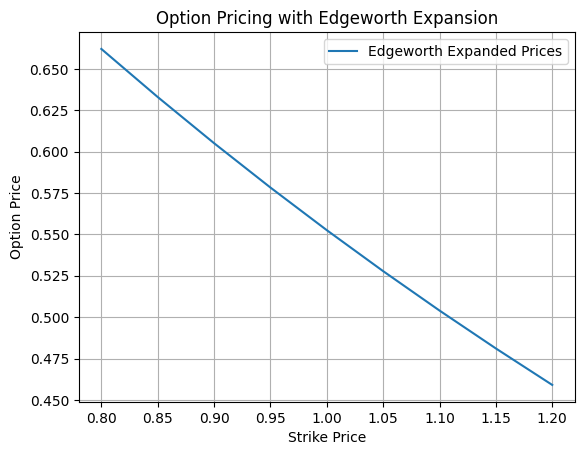

In [103]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import csv

# Edgeworth-expanded characteristic function
def charfun_edgeworth(params, u, tau):
    sigma_t = params[0]  # Spot volatility
    beta_t = params[1]   # Volatility-of-volatility
    rho_t = params[2]    # Leverage
    alpha_q_t = params[3]  # Drift adjustment
    delta_t = params[4]  # Drift volatility
    eta_t = params[5]    # Volatility of the volatility-of-volatility
    mu_tilde = params[6]  # Risk-free rate minus volatility adjustment

    # Base Gaussian term
    term_0 = np.exp(1j * u * mu_tilde * tau - 0.5 * u**2)

    # Skewness adjustment (third moment)
    term_skewness = -1j * u**3 * (beta_t * rho_t / (2 * sigma_t)) * np.sqrt(tau)

    # Kurtosis and higher-order adjustments
    term_kurtosis = -u**2 * ((alpha_q_t + delta_t) / (2 * sigma_t) + (beta_t**2) / (4 * sigma_t**2)) * tau
    term_kurtosis += (1/24) * (beta_t**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    term_kurtosis += (eta_t / (6 * sigma_t)) * u**4 * tau

    # Combine terms
    return term_0 * (1 + term_skewness + term_kurtosis)

# SINC operation function for option pricing
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    # Compute characteristic function values (Edgeworth expansion)
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_edgeworth(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_edgeworth(params, 2 * np.pi * wn - 1j, t)

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

# Example usage
CP = 1  # For call options
S = 1  # Spot price
t = 0.01  # Short tenor
K = S * np.arange(0.80, 1.21, 0.05)  # Strike prices
IR = 0.05  # Interest rate
DY = 0.02  # Dividend yield

# Edgeworth parameters
params = [0.2, 0.1, -0.5, 0.01, 0.01, 0.005, 0.03]  # [sigma_t, beta_t, rho_t, alpha_q_t, delta_t, eta_t, mu_tilde]
Xc = 8
Xm = 0
pow = 12

# Compute prices
prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)

# Plot results
plt.plot(K, prices, label="Edgeworth Expanded Prices")
plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title("Option Pricing with Edgeworth Expansion")
plt.legend()
plt.grid(True)
plt.show()


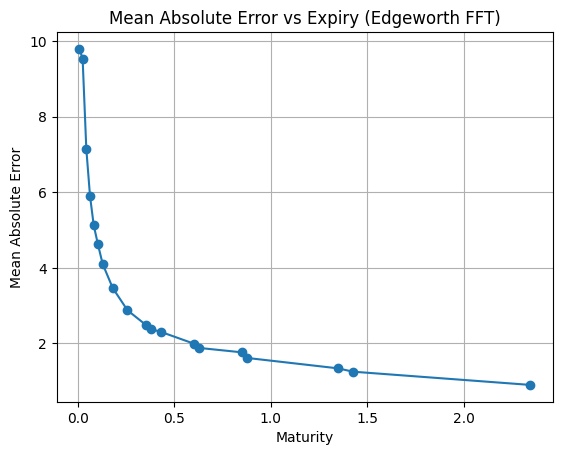

In [104]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import csv

# Edgeworth-expanded characteristic function
def charfun_edgeworth(params, u, tau):
    sigma_t = params[0]  # Spot volatility
    beta_t = params[1]   # Volatility-of-volatility
    rho_t = params[2]    # Leverage
    alpha_q_t = params[3]  # Drift adjustment
    delta_t = params[4]  # Drift volatility
    eta_t = params[5]    # Volatility of the volatility-of-volatility
    mu_tilde = params[6]  # Risk-free rate minus volatility adjustment

    # Base Gaussian term
    term_0 = np.exp(1j * u * mu_tilde * tau - 0.5 * u**2)

    # Skewness adjustment (third moment)
    term_skewness = -1j * u**3 * (beta_t * rho_t / (2 * sigma_t)) * np.sqrt(tau)

    # Kurtosis and higher-order adjustments
    term_kurtosis = -u**2 * ((alpha_q_t + delta_t) / (2 * sigma_t) + (beta_t**2) / (4 * sigma_t**2)) * tau
    term_kurtosis += (1/24) * (beta_t**2 / sigma_t**2) * u**2 * (4 * u**2 - rho_t**2 * u**2 * (3 * u**2 - 8)) * tau
    term_kurtosis += (eta_t / (6 * sigma_t)) * u**4 * tau

    # Combine terms
    return term_0 * (1 + term_skewness + term_kurtosis)

# SINC operation function for option pricing
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n

    # Compute characteristic function values (Edgeworth expansion)
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_edgeworth(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_edgeworth(params, 2 * np.pi * wn - 1j, t)

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

# Black-Scholes implied volatility calculation
def bs_implied_vol_put(S, K, T, r, P):
    n = len(K)
    sigmaL = 1e-10 * np.ones(n)
    PL = bs_formula_put(S, K, T, r, sigmaL)
    sigmaH = 10 * np.ones(n)
    PH = bs_formula_put(S, K, T, r, sigmaH)
    while np.mean(sigmaH - sigmaL) > 1e-10:
        sigma = (sigmaL + sigmaH) / 2
        PM = bs_formula_put(S, K, T, r, sigma)
        PL = np.where(PM < P, PM, PL)
        sigmaL = np.where(PM < P, sigma, sigmaL)
        PH = np.where(PM >= P, PM, PH)
        sigmaH = np.where(PM >= P, sigma, sigmaH)
    return sigma

# Black-Scholes pricing for put options
def bs_formula_put(S, K, T, r, sigma):
    x = np.log(S / K) + r * T
    sig = sigma * np.sqrt(T)
    d1 = x / sig + sig / 2
    d2 = d1 - sig
    pv = np.exp(-r * T)
    return pv * K * norm.cdf(-d2) - S * norm.cdf(-d1)

# Load market data
data = []
with open('spx_surf20130814.csv', 'r', encoding='utf-8-sig') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        data.append(row)

structured_data = {col.strip(): np.array([float(row[col]) for row in data]) for col in data[0].keys()}
expiries = np.unique(structured_data['t'])
params = [0.2, 0.1, -0.5, 0.01, 0.01, 0.005, 0.03]  # Example parameters
errors = []

# Process each expiry and calculate implied volatilities
for expiry in expiries:
    subset_indices = structured_data['t'] == expiry
    fwd, t, K = structured_data['fwd'][subset_indices][0], expiry, structured_data['K'][subset_indices]
    impVol_bench = structured_data['impVol'][subset_indices]
    prices = sinc_fast_ft(S=fwd, t=t, K=K, IR=0, DY=0, params=params, Xc=4, Xm=0, pow=14, CP=-1)
    impVol_model = bs_implied_vol_put(fwd, K, t, 0, prices)
    error = np.mean(np.abs(impVol_model - impVol_bench))
    errors.append(error)

plt.plot(expiries, errors, marker='o')
plt.xlabel('Maturity')
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error vs Expiry (Edgeworth FFT)')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2

    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)
    
    #print("charfun_heston wn:", charfun_heston(params, 2 * np.pi * wn, t))
    #print("charfun_heston wn-1:", charfun_heston(params, 2 * np.pi * wn - 1j, t))
    #print("Size: ", np.size(charfun_heston(params, 2 * np.pi * wn - 1j, t)))

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

CP = 1  # for Call options
S = 1
t = 1.00
K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
IR = 0.05  # Interest rate
DY = 0.02  # Dividend yield
params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
# Select Xc based on time to maturity
if t == 1.00:
    Xc = 12.1802  # Increased truncation range
Xm = 0
    
#pow = 20  # Increased FFT precision
pow = 21  # Increase precision

heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)

In [ ]:
def discrete_component(u, tau, sigma_t, lambda_t, mu_j, sigma_j, mu_bar_j):
    """
    Calculates the discrete (jump) component of the characteristic function for 0DTE options.

    Parameters:
    - u: Fourier variable
    - tau: Small time to maturity
    - sigma_t: Current volatility of the asset
    - lambda_t: Jump intensity (expected number of jumps per unit time)
    - mu_j: Mean jump size (log scale)
    - sigma_j: Volatility of jumps
    - mu_bar_j: Adjusted mean jump size (log scale)

    Returns:
    - The discrete component of the characteristic function value for the log-price of the asset.
    """ä
    
    # Calculate the exponent terms
    jump_mean_term = 1j * u * mu_j / (sigma_t * np.sqrt(tau))
    jump_variance_term = - u**2 * sigma_j**2 / (2 * sigma_t**2 * tau)
    
    # Combine terms to compute the discrete component
    C_logXd = np.exp(tau * lambda_t * (np.exp(jump_mean_term + jump_variance_term) - 1 - 1j * u * mu_bar_j))
    
    return C_logXd

In [86]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Updating scipy to use module QMC for Latin hypercube sampling
#!pip install scipy==1.7
from scipy.stats import qmc

# Pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

In [87]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)

cuda


# 1) Black Scholes pricing network: BS-ANN

### Closed-form formula

In [12]:
def bs_price_call(S, K, T, t, r, sigma):
  """
  Black-Scholes call option value price related to PDE (2). Returns option's price.
  S: spot price
  K: strike price
  T: time to maturity
  t: spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  # Boundary condition of Black-Sholes PDE (2)
  if T == t:
    return np.maximum(0, S - K)  
  # Solution of the PDE (2) on the open interval [t, T)
  else : 
    d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma*np.sqrt(T-t)
    value = S * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2) 
  
  return value

def bs_moneyness_call(moneyness, tau, r, sigma):
  """
  Same function as bs_price_call but in terms of moneyness. Returns V/K and 
  has S/K instead of two seperate paremeters S and K.
  moneyness: S/K
  Tau: time to maturity minus spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  d1 = ( np.log(moneyness) + (r + 0.5 * sigma ** 2) * (tau) ) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma*np.sqrt(tau)
  value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * (tau)) * norm.cdf(d2) 
  
  return value_moneyness

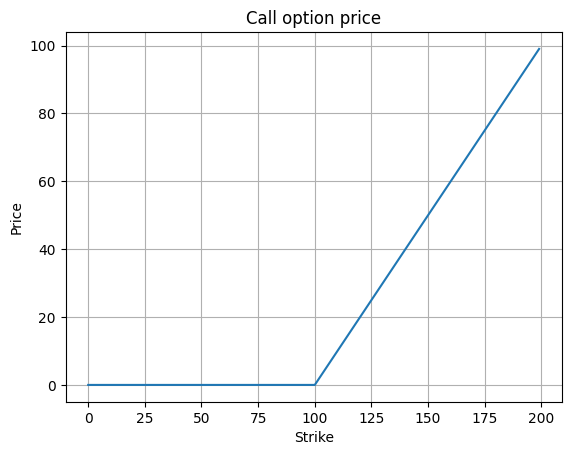

In [13]:
# Checking the call prices with respect to strikes
r, T, t, sigma, K, S = .02, 1, 1, .2, 100, np.arange(200)
plt.plot(S, bs_price_call(S, K, T, t, r, sigma))
plt.xlabel("Strike")
plt.ylabel("Price")
plt.title("Call option price" )
plt.grid()

### Data generation

In [14]:
def bs_LHS_data_generator(n = 10**6, l_bounds = [.4, .2, .02, .01], u_bounds = [1.6, 1.1, .1, 1]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,5) containig the inputs samples and the value of the call.
  The inputs are: Moneyness (S/K), time to maturity (tau), Risk free rate (r), Volatility (sigma).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.

  """
  sampler = qmc.LatinHypercube(d = 4)
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  bs_prices = bs_moneyness_call(sample[:, 0], sample[:, 1], sample[:, 2], sample[:, 3]).reshape((-1, 1))
  bs_dataset = np.concatenate((sample, bs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]),max(bs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]),max(bs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]),max(bs_dataset[:,2])))
  print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]),max(bs_dataset[:,4])))


  return torch.FloatTensor(bs_dataset)

# Testing the function
bs_dataset = bs_LHS_data_generator()

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.90]


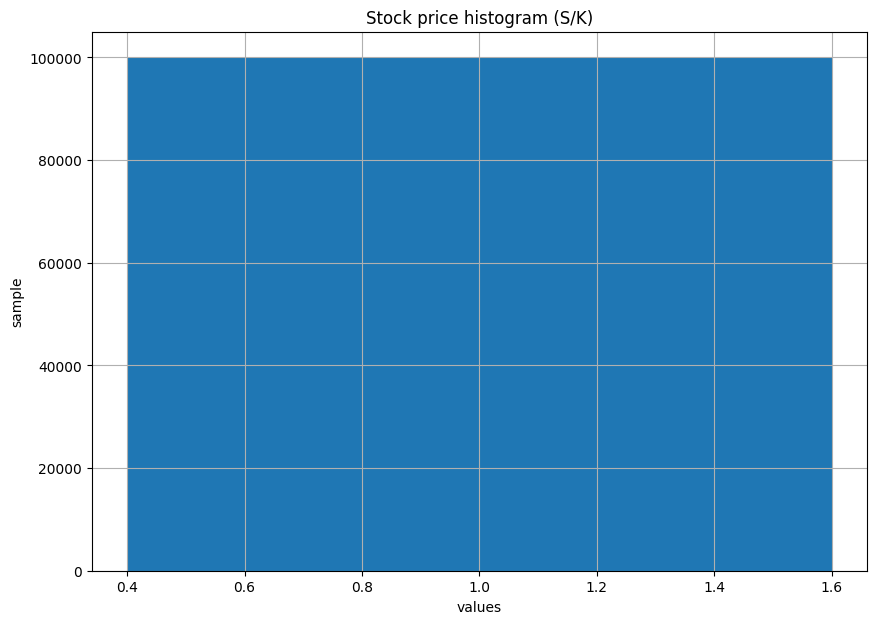

In [15]:
# Checking the LHS distribution of the input
plt.figure(figsize=(10,7))
h = plt.hist(bs_dataset[:,0], bins= 10)
plt.xlabel("values")
plt.ylabel("sample")
plt.title("Stock price histogram (S/K)" )
plt.grid()

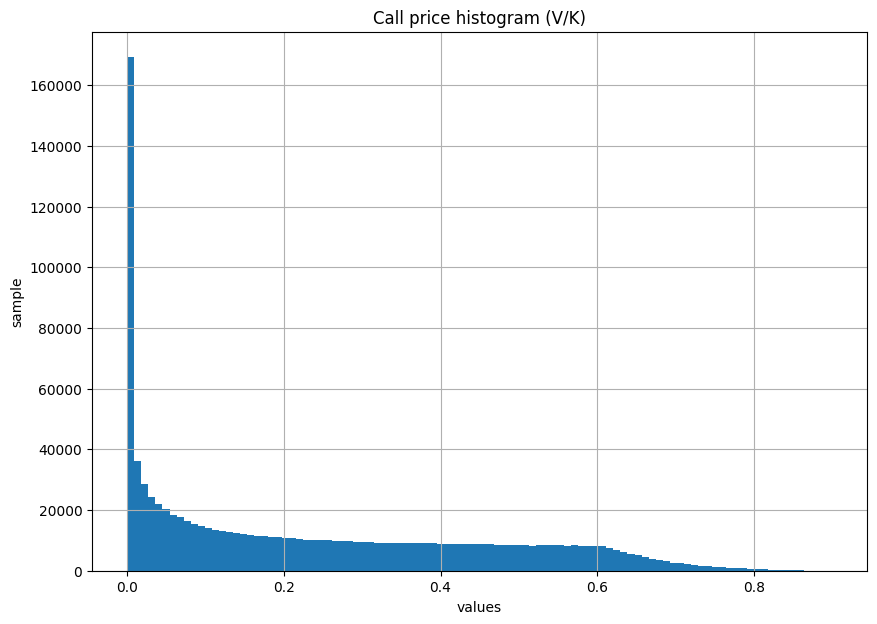

In [16]:
# Checking the output distribution (V/K).
plt.figure(figsize=(10,7))
h = plt.hist(bs_dataset[:,-1],bins=100)
plt.xlabel("values")
plt.ylabel("sample")
plt.title("Call price histogram (V/K)" )
plt.grid()

**Remark:** The majority of option prices are below 0.01

### Defining class BS-ANN

### Search of optimal Learning rate interval

**Remark:** it seems like the best interval is from $10^{-4}$ to $10^{-6}$

Training WIDE 1.2428339981502956 VS in the article 8.04e-09


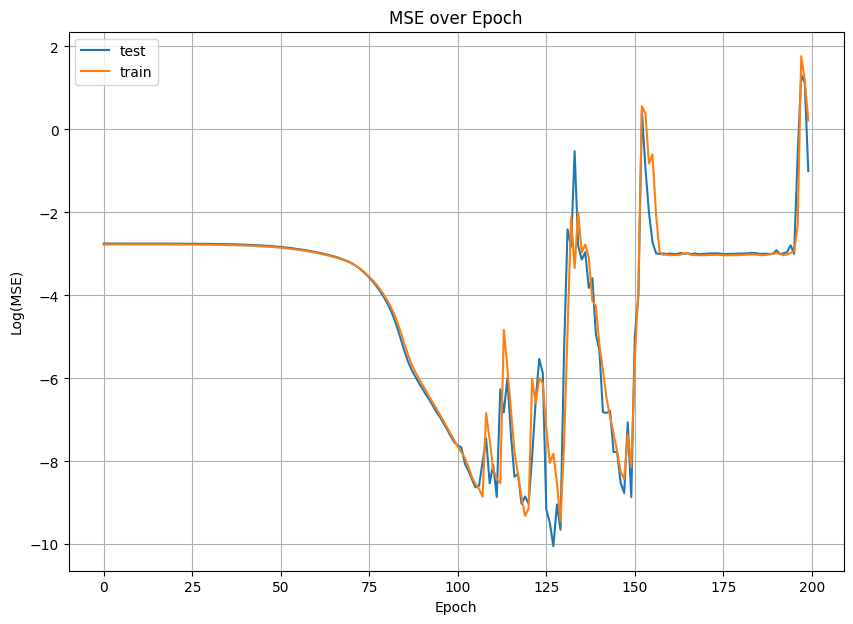

In [20]:
# ADDED CODE BOX
# Plotting the Log(MSE) with respect to the epoch
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(MSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

### Training BS-ANN with DecayLR from $10^{-4}$ to $10^{-6}$ Wide dataset

In [11]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
bs_dataset = bs_LHS_data_generator(n = 10**5)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])



print(device)
model = BS_ANN().to(device)
# Adam is found to be the best optimizer in the article
optimizer = optim.Adam(model.parameters(), lr = args["lr"]) 
# Deacreses the Learning rate by .1 every 1000 epoch
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) 

train_losses = []
test_losses = []
# Training loop
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "BS_ANN.pt")
    

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.89]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -1.878099

Train set: Average log loss: -3.9773


Test set: Average loss: -6.4762

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -6.488426

Train set: Average log loss: -7.1410


Test set: Average loss: -7.7887

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -7.836579

Train set: Average log loss: -8.2131


Test set: Average loss: -8.6201

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -8.637086

Train set: Average log loss: -8.9441


Test set: Average loss: -9.3021

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -9.280575

Train set: Average log loss: -9.6135


Test set: Average loss: -9.9635

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -9.906272

Train set: Av

Training WIDE 2.3003252494251886e-08 VS in the article 8.04e-09


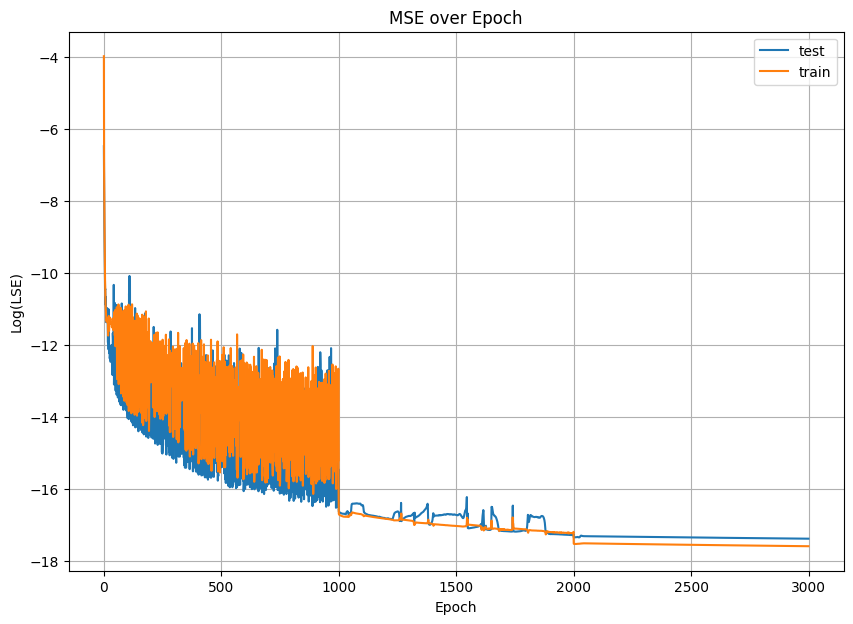

In [12]:
# Plotting the Log(MSE) with respect to the epoch
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(MSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [8]:
# Loading model from saved parameters
loaded_BS_ANN = BS_ANN().to(device)
PATH = "ANN_weights/BS_ANN.pt"
loaded_BS_ANN.load_state_dict(torch.load(PATH))
loaded_BS_ANN.eval()


BS_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

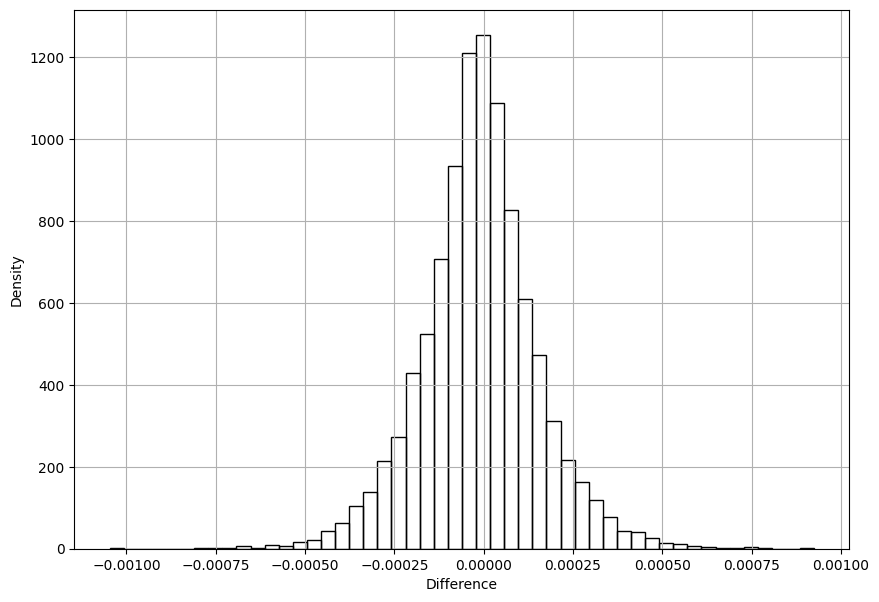

MAX  0.00092506036
MIN  -0.0010469928


In [14]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors, 50, fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [15]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 2.652397e-08
MAE 1.207284e-04
MAPE 1.947651e-01
R2 9.999994e-01
-----------Test scores----------------
MSE 2.647280e-08
MAE 1.212164e-04
MAPE 1.242439e-01
R2 9.999995e-01


In [16]:
np.sqrt(2.597518e-08)

0.00016116817303673826

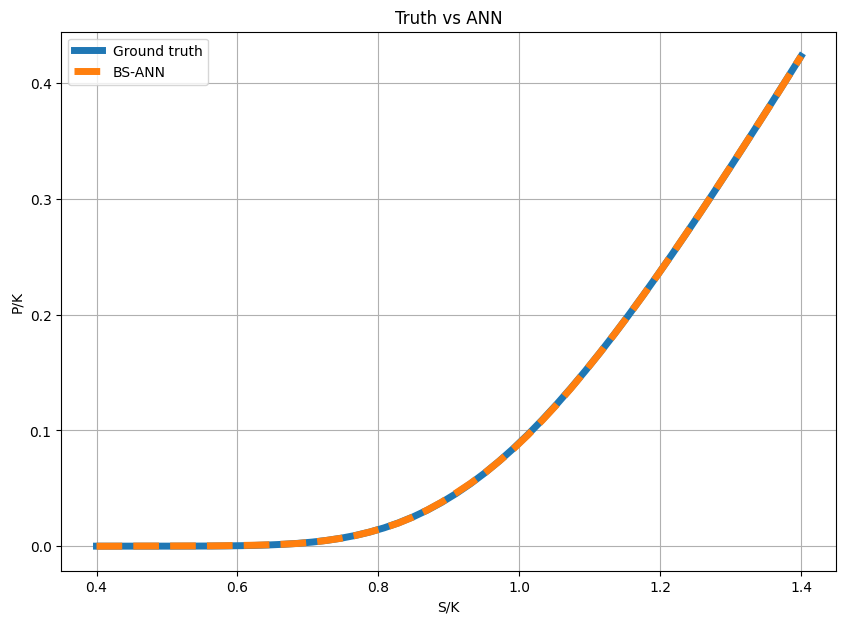

In [18]:
# Replace this with a matrix
moneyness = np.linspace(0.4,1.4)
tau, r, sigma = 1, .02, .2
prices = bs_moneyness_call(moneyness, tau, r, sigma)

plot_dateset = np.ones((50,4))
plot_dateset[:,0] = moneyness
plot_dateset[:,1] = plot_dateset[:,1]*tau
plot_dateset[:,2] = plot_dateset[:,2]*r
plot_dateset[:,3] = plot_dateset[:,3]*sigma


plt.figure(figsize=(10,7))
plt.plot(moneyness, prices, label="Ground truth", linewidth=5 )


plot_dateset = torch.from_numpy(plot_dateset).type(torch.FloatTensor).to(device)
output = loaded_BS_ANN(plot_dateset)
plt.plot(moneyness, output.data.cpu().numpy(), "--", label="BS-ANN", linewidth=5)

plt.legend()
plt.xlabel("S/K (moneyness)")
plt.ylabel("P/K")
plt.title("Truth vs ANN" )
plt.grid()

### Training BS-ANN with DecayLR from $10^{-4}$ to $10^{-6}$ Narrow dataset 

In [19]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
l_bounds = [.5, .3, .03, .02]
u_bounds = [1.5, .95, .08, .9]
bs_dataset = bs_LHS_data_generator(n = 10**5,l_bounds=l_bounds, u_bounds=u_bounds)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])



print(device)
model = BS_ANN().to(device)
# Adam is found to be the best optimizer in the article
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) 
# Deacreses the Learning rate by .1 every 1000 epoch
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) 

train_losses = []
test_losses = []
# Training loop
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "BS_ANN_narrow.pt")
    

------ INPUT ------
S/K.......... [0.50 1.50]
Tau.......... [0.30 0.95]
r............ [0.03 0.08]
Sigma........ [0.02 0.90]
------ OUTPUT ------
V/K.......... [0.00 0.73]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -2.623463

Train set: Average log loss: -4.5871


Test set: Average loss: -6.9200

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -6.930228

Train set: Average log loss: -7.5880


Test set: Average loss: -8.3521

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -8.407589

Train set: Average log loss: -8.8279


Test set: Average loss: -9.3110

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -9.395084

Train set: Average log loss: -9.6382


Test set: Average loss: -9.8990

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -9.922584

Train set: Average log loss: -10.1613


Test set: Average loss: -10.3838

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -10.427864

Train set:

In [20]:
# Loading model from saved parameters
loaded_BS_ANN = BS_ANN().to(device)
PATH = "ANN_weights/BS_ANN_narrow.pt"
loaded_BS_ANN.load_state_dict(torch.load(PATH))
loaded_BS_ANN.eval()


BS_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

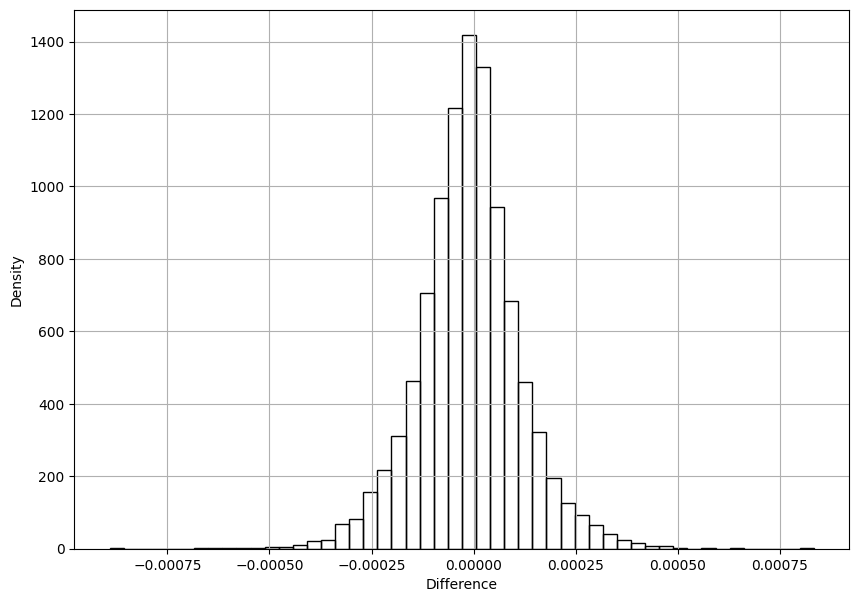

MAX  0.0008338839
MIN  -0.0008913651


In [21]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,50,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [22]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 1.578677e-08
MAE 9.406319e-05
MAPE 9.084946e-02
R2 9.999995e-01
-----------Test scores----------------
MSE 1.529350e-08
MAE 9.230250e-05
MAPE 9.723768e-02
R2 9.999995e-01


In [23]:
np.sqrt(1.554532e-08)

0.00012468087263088913

# 2) Implied volatility network: IV-ANN

### Defining class IV-ANN 

In [25]:
class IV_ANN(BS_ANN):
    # The authors of the paper seem to use
    # the same architecture both for BS-ANN and the IV-ANN
    # thus the class inherets from BS_ANN
  pass

### Data Generation with log transformation

Log transformation 

$\tilde{V}=V_{t}-\max \left(S_{t}-K e^{-r \tau}, 0\right)$

$\left\{\log (\tilde{V} / K), S_{0} / K, r, \tau\right\}$

In [26]:
def IV_LHS_data_generator(n = 10**6, l_bounds = [.5, .05, .0, .05], u_bounds = [1.4, 1, .1, 1], log_scale = True):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,5) containig the inputs samples and the volatility as the target.
  Performs a log transormation of V/K.
  The inputs are: Moneyness (S/K), time to maturity (tau), Risk free rate (r), Volatility (sigma).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  log_scale: performs log transformation if True.

  """
  sampler = qmc.LatinHypercube(d=4)
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  bs_prices = bs_moneyness_call(sample[:,0], sample[:,1], sample[:,2], sample[:,3]).reshape((-1,1))


  bs_dataset = np.concatenate((sample[:,:-1], bs_prices, sample[:,3].reshape((n,1))),axis=1)
  # log transformation as in section 4.3
  if log_scale : 
    bs_dataset[:,3] = bs_dataset[:,3] - np.maximum(bs_dataset[:,0]-np.exp(-bs_dataset[:,1]*bs_dataset[:,2]),0)
    indecies = np.argwhere(bs_dataset[:,3]< 1e-7)
    bs_dataset = np.delete(bs_dataset, indecies,0)
    bs_dataset[:,3] = np.log(bs_dataset[:,3])

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]),max(bs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]),max(bs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]),max(bs_dataset[:,2])))
  if log_scale : 
    print("log(V/K)..... [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
  else : 
    print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
  print("------ OUTPUT ------")
  print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]),max(bs_dataset[:,4])))
  return torch.FloatTensor(bs_dataset)

bs_dataset = IV_LHS_data_generator(log_scale = True)

------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
log(V/K)..... [-16.12 -0.99]
------ OUTPUT ------
Sigma........ [0.05 1.00]


### Training IV-ANN with log transofmation

In [27]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# Loading Train / Test Data
bs_dataset = IV_LHS_data_generator(n = 10**5, log_scale = True)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, bs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = IV_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "IV_SCALED_ANN.pt")
    

------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
log(V/K)..... [-16.12 -0.99]
------ OUTPUT ------
Sigma........ [0.05 1.00]
cuda
Train Epoch: 1 [0/85187 (0%)]	log Loss: -0.671939

Train set: Average log loss: -2.8045


Test set: Average loss: -3.6490

Current Learning rate 0.0001
Train Epoch: 2 [0/85187 (0%)]	log Loss: -3.637234

Train set: Average log loss: -3.8461


Test set: Average loss: -4.0413

Current Learning rate 0.0001
Train Epoch: 3 [0/85187 (0%)]	log Loss: -4.062339

Train set: Average log loss: -4.2294


Test set: Average loss: -4.4881

Current Learning rate 0.0001
Train Epoch: 4 [0/85187 (0%)]	log Loss: -4.476239

Train set: Average log loss: -4.8251


Test set: Average loss: -5.2713

Current Learning rate 0.0001
Train Epoch: 5 [0/85187 (0%)]	log Loss: -5.229585

Train set: Average log loss: -5.6174


Test set: Average loss: -5.9795

Current Learning rate 0.0001
Train Epoch: 6 [0/85187 (0%)]	log Loss: -5.890696

Train set:

In [29]:
# Loading model from saved weights
device = torch.device("cuda")
loaded_IV_ANN = IV_ANN().to(device)
PATH = "ANN_weights/IV_SCALED_ANN.pt"
loaded_IV_ANN.load_state_dict(torch.load(PATH))
loaded_IV_ANN.eval()


IV_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

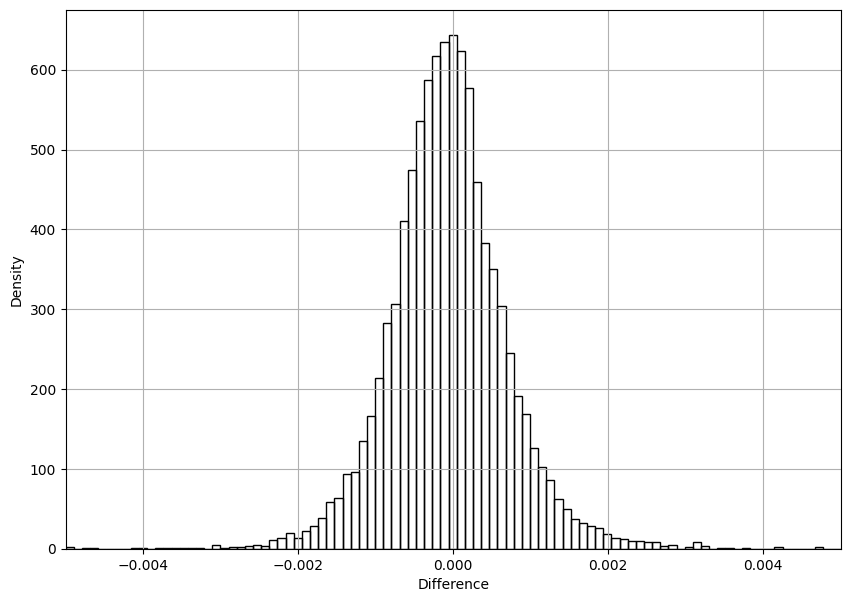

MAX  0.005511403
MIN  -0.0050005317


In [30]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,100,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.xlim([-0.005, 0.005])
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [31]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.137644e-07
MAE 5.638418e-04
MAPE 1.528163e-03
R2 9.999912e-01
-----------Test scores----------------
MSE 5.863549e-07
MAE 5.648760e-04
MAPE 1.545854e-03
R2 9.999915e-01


### Training IV-ANN without log transofmation

In [32]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Train / Test Data
bs_dataset = IV_LHS_data_generator(n = 10**5, log_scale = False)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, bs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = BS_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "IV_UNSCALED_ANN.pt")
    

------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
V/K.......... [0.00 0.69]
------ OUTPUT ------
Sigma........ [0.05 1.00]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -0.959341

Train set: Average log loss: -2.4540


Test set: Average loss: -2.6480

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -2.619602

Train set: Average log loss: -2.7389


Test set: Average loss: -2.9221

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -2.905974

Train set: Average log loss: -3.2516


Test set: Average loss: -3.6121

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -3.637082

Train set: Average log loss: -3.8467


Test set: Average loss: -4.0643

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -4.068975

Train set: Average log loss: -4.2036


Test set: Average loss: -4.3170

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -4.306699

Train set: Av

In [33]:
# Loading model
device = torch.device("cuda")
loaded_IV_ANN_UN = IV_ANN().to(device)
PATH = "ANN_weights/IV_UNSCALED_ANN.pt"
loaded_IV_ANN_UN.load_state_dict(torch.load(PATH))
loaded_IV_ANN_UN.eval()


IV_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

MAX  0.23030132
MIN  -0.44819307


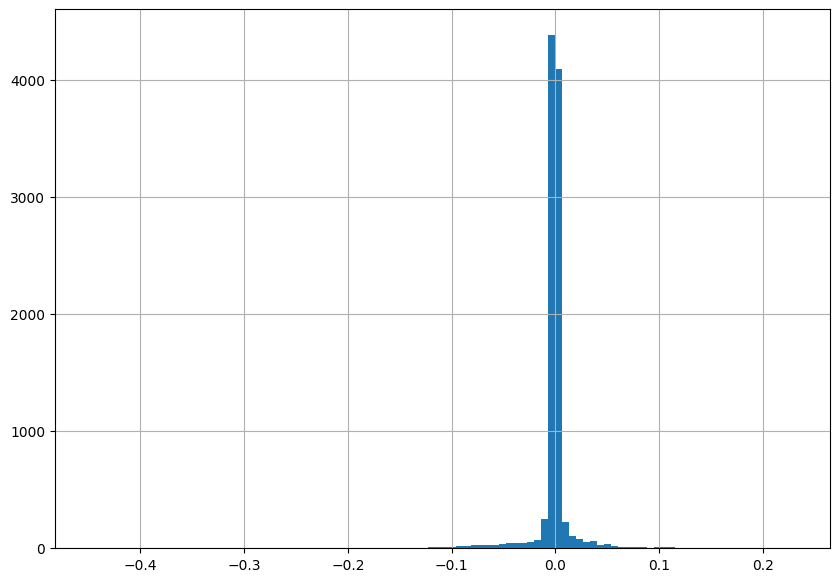

In [34]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
h = plt.hist(errors,100)
plt.grid()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [35]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.599748e-04
MAE 8.277198e-03
MAPE 3.761932e-02
R2 9.910348e-01
-----------Test scores----------------
MSE 6.838114e-04
MAE 8.216325e-03
MAPE 3.740349e-02
R2 9.906515e-01


# 3) COS Method

#### Vanilla call coefficients

$\begin{aligned} \chi_{k}(c, d):=& \frac{1}{1+\left(\frac{k \pi}{b-a}\right)^{2}}\left[\cos \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\cos \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right.\\ &\left.+\frac{k \pi}{b-a} \sin \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\frac{k \pi}{b-a} \sin \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right] \end{aligned}$

$\psi_{k}(c, d):= \begin{cases}{\left[\sin \left(k \pi \frac{d-a}{b-a}\right)-\sin \left(k \pi \frac{c-a}{b-a}\right)\right] \frac{b-a}{k \pi},} & k \neq 0, \\ (d-c), & k=0 .\end{cases}$

$V_{k}^{\text {call }}=\frac{2}{b-a} K\left(\chi_{k}(0, b)-\psi_{k}(0, b)\right)$

In [36]:
def call_cosine_coef(a, b, c, d, K, N):
  """
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  K: Strike.
  N: summing lenght.
  Returns V_k coefficient for call option.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*K*(chi_k-psi_k)

In [37]:
def call_cosine_coef_moy(a, b, c, d, N):
  """
  Moyeness version.
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  N: summing lenght.
  Returns V_k coefficient for call option devided by K.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*(chi_k-psi_k)

#### Charateristic function for Heston model

$\begin{aligned} \varphi_{h e s}\left(\omega ; u_{0}\right)=& \exp \left(i \omega \mu \Delta t+\frac{u_{0}}{\eta^{2}}\left(\frac{1-e^{-D \Delta t}}{1-G e^{-D \Delta t}}\right)(\lambda-i \rho \eta \omega-D)\right) \\ & \cdot \exp \left(\frac{\lambda \bar{u}}{\eta^{2}}\left(\Delta t(\lambda-i \rho \eta \omega-D)-2 \log \left(\frac{1-G e^{-D \Delta t}}{1-G}\right)\right)\right) \end{aligned}$

$D=\sqrt{(\lambda-i \rho \eta \omega)^{2}+\left(\omega^{2}+i \omega\right) \eta^{2}} \quad$ and $\quad G=\frac{\lambda-i \rho \eta \omega-D}{\lambda-i \rho \eta \omega+D} $

In [38]:
def phi_Heston(a ,b ,N ,r, tau, kappa, gamma, vbar, v0, rho):
  """
  Characteristic function of the log-asset price following the Heston model.
  Section 3.3, equation (33).
  a, b: truncation range parameters.
  N: summing lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns Charateristic function vector.
  """
  k = np.arange(N).reshape(1,-1)
  u = np.pi*k/(b-a)
  i = complex(0.0,1.0)
  D = np.sqrt((kappa-gamma*rho*i*u)**2+(u**2+i*u)*gamma**2)
  G = (kappa-gamma*rho*i*u-D)/(kappa-gamma*rho*i*u+D)
  C = v0* (1-np.exp(-D*tau)) / (gamma**2*(1-G*np.exp(-D*tau)))*(kappa-gamma*rho*i*u-D)
  A = r*i*u*tau + kappa*vbar/(gamma**2)*(tau*(kappa-gamma*rho*i*u-D) -2*np.log( (1-G*np.exp(-D*tau))/(1-G) )   ) 
  phi = np.exp( A + C )
  return phi


#### Heston cumulants

$c_{1}=\mu T+\left(1-e^{-\lambda T}\right) \frac{\bar{u}-u_{0}}{2 \lambda}-\frac{1}{2} \bar{u} T$

$\begin{aligned} c_{2}=& \frac{1}{8 \lambda^{3}}\left(\eta T \lambda e^{-\lambda T}\left(u_{0}-\bar{u}\right)(8 \lambda \rho-4 \eta)\right.\\ &+\lambda \rho \eta\left(1-e^{-\lambda T}\right)\left(16 \bar{u}-8 u_{0}\right) \\ &+2 \bar{u} \lambda T\left(-4 \lambda \rho \eta+\eta^{2}+4 \lambda^{2}\right) \\ &+\eta^{2}\left(\left(\bar{u}-2 u_{0}\right) e^{-2 \lambda T}+\bar{u}\left(6 e^{-\lambda T}-7\right)+2 u_{0}\right) \\ &\left.+8 \lambda^{2}\left(u_{0}-\bar{u}\right)\left(1-e^{-\lambda T}\right)\right) \end{aligned}$

In [39]:
def Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho ):
  """
  Computes Heston cumulants as defined in the appendix A for the Heston model.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns cumulants c1 and c2.
  """
  c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau
  
  c2 = 0.125 / kappa ** 3 * (gamma * tau * np.exp(- kappa * tau) * (v0 - vbar) * (8 * kappa * rho - 4 * gamma) + \
     kappa * rho * gamma * (1 - np.exp(- kappa * tau)) * (16 * vbar - 8 * v0) + \
     2 * vbar * kappa * tau * (- 4 * kappa * rho * gamma + gamma ** 2 + 4 * kappa ** 2) + \
     gamma ** 2 * ((vbar - 2 * v0) * np.exp(-2 * kappa * tau) + vbar * (6 * np.exp(- kappa * tau) - 7) + 2 * v0) + \
     8 * kappa ** 2 * (v0 - vbar) * (1 - np.exp(-kappa * tau)))
  return c1, c2

#### Truncation range

$[a, b]:=\left[c_{1}-L \sqrt{c_{2}+\sqrt{c_{4}}}, \quad c_{1}+L \sqrt{c_{2}+\sqrt{c_{4}}}\right]$

In [40]:
def Truncation_range(c1, c2, c4, L):
  """
  Computes the truncation range given the cumulants c1, c2, c4 and the truncation lenght L.
  c1, c2, c4: Model cumulants.
  L: truncation lenght.
  Returns tuncation interval sup b and inf a.
  """
  a = c1 - L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) )
  b = c1 + L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) ) 
  return a, b

#### Exponential coefficient

$e^{i k \pi \frac{\mathbf{x}-a}{b-a}}$

In [41]:
def exponential_coef(a, b, N, S0, K):
  """
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  S0: asset initial price.
  K: strike.
  Returns the exponential coefficient vector.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(S0/K)-a)/(b-a))

In [42]:
def exponential_coef_moy(a, b, N, moyeness):
  """
  Moyeness version.
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  moyeness: S/K.
  Returns the exponential coefficient vector devided by K.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(moyeness)-a)/(b-a))

#### Vanilla call price

$v\left(\mathbf{x}, t_{0}, u_{0}\right) \approx \mathbf{K} e^{-r \Delta t} \cdot \operatorname{Re}\left\{\sum_{k=0}^{N-1} \varphi_{h e s}\left(\frac{k \pi}{b-a} ; u_{0}\right) U_{k} \cdot e^{i k \pi \frac{\mathbf{x}-a}{b-a}}\right\}$

In [43]:
def call_option_Heston(N, L, r, tau, kappa, gamma, vbar, v0, rho, K, S0 ):
  """
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  S0: asset initial price.
  K: strike.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef(a, b, c, d, K, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef(a, b, N, S0, K)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [44]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, K = K, S0 = S0)

True


array([[29.79261082]])

In [45]:
def call_option_Heston_moy(N, L, r, tau, kappa, gamma, vbar, v0, rho, moyeness ):
  """
  Moyeness version.
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  moyeness: S/K.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef_moy(a, b, c, d, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef_moy(a, b, N, moyeness)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [44]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston_moy(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = 1)

True


array([[0.29792611]])

# 4) Heston pricing network: Heston-ANN

### Generating Data

In [46]:
eps = 1e-2 # is used to generate open intervals
def Heston_LHS_data_generator(n = 10**6, l_bounds = [.6+eps, .1+eps, .0+eps, -0.95+eps, .4+eps, .0+eps, .0+eps, .05+eps], u_bounds = [1.4-eps, 1.4-eps, .1-eps, 0.0-eps, 2.0-eps, .5-eps, .5-eps, .5-eps]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,9) containig the inputs samples and the value of the call.
  The inputs are: Moyeness (S/K), time to maturity (tau), Risk free rate (r), Correlation (rho), reversion speed (kappa), Long average variance (vbar), Vol of vol (gamma), Initial variance (v0).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  """
  sampler = qmc.LatinHypercube(d=8) #, seed = 0
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  indecies = np.argwhere(2*sample[:,4]*sample[:,5]<= sample[:,6]**2)
  sample = np.delete(sample, indecies,0)
  # print(sample.shape)
  # print(2*kappa*vbar>gamma**2)
  hs_prices = call_option_Heston_moy(N = 160, L= 12, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
                                     gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
                                     rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  # hs_prices = call_option_Heston_moy(N = 1500, L= 50, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
  #                                    gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
  #                                    rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  
  hs_dataset = np.concatenate((sample, hs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,0]),max(hs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,1]),max(hs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(hs_dataset[:,2]),max(hs_dataset[:,2])))
  print("Corr ........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,3]),max(hs_dataset[:,3])))
  print("Kappa........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,4]),max(hs_dataset[:,4])))
  print("V_bar........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,5]),max(hs_dataset[:,5])))
  print("Gamma........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,6]),max(hs_dataset[:,6])))
  print("V_0 ......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,7]),max(hs_dataset[:,7])))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,-1]),max(hs_dataset[:,-1])))
  # ind_max = np.argmax(hs_dataset[:,-1])
  # print(hs_dataset[ind_max,:])

  return torch.FloatTensor(hs_dataset)

hs_dataset = Heston_LHS_data_generator(10**4)

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.11 1.39]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.63]


### Defining class Heston-ANN

In [47]:
class Heston_ANN(BS_ANN):
  def __init__(self):
    """
    Initilize BS-Heston_ANN netwwork. Same architecture as the one used in tge article.
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    Takes inputs of size 8.
    """
    super(Heston_ANN, self).__init__()
    self.fc1 = nn.Linear(8, 400)
    self.fc2 = nn.Linear(400, 400)
    self.fc3 = nn.Linear(400, 400)
    self.fc4 = nn.Linear(400, 400)
    self.fc5 = nn.Linear(400, 1)

    torch.nn.init.xavier_uniform_(self.fc1.weight)
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)

### Training Heston-ANN

In [48]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "Heston_ANN.pt")
    

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.11 1.39]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.63]
cuda
Train Epoch: 1 [0/83759 (0%)]	log Loss: -1.827268

Train set: Average log loss: -4.1918


Test set: Average loss: -6.8416

Current Learning rate 0.0001
Train Epoch: 2 [0/83759 (0%)]	log Loss: -6.777963

Train set: Average log loss: -7.6731


Test set: Average loss: -8.5627

Current Learning rate 0.0001
Train Epoch: 3 [0/83759 (0%)]	log Loss: -8.549292

Train set: Average log loss: -8.9597


Test set: Average loss: -9.2408

Current Learning rate 0.0001
Train Epoch: 4 [0/83759 (0%)]	log Loss: -9.206422

Train set: Average log loss: -9.5062


Test set: Average loss: -9.7364

Current Learning rate 0.0001
Train Epoch: 5 [0/83759 (0%)]	log Loss: -9.710156

Train set: Average log loss: -9.9207


Test set: Average lo

Training WIDE 7.775201280321086e-08 VS in the article 8.04e-09


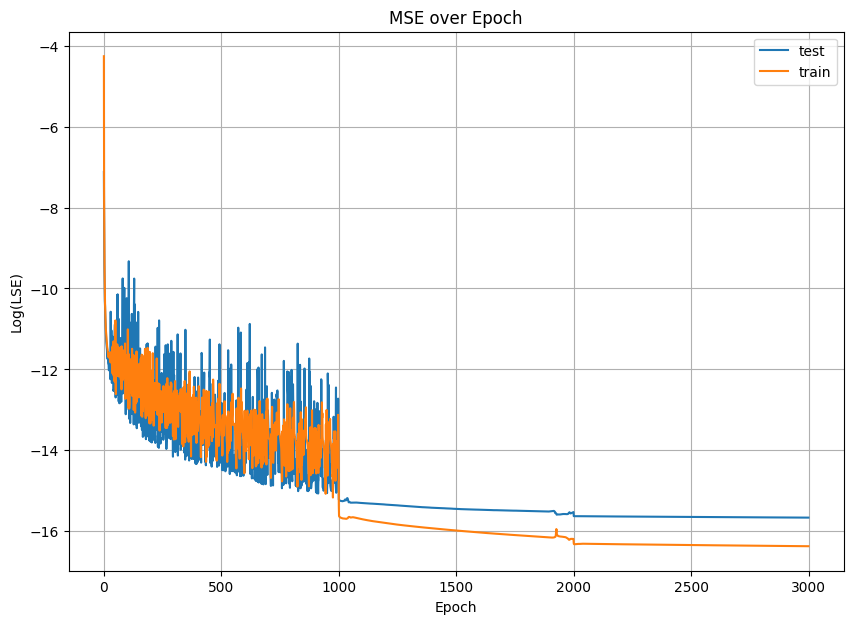

In [48]:
# Plotting log(MSE) as a function of epochs
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(LSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [49]:
# Loading model
device = 'cuda'
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()


Heston_ANN(
  (fc1): Linear(in_features=8, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

In [50]:
# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0]-train_size])
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}
train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.11 1.39]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.64]


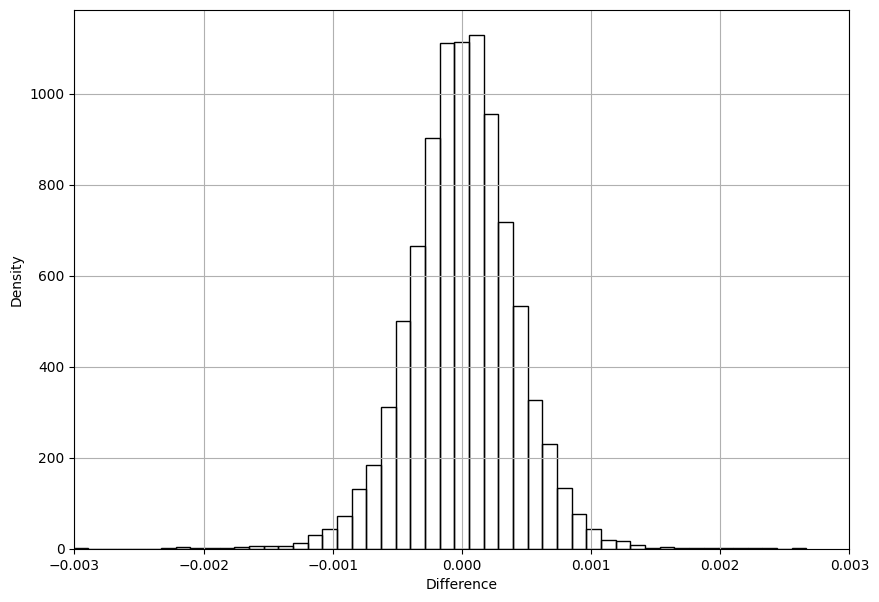

MAX  0.00266546
MIN  -0.0030121505


In [51]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,50,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.xlim([-0.003, 0.003])
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [52]:
# printing train and test erros MSE, MAE, MAPE, R2.
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 1.620948e-07
MAE 3.069885e-04
MAPE 1.953139e-02
R2 9.999926e-01
-----------Test scores----------------
MSE 1.664916e-07
MAE 3.105019e-04
MAPE 1.748970e-02
R2 9.999923e-01


In [53]:
np.sqrt(1.670718e-07)

0.0004087441742704108

# 5) BRENT

In [54]:
from scipy import optimize

def calcimpliedvol(dataset):
    """
    Computes the implied volatilities using the brent method.
    dataset: numpy array containing moneyness, time to maturity, risk free interest rate and V/K.
    Returns a vector of implied volatilities.
    """
    money = np.array(dataset[0])
    T = np.array(dataset[1])
    r = np.array(dataset[2])
    marketoptionPrice = np.array(dataset[3])
    def bs_price(sigma):
      d1 = ( np.log(money) + (r + 0.5 * sigma ** 2) * (T) ) / (sigma * np.sqrt(T))
      d2 = d1 - sigma*np.sqrt(T)
      value_moyeness = money * norm.cdf(d1) - np.exp(-r * (T)) * norm.cdf(d2) 
      fx = value_moyeness - marketoptionPrice
      return fx
    return optimize.brentq(bs_price,-1,1,maxiter=100)

bs_dataset = bs_LHS_data_generator(n=10**4).data
ground_truth_vol = bs_dataset[:,3]
bs_dataset = bs_dataset[:,np.array([0,1,2,4])]
vol_imp = np.apply_along_axis(calcimpliedvol, 1, bs_dataset)
print("MSE ", ((ground_truth_vol - vol_imp)**2).mean().item())

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.85]
MSE  0.00014862391368948422


# 6) Pipeline 1: COS + BRENT

In [55]:
eps = 1e-2 # is used to generate open intervals
# (S/K), (tau), (r), (rho), (kappa), (vbar), (gamma), (v0).
# CASE 1 in table 11
l_bounds = [.75+eps, .4+eps, .0+eps, -0.95+eps, .4+eps, .0+eps, .0+eps, .05+eps]
u_bounds = [1.25-eps, 1.-eps, .1-eps, 0.0-eps, 2.0-eps, .5-eps, .5-eps, .5-eps]
hs_dataset = Heston_LHS_data_generator(10**5, l_bounds = l_bounds, u_bounds=u_bounds)
hs_dataset_data = hs_dataset.data
hs_dataset_data = hs_dataset_data[:,np.array([0,1,2,8])]
implied_vol_pipe1 = np.apply_along_axis(calcimpliedvol, 1, hs_dataset_data)

------ INPUT ------
S/K.......... [0.76 1.24]
Tau.......... [0.41 0.99]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.47]


# 7) Pipeline 2: Heston-ANN + IV-ANN

In [56]:
# Loading model
device = torch.device("cuda")
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()

# data loader 
loader = torch.utils.data.DataLoader(hs_dataset, 4048)
# Computing prices
prices = []
with torch.no_grad():
  for data in loader:
    data, _ = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    prices.append((output).data.cpu().numpy())
  prices = np.concatenate(prices)

# Loading model 
device = torch.device("cuda")
loaded_IV_ANN = IV_ANN().to(device)
PATH = "ANN_weights/IV_SCALED_ANN.pt"
loaded_IV_ANN.load_state_dict(torch.load(PATH))
loaded_IV_ANN.eval()


# Plugging in the Heston-ANN prices
hs_dataset2 = hs_dataset.data[:,np.array([0,1,2,8])]
hs_dataset2.data[:,3] = torch.FloatTensor(prices)
loader2 = torch.utils.data.DataLoader(hs_dataset2, 4048)

# Computing IVs
implied_vol = []
indecies_list = []
with torch.no_grad():
  for idx, data in enumerate(loader2):
    data = data.to(device)
    # LOG Transformation
    data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
    data[:,3] = torch.log(data[:,3])
    output = loaded_IV_ANN(data)
    implied_vol.append((output).data.cpu().numpy())
  implied_vol_pipe2 = np.concatenate(implied_vol)
  # indecies_list = np.concatenate(indecies_list).flatten()


In [57]:
# Eliminating Nan values resulting from prices lower than 1e-7
indecies = np.argwhere(np.isnan(implied_vol_pipe2))
implied_vol_pipe1 = np.delete(implied_vol_pipe1, indecies,0)
implied_vol_pipe2 = np.delete(implied_vol_pipe2, indecies,0)

# 8) Pipeline 1 VS pipeline 2

In [58]:
# CASE 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
outputs = implied_vol_pipe2
targets = implied_vol_pipe1
print("-----------Vol scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("RMSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Vol scores----------------
MSE 2.076680e-06
RMSE 1.441069e-03
MAE 1.114881e-03
MAPE 2.357523e-03
R2 9.997799e-01


In [74]:
# CASE 2
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
outputs = implied_vol_pipe2
targets = implied_vol_pipe1
print("-----------Vol scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("RMSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Vol scores----------------
MSE 4.065135e-07
RMSE 6.375841e-04
MAE 4.932424e-04
MAPE 1.574925e-03
R2 8.757847e-01


# 9) Volatility surface (COS + IV-ANN)

### Initial volatility surface

In [60]:
# Generating the surface points
r= .02
tau= 0.5
rho = -0.05
kappa= 1.5
vbar = .1
gamma = .3
v0 = 0.1
moyeness = 0.74
moyeness = np.linspace(moyeness, 1.24,11)
tau = np.linspace(tau, 1, 6)

cos_prices = []
X = []
Y = []
for m in moyeness:
  for t in tau:
    X.append(m)
    Y.append(t)
    cos_prices.append(call_option_Heston_moy(N = 160, L= 12, r= r, tau= t, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = m))

In [61]:
# Reshaping for torch tensor dataset
cos_prices = np.array(cos_prices).reshape((-1, 1))
X = np.array(X).reshape((-1, 1))
Y = np.array(Y).reshape((-1, 1))
r = np.array(r*np.ones(66)).reshape((-1, 1))

In [62]:
# Creating a torch dataset
data = np.concatenate((X, Y, r, cos_prices), axis = 1)
data = torch.FloatTensor(data)

In [63]:
# Getting the implied volatility from the dataset
with torch.no_grad():
  data = data.to(device)
  data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
  data[:,3] = torch.log(data[:,3])
  output = loaded_IV_ANN(data)
  bs_IV = (output).data.cpu().numpy()

X = X.flatten()
Y = Y.flatten()
Z = bs_IV

x = np.reshape(X, (-1, 6))
y = np.reshape(Y, (-1, 6))
z = np.reshape(Z, (-1, 6))

In [64]:
from mpl_toolkits import mplot3d
from matplotlib import cm

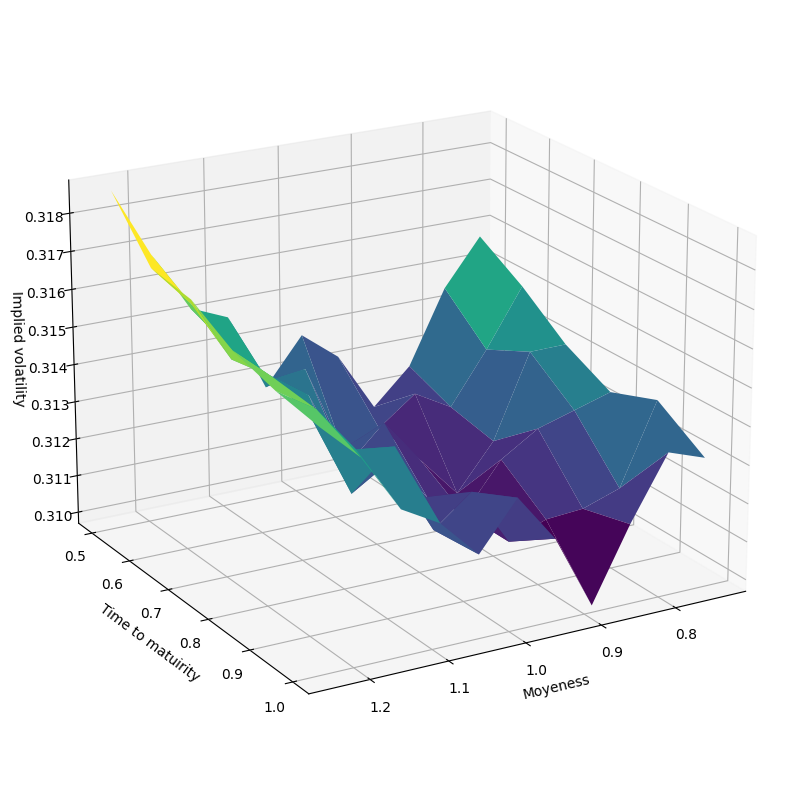

In [65]:
# Plotting the initial volatility surface
plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(elev=20, azim=60)
ax.plot_surface(x, y, z,cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('Moyeness')
ax.set_ylabel('Time to matuirity')
ax.set_zlabel('Implied volatility')
plt.show()

### Smoothing the volatility surface

In [66]:
from scipy import interpolate

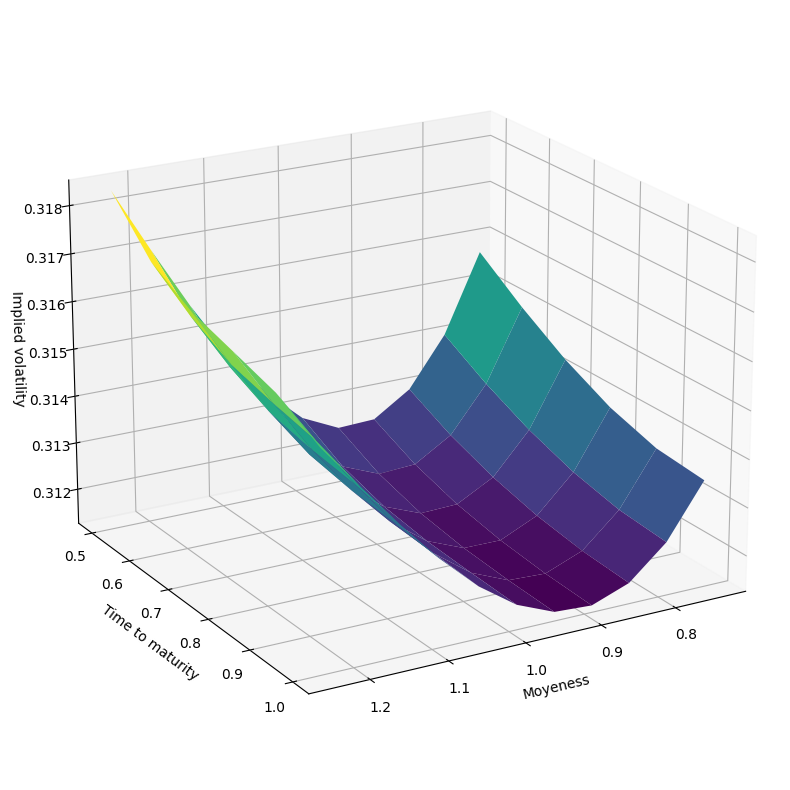

In [67]:
# Smoothing the volatility surface
xnew, ynew = x.copy(), y.copy()
tck = interpolate.bisplrep(x, y, z, s=1.0)
znew = interpolate.bisplev(xnew[:,0], ynew[0,:], tck)

plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(elev=20, azim=60)
ax.plot_surface(xnew, ynew, znew,cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('Moyeness')
ax.set_ylabel('Time to maturity')
ax.set_zlabel('Implied volatility')
plt.show()

### Implied volatility difference

In [68]:
# Generating the surface points
r= .02
tau= 0.5
rho = -0.05
kappa= 1.5
vbar = .1
gamma = .3
v0 = 0.1
moyeness = 0.74
n_moneyness = 11
n_tau = 6
moyeness = np.linspace(moyeness, 1.24,n_moneyness)
tau = np.linspace(tau, 1, n_tau)

cos_prices = []
X = []
Y = []
for m in moyeness:
  for t in tau:
    X.append(m)
    Y.append(t)
    cos_prices.append(call_option_Heston_moy(N = 160, L= 12, r= r, tau= t, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = m))

In [69]:
rho = np.array(rho*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
kappa = np.array(kappa*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
vbar = np.array(vbar*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
gamma = np.array(gamma*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
v0 = np.array(v0*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
# Reshaping for torch tensor dataset
cos_prices = np.array(cos_prices).reshape((-1, 1))
X = np.array(X).reshape((-1, 1))
Y = np.array(Y).reshape((-1, 1))
r = np.array(r*np.ones(n_tau * n_moneyness)).reshape((-1, 1))

In [70]:
data_ann = np.concatenate((X, Y, r, rho, kappa, vbar, gamma, v0, cos_prices), axis = 1)
data_ann = torch.FloatTensor(data_ann)
# Creating a torch dataset
data = np.concatenate((X, Y, r, cos_prices), axis = 1)
data = torch.FloatTensor(data)

In [71]:
implied_vol_pipe1 = np.apply_along_axis(calcimpliedvol, 1, data)

In [72]:
# Getting the implied volatility from the dataset
with torch.no_grad():
  data = data.to(device)
  data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
  data[:,3] = torch.log(data[:,3])
  output = loaded_IV_ANN(data)
  implied_vol_pipe2 = (output).data.cpu().numpy()



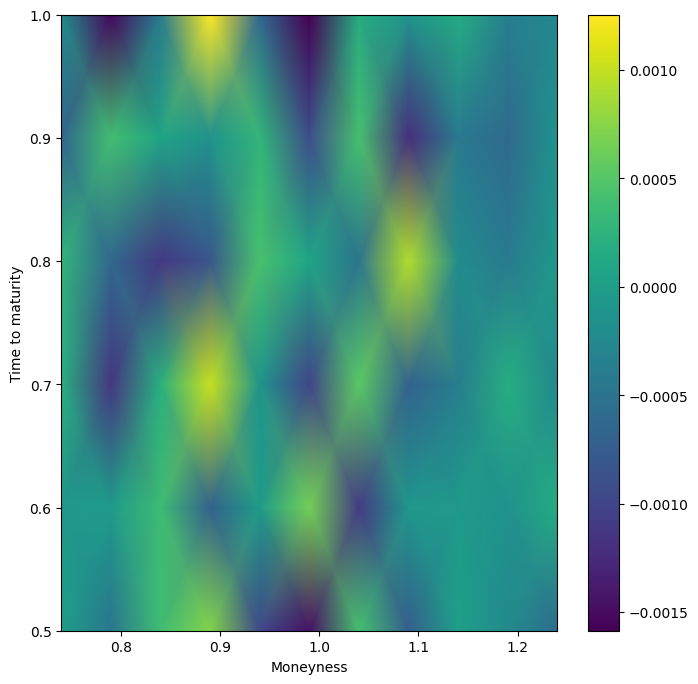

In [73]:
X = X.flatten()
Y = Y.flatten()
Z = (implied_vol_pipe1 - implied_vol_pipe2).flatten()

x = np.reshape(X, (-1, min(n_moneyness, n_tau)))
y = np.reshape(Y, (-1, min(n_moneyness, n_tau)))
z = np.reshape(Z, (-1, min(n_moneyness, n_tau)))

plt.figure(figsize=(8,8))
plt.pcolormesh(x, y, z, shading='gouraud')
plt.colorbar()
plt.xlabel("Moneyness")
plt.ylabel("Time to maturity")
plt.show()